# FedCAPS on CICIoT2023 — 10 clients CNN-1D

Notebook này tái triển khai phương pháp FedCAPS của `2510.05535v3` trên dữ liệu
10 client CICIoT2023. Pipeline gồm MARLFS record collection, tăng cường hoán vị,
encoder hai ISAB, decoder PMA–MAB–rFF, PPO search với sample-aware client
feedback, rồi huấn luyện/evaluate classifier cá nhân hóa.

Runtime dùng scheduler riêng cho từng pha: MARLFS/PPO cân theo tổng số bước
5-fold search, final training cân theo toàn bộ local rows, còn personalized
evaluation cân theo số model-test. Mỗi GPU benchmark 1-vs-2 CUDA stream và chỉ
chạy hai fold đồng thời khi throughput tăng và deterministic replay khớp.

Feature subset cuối cùng có độ dài do FedCAPS tự tìm. Notebook yêu cầu Kaggle
accelerator **GPU T4 x2** và ghi toàn bộ output vào
`/kaggle/working/task10_fedcaps_10c_cnn1d`.

## Công thức chính

$$W_c=|D_c|/\sum_j|D_j|,\qquad
\hat v(f)=\sum_cW_cM_c(X_c[f]).$$

$$ISAB_M(f)=MAB(f,H,H),\qquad H=MAB(I,f,f).$$

$$L_{rec}=-\log P_\psi(f|E).$$

$$R=\lambda(\hat v(f^+)-\hat v(f))+(1-\lambda)(1-|f^+|/25).$$

$$L_{critic}=T^{-1}\sum_t(V(s_t)-G_t)^2,$$

$$L_{actor}=\hat E_t[\min(r_tA_t,
\operatorname{clip}(r_t,1-\epsilon,1+\epsilon)A_t)].$$


## 1. Environment gate

Assert chính xác hai GPU NVIDIA T4 trước mọi công việc nặng.


In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys
import time

import torch

n_gpu = torch.cuda.device_count()
assert n_gpu == 2, f"Notebook requires exactly two GPUs, observed {n_gpu}"
GPU_NAMES = [torch.cuda.get_device_name(gpu_id) for gpu_id in range(2)]
assert all("T4" in name for name in GPU_NAMES), f"Expected T4 x2, observed {GPU_NAMES}"
print({
    "python": sys.version,
    "pytorch": torch.__version__,
    "cuda": torch.version.cuda,
    "gpus": GPU_NAMES,
    "vram_gib": [round(torch.cuda.get_device_properties(gpu_id).total_memory / 2**30, 2) for gpu_id in range(2)],
})


{'python': '3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]', 'pytorch': '2.10.0+cu128', 'cuda': '12.8', 'gpus': ['Tesla T4', 'Tesla T4'], 'vram_gib': [14.56, 14.56]}


## 2. Serialized experiment contract

Mọi thông số paper và quyết định triển khai nằm trong một `CONFIG`.


In [2]:
CONFIG = json.loads(r'''{
    "run_name": "task10_fedcaps_10c_cnn1d",
    "scenario": "10_clients_cnn1d",
    "scenario_name": "10 clients CNN-1D",
    "method": "fedcaps",
    "execution_mode": "client_parallel",
    "input_dir": "/kaggle/input/datasets/odixe0502/data-for-10clients",
    "output_dir": "/kaggle/working/task10_fedcaps_10c_cnn1d",
    "temporary_dir": "/kaggle/temp/task10_fedcaps_10c_cnn1d_cache",
    "model_family": "cnn1d",
    "client_models": {
        "1": "cnn1d",
        "2": "cnn1d",
        "3": "cnn1d",
        "4": "cnn1d",
        "5": "cnn1d",
        "6": "cnn1d",
        "7": "cnn1d",
        "8": "cnn1d",
        "9": "cnn1d",
        "10": "cnn1d"
    },
    "num_clients": 10,
    "num_features": 25,
    "num_classes": 34,
    "seed": 42,
    "initialization_seed": 42,
    "rounds": 10,
    "communication_rounds": 10,
    "local_epochs_per_round": 1,
    "local_train_fraction": 1.0,
    "local_validation_fraction": 0.0,
    "create_local_validation": false,
    "evaluate_global_test_each_round": true,
    "create_best_checkpoint": false,
    "persistent_personalized_clients": true,
    "server_is_classifier": false,
    "evaluation_scope": "clients_only",
    "fedcaps_search_cv_folds": 5,
    "fedcaps_search_pool_max_rows_per_client": 100000,
    "marlfs_epochs": 300,
    "marlfs_log_interval": 10,
    "record_permutations": 25,
    "encoder_isab_layers": 2,
    "encoder_attention_heads": 4,
    "embedding_dimension": 128,
    "inducing_points": 32,
    "pma_seed_vectors": 32,
    "encoder_batch_size": 64,
    "encoder_learning_rate": 0.001,
    "encoder_max_epochs": 100,
    "encoder_patience": 10,
    "permutation_invariance_tolerance": 1e-05,
    "ppo_seed_count": 25,
    "ppo_search_epochs": 10,
    "ppo_batch_size": 512,
    "actor_learning_rate": 0.0003,
    "critic_learning_rate": 0.001,
    "reward_lambda": 0.1,
    "ppo_discount_factor": 0.99,
    "ppo_steps_per_epoch": 1000,
    "ppo_clip_ratio": 0.2,
    "ppo_feedback_interval": 100,
    "ppo_update_epochs": 4,
    "ppo_entropy_coefficient": 0.001,
    "actor_step_scale": 0.1,
    "critic_pretrain_epochs": 200,
    "critic_calibration_steps": 10,
    "minimum_subset_size": 2,
    "candidate_evaluator_epochs": 1,
    "classifier_optimizer": "SGD",
    "classifier_learning_rate": 0.01,
    "per_client_batch_size": 1024,
    "gradient_accumulation_steps": 1,
    "scheduler": null,
    "loss": "cross_entropy",
    "class_weighting": false,
    "mixed_precision": true,
    "gpu_cache_fraction": 0.7,
    "stream_candidates": [
        1,
        2
    ],
    "stream_improvement_margin": 1.0,
    "workload_assignment_policy": "phase_specific_exhaustive_bipartition",
    "search_parallelism_unit": "independent_stratified_cv_fold",
    "require_multistream_deterministic_replay": true,
    "persistent_global_test_gpu_cache": true,
    "gpu_monitor_interval_seconds": 5.0,
    "csv_chunksize": 250000,
    "gpu_copy_chunk_rows": 250000,
    "worker_timeout_seconds": 43200,
    "common_metrics": [
        "accuracy",
        "macro_precision",
        "micro_precision",
        "weighted_precision",
        "macro_recall",
        "micro_recall",
        "weighted_recall",
        "macro_f1",
        "micro_f1",
        "weighted_f1"
    ]
}''')

assert CONFIG["execution_mode"] == "client_parallel"
assert CONFIG["per_client_batch_size"] == 1024
assert CONFIG["gpu_cache_fraction"] == 0.7
assert CONFIG["stream_candidates"] == [1, 2]
assert CONFIG["workload_assignment_policy"] == "phase_specific_exhaustive_bipartition"
assert CONFIG["search_parallelism_unit"] == "independent_stratified_cv_fold"
assert CONFIG["require_multistream_deterministic_replay"] is True
assert CONFIG["persistent_global_test_gpu_cache"] is True
assert CONFIG["rounds"] == 10
assert CONFIG["local_train_fraction"] == 1.0
assert CONFIG["local_validation_fraction"] == 0.0
assert CONFIG["fedcaps_search_cv_folds"] == 5
assert CONFIG["fedcaps_search_pool_max_rows_per_client"] == 100000
Path(CONFIG["temporary_dir"]).mkdir(parents=True, exist_ok=True)
Path(CONFIG["output_dir"]).mkdir(parents=True, exist_ok=True)
print(json.dumps(CONFIG, indent=2, ensure_ascii=False))


{
  "run_name": "task10_fedcaps_10c_cnn1d",
  "scenario": "10_clients_cnn1d",
  "scenario_name": "10 clients CNN-1D",
  "method": "fedcaps",
  "execution_mode": "client_parallel",
  "input_dir": "/kaggle/input/datasets/odixe0502/data-for-10clients",
  "output_dir": "/kaggle/working/task10_fedcaps_10c_cnn1d",
  "temporary_dir": "/kaggle/temp/task10_fedcaps_10c_cnn1d_cache",
  "model_family": "cnn1d",
  "client_models": {
    "1": "cnn1d",
    "2": "cnn1d",
    "3": "cnn1d",
    "4": "cnn1d",
    "5": "cnn1d",
    "6": "cnn1d",
    "7": "cnn1d",
    "8": "cnn1d",
    "9": "cnn1d",
    "10": "cnn1d"
  },
  "num_clients": 10,
  "num_features": 25,
  "num_classes": 34,
  "seed": 42,
  "initialization_seed": 42,
  "rounds": 10,
  "communication_rounds": 10,
  "local_epochs_per_round": 1,
  "local_train_fraction": 1.0,
  "local_validation_fraction": 0.0,
  "create_local_validation": false,
  "evaluate_global_test_each_round": true,
  "create_best_checkpoint": false,
  "persistent_personalized

## 3. Self-contained client-parallel runtime

Runtime dùng CPU coordinator và hai persistent CUDA worker; consolidated outputs chỉ do coordinator ghi.


In [3]:
CLIENT_PARALLEL_SCRIPT_SOURCE = 'from __future__ import annotations\n\nimport csv\nimport hashlib\nimport itertools\nimport json\nimport logging\nimport math\nimport multiprocessing\nimport os\nimport queue\nimport random\nimport subprocess\nimport sys\nimport threading\nimport time\nimport traceback\nfrom collections import OrderedDict\nfrom pathlib import Path\n\nimport matplotlib\n\nmatplotlib.use("Agg")\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\nimport torch\nfrom torch import nn\nfrom torch.amp import GradScaler, autocast\n\n\nFEATURE_COLUMNS = [\n    "ack_flag_number", "AVG", "Std", "UDP", "fin_count", "Max", "TCP",\n    "syn_count", "Protocol Type", "Rate", "IAT", "syn_flag_number",\n    "rst_flag_number", "Tot sum", "HTTPS", "ack_count", "fin_flag_number",\n    "HTTP", "rst_count", "Header_Length", "psh_flag_number", "ICMP",\n    "Time_To_Live", "ARP", "DNS",\n]\nEXPECTED_COLUMNS = FEATURE_COLUMNS + ["Label"]\nNUM_CLASSES = 34\nEXPECTED_PARAMETER_COUNTS = {"gru": 40034, "transformer": 71010, "cnn1d": 35874}\nVALIDATED_MODEL_FAMILIES: set[str] = set()\nCOMMON_METRIC_NAMES = [\n    "accuracy", "macro_precision", "micro_precision", "weighted_precision",\n    "macro_recall", "micro_recall", "weighted_recall",\n    "macro_f1", "micro_f1", "weighted_f1",\n]\n\n\ndef read_manifest() -> dict:\n    manifest_path = Path(os.environ["TRAINING_MANIFEST"])\n    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))\n    return manifest\n\n\ndef json_compatible(value):\n    if isinstance(value, np.generic):\n        return value.tolist()\n    if isinstance(value, np.ndarray):\n        return value.tolist()\n    if isinstance(value, torch.Tensor):\n        return value.detach().cpu().tolist()\n    if isinstance(value, Path):\n        return str(value)\n    raise TypeError(f"Object of type {type(value).__name__} is not JSON serializable")\n\n\ndef atomic_json(path: Path, payload) -> None:\n    temporary = path.with_suffix(path.suffix + ".tmp")\n    temporary.write_text(json.dumps(payload, indent=2, ensure_ascii=False, default=json_compatible), encoding="utf-8")\n    temporary.replace(path)\n\n\ndef rows_to_csv_json(rows: list[dict], csv_path: Path, json_path: Path) -> None:\n    frame = pd.DataFrame(rows)\n    frame.to_csv(csv_path, index=False)\n    atomic_json(json_path, rows)\n\n\ndef setup_logger(path: Path, name: str, console: bool = True) -> logging.Logger:\n    logger = logging.getLogger(name)\n    logger.handlers.clear()\n    logger.setLevel(logging.INFO)\n    formatter = logging.Formatter("%(asctime)s | %(name)s | %(levelname)s | %(message)s")\n    handler = logging.FileHandler(path, mode="w", encoding="utf-8")\n    handler.setFormatter(formatter)\n    logger.addHandler(handler)\n    if console:\n        console_handler = logging.StreamHandler(sys.stdout)\n        console_handler.setFormatter(formatter)\n        logger.addHandler(console_handler)\n    logger.propagate = False\n    return logger\n\n\ndef seed_from(base_seed: int, phase: str, epoch: int = 0, client_id: int = 0) -> int:\n    digest = hashlib.sha256(f"{base_seed}|{phase}|{epoch}|{client_id}".encode()).digest()\n    return int.from_bytes(digest[:8], "little") % (2**31 - 1)\n\n\ndef set_all_seeds(seed: int) -> None:\n    random.seed(seed)\n    np.random.seed(seed)\n    torch.manual_seed(seed)\n\n\ndef state_hash(state: dict[str, torch.Tensor]) -> str:\n    digest = hashlib.sha256()\n    for name in sorted(state):\n        value = state[name].detach().cpu().contiguous()\n        digest.update(name.encode())\n        digest.update(str(value.dtype).encode())\n        digest.update(np.asarray(value.shape, dtype=np.int64).tobytes())\n        digest.update(value.numpy().tobytes())\n    return digest.hexdigest()\n\n\ndef cpu_state(model: nn.Module) -> dict[str, torch.Tensor]:\n    return {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}\n\n\ndef clone_state(state: dict[str, torch.Tensor]) -> dict[str, torch.Tensor]:\n    return {name: value.detach().cpu().clone() for name, value in state.items()}\n\n\ndef count_parameters(model: nn.Module) -> int:\n    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)\n\n\nclass GRUClassifier(nn.Module):\n    def __init__(self) -> None:\n        super().__init__()\n        self.gru = nn.GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)\n        self.classifier = nn.Linear(64, NUM_CLASSES)\n\n    def forward(self, x: torch.Tensor) -> torch.Tensor:\n        output, _ = self.gru(x.unsqueeze(-1))\n        return self.classifier(output[:, -1])\n\n\nclass TransformerClassifier(nn.Module):\n    def __init__(self) -> None:\n        super().__init__()\n        self.projection = nn.Linear(1, 64)\n        self.position = nn.Parameter(torch.zeros(1, 25, 64))\n        layer = nn.TransformerEncoderLayer(\n            d_model=64,\n            nhead=4,\n            dim_feedforward=128,\n            dropout=0.1,\n            batch_first=True,\n            activation="relu",\n            norm_first=False,\n        )\n        self.encoder = nn.TransformerEncoder(layer, num_layers=2)\n        self.norm = nn.LayerNorm(64)\n        self.classifier = nn.Linear(64, NUM_CLASSES)\n\n    def forward(self, x: torch.Tensor) -> torch.Tensor:\n        length = x.shape[1]\n        encoded = self.projection(x.unsqueeze(-1)) + self.position[:, :length]\n        return self.classifier(self.norm(self.encoder(encoded).mean(dim=1)))\n\n\nclass CNN1DClassifier(nn.Module):\n    def __init__(self) -> None:\n        super().__init__()\n        self.block1 = nn.Sequential(\n            nn.Conv1d(1, 32, kernel_size=3, padding=1),\n            nn.BatchNorm1d(32),\n            nn.ReLU(),\n        )\n        self.block2 = nn.Sequential(\n            nn.Conv1d(32, 64, kernel_size=3, padding=1),\n            nn.BatchNorm1d(64),\n            nn.ReLU(),\n            nn.MaxPool1d(2),\n        )\n        self.block3 = nn.Sequential(\n            nn.Conv1d(64, 128, kernel_size=3, padding=1),\n            nn.BatchNorm1d(128),\n            nn.ReLU(),\n        )\n        self.pool = nn.AdaptiveAvgPool1d(1)\n        self.classifier = nn.Linear(128, NUM_CLASSES)\n\n    def forward(self, x: torch.Tensor) -> torch.Tensor:\n        hidden = self.block3(self.block2(self.block1(x.unsqueeze(1))))\n        return self.classifier(self.pool(hidden).squeeze(-1))\n\n\ndef build_classifier(family: str) -> nn.Module:\n    if family == "gru":\n        model = GRUClassifier()\n    elif family == "transformer":\n        model = TransformerClassifier()\n    elif family == "cnn1d":\n        model = CNN1DClassifier()\n    else:\n        raise ValueError(f"Unknown model family: {family}")\n    if family not in VALIDATED_MODEL_FAMILIES:\n        observed = count_parameters(model)\n        expected = EXPECTED_PARAMETER_COUNTS[family]\n        if observed != expected:\n            raise AssertionError(f"{family} parameter count {observed} != {expected}")\n        probe = torch.zeros(2, 25)\n        if tuple(model(probe).shape) != (2, NUM_CLASSES):\n            raise AssertionError(f"Invalid output shape for {family}")\n        VALIDATED_MODEL_FAMILIES.add(family)\n    return model\n\n\nclass MAB(nn.Module):\n    def __init__(self, dimension: int = 128, heads: int = 4) -> None:\n        super().__init__()\n        self.attention = nn.MultiheadAttention(dimension, heads, batch_first=True, dropout=0.0)\n        self.norm1 = nn.LayerNorm(dimension)\n        self.feedforward = nn.Sequential(nn.Linear(dimension, dimension), nn.ReLU(), nn.Linear(dimension, dimension))\n        self.norm2 = nn.LayerNorm(dimension)\n\n    def forward(\n        self,\n        query: torch.Tensor,\n        key: torch.Tensor,\n        value: torch.Tensor,\n        key_padding_mask: torch.Tensor | None = None,\n    ) -> torch.Tensor:\n        attention, _ = self.attention(query, key, value, key_padding_mask=key_padding_mask, need_weights=False)\n        hidden = self.norm1(query + attention)\n        return self.norm2(hidden + self.feedforward(hidden))\n\n\nclass ISAB(nn.Module):\n    def __init__(self, dimension: int = 128, heads: int = 4, inducing_points: int = 32) -> None:\n        super().__init__()\n        self.inducing = nn.Parameter(torch.randn(1, inducing_points, dimension) * 0.02)\n        self.inducing_to_set = MAB(dimension, heads)\n        self.set_to_inducing = MAB(dimension, heads)\n\n    def forward(self, values: torch.Tensor, padding_mask: torch.Tensor) -> torch.Tensor:\n        inducing = self.inducing.expand(values.shape[0], -1, -1)\n        summary = self.inducing_to_set(inducing, values, values, key_padding_mask=padding_mask)\n        output = self.set_to_inducing(values, summary, summary)\n        return output.masked_fill(padding_mask.unsqueeze(-1), 0.0)\n\n\nclass SetEncoder(nn.Module):\n    def __init__(self) -> None:\n        super().__init__()\n        self.embedding = nn.Embedding(26, 128, padding_idx=0)\n        self.isab1 = ISAB()\n        self.isab2 = ISAB()\n\n    def forward(self, token_ids: torch.Tensor, padding_mask: torch.Tensor) -> torch.Tensor:\n        hidden = self.embedding(token_ids)\n        hidden = self.isab1(hidden, padding_mask)\n        return self.isab2(hidden, padding_mask)\n\n\nclass SetDecoder(nn.Module):\n    def __init__(self) -> None:\n        super().__init__()\n        self.seeds = nn.Parameter(torch.randn(1, 32, 128) * 0.02)\n        self.pre = nn.Sequential(nn.Linear(128, 128), nn.ReLU(), nn.Linear(128, 128))\n        self.pma = MAB()\n        self.self_mab = MAB()\n        self.head = nn.Sequential(nn.Linear(128, 128), nn.ReLU(), nn.Linear(128, 25))\n\n    def pool(self, embedding: torch.Tensor, padding_mask: torch.Tensor) -> torch.Tensor:\n        seeds = self.seeds.expand(embedding.shape[0], -1, -1)\n        prepared = self.pre(embedding)\n        pooled = self.pma(seeds, prepared, prepared, key_padding_mask=padding_mask)\n        pooled = self.self_mab(pooled, pooled, pooled)\n        return pooled.mean(dim=1)\n\n    def logits_from_latent(self, latent: torch.Tensor) -> torch.Tensor:\n        return self.head(latent)\n\n    def forward(self, embedding: torch.Tensor, padding_mask: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:\n        latent = self.pool(embedding, padding_mask)\n        return self.logits_from_latent(latent), latent\n\n\nclass FeatureQNetwork(nn.Module):\n    def __init__(self) -> None:\n        super().__init__()\n        self.network = nn.Sequential(nn.Linear(25, 64), nn.ReLU(), nn.Linear(64, 2))\n\n    def forward(self, state: torch.Tensor) -> torch.Tensor:\n        return self.network(state)\n\n\nclass BatchedFeatureQNetwork(nn.Module):\n    """Twenty-five independent Q networks evaluated with batched CUDA operations."""\n\n    def __init__(self) -> None:\n        super().__init__()\n        independent = [FeatureQNetwork() for _ in range(25)]\n        self.weight1 = nn.Parameter(torch.stack([network.network[0].weight.detach() for network in independent]))\n        self.bias1 = nn.Parameter(torch.stack([network.network[0].bias.detach() for network in independent]))\n        self.weight2 = nn.Parameter(torch.stack([network.network[2].weight.detach() for network in independent]))\n        self.bias2 = nn.Parameter(torch.stack([network.network[2].bias.detach() for network in independent]))\n\n    def forward(self, state: torch.Tensor) -> torch.Tensor:\n        if tuple(state.shape) != (25,):\n            raise ValueError(f"Expected one 25-feature MARLFS state, observed {tuple(state.shape)}")\n        hidden = torch.einsum("fhi,i->fh", self.weight1, state) + self.bias1\n        hidden = torch.relu(hidden)\n        return torch.einsum("foh,fh->fo", self.weight2, hidden) + self.bias2\n\n\nclass GaussianActor(nn.Module):\n    def __init__(self) -> None:\n        super().__init__()\n        self.mean = nn.Sequential(nn.Linear(128, 256), nn.Tanh(), nn.Linear(256, 128))\n        self.log_std = nn.Parameter(torch.full((128,), -1.5))\n\n    def distribution(self, latent: torch.Tensor):\n        mean = self.mean(latent)\n        std = self.log_std.clamp(-4.0, 1.0).exp().expand_as(mean)\n        return torch.distributions.Normal(mean, std)\n\n\nclass RewardCritic(nn.Module):\n    def __init__(self) -> None:\n        super().__init__()\n        self.network = nn.Sequential(nn.Linear(25, 128), nn.ReLU(), nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1))\n\n    def forward(self, mask: torch.Tensor) -> torch.Tensor:\n        return self.network(mask).squeeze(-1)\n\n\ndef ensure_output_dirs(config: dict) -> dict[str, Path]:\n    output = Path(config["output_dir"])\n    paths = {\n        "root": output,\n        "checkpoints": output / "checkpoints",\n        "logs": output / "logs",\n        "metrics": output / "metrics",\n        "artifacts": output / "artifacts",\n        "temporary": Path(config["temporary_dir"]),\n    }\n    for path in paths.values():\n        path.mkdir(parents=True, exist_ok=True)\n    return paths\n\n\ndef fast_csv_rows(path: Path) -> int:\n    line_count = 0\n    with path.open("rb") as handle:\n        for block in iter(lambda: handle.read(8 * 1024 * 1024), b""):\n            line_count += block.count(b"\\n")\n    if path.stat().st_size:\n        with path.open("rb") as handle:\n            handle.seek(-1, os.SEEK_END)\n            if handle.read(1) != b"\\n":\n                line_count += 1\n    return max(0, line_count - 1)\n\n\ndef allocate_stratified(counts: np.ndarray, target: int, require_validation: bool) -> np.ndarray:\n    counts = counts.astype(np.int64, copy=False)\n    target = int(min(target, int(counts.sum())))\n    if target <= 0:\n        return np.zeros_like(counts)\n    ideal = counts.astype(np.float64) * (target / max(1, int(counts.sum())))\n    allocation = np.floor(ideal).astype(np.int64)\n    present = np.flatnonzero(counts > 0)\n    if target >= len(present):\n        allocation[present] = np.maximum(allocation[present], 1)\n    if require_validation:\n        eligible = np.flatnonzero(counts >= 2)\n        if target >= len(eligible):\n            allocation[eligible] = np.maximum(allocation[eligible], 1)\n    allocation = np.minimum(allocation, counts)\n    while int(allocation.sum()) < target:\n        candidates = np.flatnonzero(allocation < counts)\n        residual = ideal[candidates] - allocation[candidates]\n        chosen = int(candidates[np.argmax(residual)])\n        allocation[chosen] += 1\n    while int(allocation.sum()) > target:\n        minimum = np.where(counts > 0, 1, 0)\n        candidates = np.flatnonzero(allocation > minimum)\n        if len(candidates) == 0:\n            break\n        residual = ideal[candidates] - allocation[candidates]\n        chosen = int(candidates[np.argmin(residual)])\n        allocation[chosen] -= 1\n    return allocation\n\n\ndef convert_csv_to_memmap(csv_path: Path, prefix: Path, chunksize: int, logger: logging.Logger) -> dict:\n    header = list(pd.read_csv(csv_path, nrows=0).columns)\n    if header != EXPECTED_COLUMNS:\n        raise ValueError(f"Unexpected header for {csv_path}: {header}")\n    rows = fast_csv_rows(csv_path)\n    x_path = prefix.with_name(prefix.name + "_x.dat")\n    y_path = prefix.with_name(prefix.name + "_y.dat")\n    features = np.memmap(x_path, mode="w+", dtype=np.float32, shape=(rows, 25))\n    labels = np.memmap(y_path, mode="w+", dtype=np.int64, shape=(rows,))\n    offset = 0\n    for chunk in pd.read_csv(csv_path, chunksize=chunksize):\n        if list(chunk.columns) != EXPECTED_COLUMNS:\n            raise ValueError(f"Header changed while reading {csv_path}")\n        x = chunk[FEATURE_COLUMNS].to_numpy(dtype=np.float32, copy=True)\n        y_raw = chunk["Label"].to_numpy(copy=True)\n        if not np.isfinite(x).all():\n            raise ValueError(f"NaN/Inf in features: {csv_path}")\n        if not np.isfinite(y_raw).all() or not np.equal(y_raw, np.floor(y_raw)).all():\n            raise ValueError(f"Invalid labels: {csv_path}")\n        y = y_raw.astype(np.int64, copy=False)\n        if len(y) and (int(y.min()) < 0 or int(y.max()) >= NUM_CLASSES):\n            raise ValueError(f"Label outside [0,33]: {csv_path}")\n        end = offset + len(chunk)\n        features[offset:end] = x\n        labels[offset:end] = y\n        offset = end\n    if offset != rows:\n        raise AssertionError(f"Row accounting mismatch for {csv_path}: {offset} != {rows}")\n    features.flush()\n    labels.flush()\n    counts = np.bincount(np.asarray(labels), minlength=NUM_CLASSES).astype(np.int64)\n    logger.info("Converted %s rows from %s", f"{rows:,}", csv_path.name)\n    return {\n        "rows": rows,\n        "x_path": str(x_path),\n        "y_path": str(y_path),\n        "class_counts": counts.tolist(),\n    }\n\n\ndef write_index_memmap(path: Path, values: np.ndarray) -> str:\n    values = np.asarray(values, dtype=np.int64)\n    target = np.memmap(path, mode="w+", dtype=np.int64, shape=(len(values),))\n    target[:] = values\n    target.flush()\n    return str(path)\n\n\ndef make_client_splits(meta: dict, prefix: Path, seed: int, search_cap: int, folds: int) -> dict:\n    """Use every local row for final training; CV exists only inside feature search."""\n    rows = int(meta["rows"])\n    labels = np.memmap(meta["y_path"], mode="r", dtype=np.int64, shape=(rows,))\n    counts = np.bincount(np.asarray(labels), minlength=NUM_CLASSES).astype(np.int64)\n    train_values = np.arange(rows, dtype=np.int64)\n    train_path = prefix.with_name(prefix.name + "_train_idx.dat")\n    write_index_memmap(train_path, train_values)\n\n    search_total = min(int(search_cap), rows)\n    search_counts = allocate_stratified(counts, search_total, False)\n    pool_parts = []\n    class_fold_parts = [[ ] for _ in range(folds)]\n    for class_id in range(NUM_CLASSES):\n        class_rows = np.flatnonzero(labels == class_id).astype(np.int64, copy=False)\n        rng = np.random.default_rng(seed_from(seed, "fedcaps_search_pool", class_id, 0))\n        rng.shuffle(class_rows)\n        selected = class_rows[: int(search_counts[class_id])]\n        pool_parts.append(selected)\n        for fold_id, fold_rows in enumerate(np.array_split(selected, folds)):\n            class_fold_parts[fold_id].append(np.asarray(fold_rows, dtype=np.int64))\n    search_pool = np.concatenate(pool_parts) if pool_parts else np.empty(0, dtype=np.int64)\n    pool_rng = np.random.default_rng(seed_from(seed, "fedcaps_search_pool_order"))\n    pool_rng.shuffle(search_pool)\n    search_pool_path = prefix.with_name(prefix.name + "_search_pool_idx.dat")\n    write_index_memmap(search_pool_path, search_pool)\n\n    fold_metadata = []\n    for fold_id in range(folds):\n        validation = np.concatenate(class_fold_parts[fold_id])\n        validation_set = set(map(int, validation.tolist()))\n        training = np.asarray([row for row in search_pool if int(row) not in validation_set], dtype=np.int64)\n        fold_rng = np.random.default_rng(seed_from(seed, "fedcaps_search_fold", fold_id, 0))\n        fold_rng.shuffle(training)\n        fold_rng.shuffle(validation)\n        train_name = f"search_fold_{fold_id}_train"\n        validation_name = f"search_fold_{fold_id}_validation"\n        train_fold_path = prefix.with_name(prefix.name + f"_{train_name}_idx.dat")\n        validation_fold_path = prefix.with_name(prefix.name + f"_{validation_name}_idx.dat")\n        write_index_memmap(train_fold_path, training)\n        write_index_memmap(validation_fold_path, validation)\n        meta[f"{train_name}_rows"] = len(training)\n        meta[f"{train_name}_idx_path"] = str(train_fold_path)\n        meta[f"{validation_name}_rows"] = len(validation)\n        meta[f"{validation_name}_idx_path"] = str(validation_fold_path)\n        fold_metadata.append({\n            "fold": fold_id + 1,\n            "train_rows": len(training),\n            "validation_rows": len(validation),\n        })\n    meta.update({\n        "train_rows": rows,\n        "validation_rows": 0,\n        "train_class_counts": counts.tolist(),\n        "validation_class_counts": [0] * NUM_CLASSES,\n        "train_idx_path": str(train_path),\n        "search_pool_rows": len(search_pool),\n        "search_pool_idx_path": str(search_pool_path),\n        "search_cv_folds": folds,\n        "search_fold_metadata": fold_metadata,\n    })\n    return meta\n\n\ndef validate_numpy_classification_cache(meta: dict) -> None:\n    rows = int(meta["rows"])\n    features = np.memmap(meta["x_path"], mode="r", dtype=np.float32, shape=(rows, 25))\n    labels = np.memmap(meta["y_path"], mode="r", dtype=np.int64, shape=(rows,))\n    if features.shape != (rows, 25) or features.dtype != np.float32:\n        raise AssertionError("Invalid cached feature contract")\n    if labels.shape != (rows,) or labels.dtype != np.int64:\n        raise AssertionError("Invalid cached label contract")\n    if rows and (int(labels.min()) < 0 or int(labels.max()) >= NUM_CLASSES):\n        raise AssertionError("Cached label outside [0,33]")\n    index_contracts = [("train_idx_path", "train_rows"), ("search_pool_idx_path", "search_pool_rows")]\n    for fold_id in range(int(meta["search_cv_folds"])):\n        index_contracts.extend([\n            (f"search_fold_{fold_id}_train_idx_path", f"search_fold_{fold_id}_train_rows"),\n            (f"search_fold_{fold_id}_validation_idx_path", f"search_fold_{fold_id}_validation_rows"),\n        ])\n    for name, count_name in index_contracts:\n        count = int(meta[count_name])\n        indices = np.memmap(meta[name], mode="r", dtype=np.int64, shape=(count,))\n        if count and (int(indices.min()) < 0 or int(indices.max()) >= rows):\n            raise AssertionError(f"Invalid index range: {name}")\n    if int(meta["train_rows"]) != rows or int(meta["validation_rows"]) != 0:\n        raise AssertionError("FedCAPS final training must use 100% local data and no local validation")\n    for fold in meta["search_fold_metadata"]:\n        if int(fold["train_rows"]) + int(fold["validation_rows"]) != int(meta["search_pool_rows"]):\n            raise AssertionError("FedCAPS CV fold accounting mismatch")\n\n\ndef prepare_data(config: dict, paths: dict[str, Path], logger: logging.Logger) -> dict:\n    started = time.perf_counter()\n    input_dir = Path(config["input_dir"])\n    logger.info("[STAGE data] Validating input contract under %s", input_dir)\n    required = [input_dir / f"client_{client_id}_train.csv" for client_id in range(1, 11)]\n    required += [input_dir / "global_train_data.csv", input_dir / "global_test_data.csv", input_dir / "label_mapping.csv"]\n    missing = [str(path) for path in required if not path.is_file()]\n    if missing:\n        raise FileNotFoundError(f"Missing input files: {missing}")\n    mapping = pd.read_csv(input_dir / "label_mapping.csv")\n    if list(mapping.columns) != ["Encoded_ID", "Label_Name"] or len(mapping) != NUM_CLASSES:\n        raise ValueError("Invalid label_mapping.csv")\n    encoded = mapping["Encoded_ID"].to_numpy(dtype=np.int64)\n    if not np.array_equal(encoded, np.arange(NUM_CLASSES, dtype=np.int64)):\n        raise ValueError("Label mapping IDs must be 0..33")\n    cache_root = paths["temporary"] / "data"\n    cache_root.mkdir(parents=True, exist_ok=True)\n    clients = {}\n    distribution_rows = []\n    for client_id in range(1, 11):\n        client_started = time.perf_counter()\n        logger.info("[STAGE data] Preparing client %d/10", client_id)\n        prefix = cache_root / f"client_{client_id}"\n        meta = convert_csv_to_memmap(\n            input_dir / f"client_{client_id}_train.csv",\n            prefix,\n            int(config["csv_chunksize"]),\n            logger,\n        )\n        meta = make_client_splits(\n            meta,\n            prefix,\n            int(config["seed"]),\n            int(config["fedcaps_search_pool_max_rows_per_client"]),\n            int(config["fedcaps_search_cv_folds"]),\n        )\n        meta["client_id"] = client_id\n        meta["model_family"] = config["client_models"][str(client_id)]\n        validate_numpy_classification_cache(meta)\n        clients[str(client_id)] = meta\n        logger.info(\n            "[STAGE data] Client %d ready rows=%s final_train=%s local_validation=%s search_pool=%s cv_folds=%s seconds=%.2f",\n            client_id,\n            f"{int(meta[\'rows\']):,}",\n            f"{int(meta[\'train_rows\']):,}",\n            f"{int(meta[\'validation_rows\']):,}",\n            f"{int(meta[\'search_pool_rows\']):,}",\n            int(meta["search_cv_folds"]),\n            time.perf_counter() - client_started,\n        )\n        for class_id, count in enumerate(meta["class_counts"]):\n            distribution_rows.append({\n                "client_id": client_id,\n                "class_id": class_id,\n                "class_name": str(mapping.loc[class_id, "Label_Name"]),\n                "count": int(count),\n                "train_count": int(meta["train_class_counts"][class_id]),\n                "validation_count": int(meta["validation_class_counts"][class_id]),\n            })\n    global_test = convert_csv_to_memmap(\n        input_dir / "global_test_data.csv",\n        cache_root / "global_test",\n        int(config["csv_chunksize"]),\n        logger,\n    )\n    global_train_rows = fast_csv_rows(input_dir / "global_train_data.csv")\n    local_rows = sum(int(meta["rows"]) for meta in clients.values())\n    if global_train_rows != local_rows:\n        raise AssertionError(f"global_train rows {global_train_rows} != client sum {local_rows}")\n    dataset_summary = {\n        "feature_columns": FEATURE_COLUMNS,\n        "num_features": 25,\n        "num_classes": NUM_CLASSES,\n        "label_mapping": mapping.to_dict(orient="records"),\n        "global_train_rows": global_train_rows,\n        "client_rows_sum": local_rows,\n        "global_test": global_test,\n        "clients": clients,\n        "split_seed": int(config["seed"]),\n        "split_policy": "100_percent_local_training; deterministic_stratified_5_fold_cv_only_for_fedcaps_feature_search",\n        "fedcaps_search_cv_folds": int(config["fedcaps_search_cv_folds"]),\n        "fedcaps_search_pool_max_rows_per_client": int(config["fedcaps_search_pool_max_rows_per_client"]),\n        "preprocessing_seconds": time.perf_counter() - started,\n    }\n    atomic_json(paths["metrics"] / "dataset_summary.json", dataset_summary)\n    pd.DataFrame(distribution_rows).to_csv(paths["metrics"] / "client_class_distribution.csv", index=False)\n    logger.info(\n        "[STAGE data] Complete local_rows=%s global_test_rows=%s seconds=%.2f",\n        f"{local_rows:,}",\n        f"{int(global_test[\'rows\']):,}",\n        time.perf_counter() - started,\n    )\n    return dataset_summary\n\n\ndef metrics_from_confusion(confusion: np.ndarray, loss_sum: float = 0.0, examples: int | None = None) -> dict:\n    matrix = confusion.astype(np.float64, copy=False)\n    support = matrix.sum(axis=1)\n    predicted = matrix.sum(axis=0)\n    true_positive = np.diag(matrix)\n    total = float(matrix.sum())\n    false_positive = predicted - true_positive\n    false_negative = support - true_positive\n    precision = np.divide(true_positive, true_positive + false_positive, out=np.zeros(NUM_CLASSES), where=(true_positive + false_positive) > 0)\n    recall = np.divide(true_positive, true_positive + false_negative, out=np.zeros(NUM_CLASSES), where=(true_positive + false_negative) > 0)\n    f1 = np.divide(2.0 * precision * recall, precision + recall, out=np.zeros(NUM_CLASSES), where=(precision + recall) > 0)\n    weights = np.divide(support, total, out=np.zeros(NUM_CLASSES), where=total > 0)\n    accuracy = float(true_positive.sum() / total) if total else 0.0\n    denominator = examples if examples is not None else int(total)\n    return {\n        "loss": float(loss_sum / denominator) if denominator else 0.0,\n        "accuracy": accuracy,\n        "micro_precision": accuracy,\n        "micro_recall": accuracy,\n        "micro_f1": accuracy,\n        "macro_precision": float(precision.mean()),\n        "macro_recall": float(recall.mean()),\n        "macro_f1": float(f1.mean()),\n        "weighted_precision": float(np.sum(precision * weights)),\n        "weighted_recall": float(np.sum(recall * weights)),\n        "weighted_f1": float(np.sum(f1 * weights)),\n        "examples": int(total),\n    }\n\n\ndef classification_report_from_confusion(confusion: np.ndarray, label_mapping: list[dict]) -> tuple[list[dict], dict]:\n    matrix = confusion.astype(np.float64, copy=False)\n    support = matrix.sum(axis=1)\n    predicted = matrix.sum(axis=0)\n    true_positive = np.diag(matrix)\n    precision = np.divide(true_positive, predicted, out=np.zeros(NUM_CLASSES), where=predicted > 0)\n    recall = np.divide(true_positive, support, out=np.zeros(NUM_CLASSES), where=support > 0)\n    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros(NUM_CLASSES), where=(precision + recall) > 0)\n    total = float(support.sum())\n    weights = np.divide(support, total, out=np.zeros(NUM_CLASSES), where=total > 0)\n    rows = []\n    for class_id in range(NUM_CLASSES):\n        rows.append({\n            "class_id": class_id,\n            "class_name": str(label_mapping[class_id]["Label_Name"]),\n            "precision": float(precision[class_id]),\n            "recall": float(recall[class_id]),\n            "f1": float(f1[class_id]),\n            "support": int(support[class_id]),\n        })\n    aggregate = {\n        "macro_avg": {"precision": float(precision.mean()), "recall": float(recall.mean()), "f1": float(f1.mean()), "support": int(total)},\n        "weighted_avg": {"precision": float(np.sum(precision * weights)), "recall": float(np.sum(recall * weights)), "f1": float(np.sum(f1 * weights)), "support": int(total)},\n        "accuracy": float(true_positive.sum() / total) if total else 0.0,\n    }\n    return rows, aggregate\n\n\ndef tensor_bytes(shape: tuple[int, ...], dtype: torch.dtype) -> int:\n    element = torch.empty((), dtype=dtype).element_size()\n    return int(math.prod(shape) * element)\n\n\nclass GPUClientCache:\n    def __init__(self, gpu_id: int, config: dict, clients: dict, logger: logging.Logger, phase: str) -> None:\n        self.gpu_id = gpu_id\n        self.device = torch.device("cuda", gpu_id)\n        self.config = config\n        self.clients = clients\n        self.logger = logger\n        self.phase = phase\n        self.owned_client_ids: list[int] = []\n        properties = torch.cuda.get_device_properties(gpu_id)\n        self.cache_budget_bytes = int(properties.total_memory * float(config["gpu_cache_fraction"]))\n        self.entries: OrderedDict[int, dict] = OrderedDict()\n        self.cache_hits = 0\n        self.cache_misses = 0\n        self.evictions = 0\n        self.fallbacks = 0\n        self.actual_cache_bytes = 0\n        self.auxiliary_cache_bytes = 0\n        self.test_cache_hits = 0\n        self.test_cache_misses = 0\n        self.test_entry: dict | None = None\n        self.fallback_entries: dict[int, dict] = {}\n        self.model_pools: dict[str, list[nn.Module]] = {}\n\n    def planned_bytes(self, meta: dict) -> int:\n        rows = int(meta["rows"])\n        index_rows = int(meta["train_rows"])\n        for fold_id in range(int(meta["search_cv_folds"])):\n            index_rows += int(meta[f"search_fold_{fold_id}_train_rows"])\n            index_rows += int(meta[f"search_fold_{fold_id}_validation_rows"])\n        return tensor_bytes((rows, 25), torch.float32) + tensor_bytes((rows,), torch.long) + tensor_bytes((index_rows,), torch.long)\n\n    def _copy_memmap(self, path: str, dtype, shape: tuple[int, ...], torch_dtype: torch.dtype) -> torch.Tensor:\n        source = np.memmap(path, mode="r", dtype=dtype, shape=shape)\n        target = torch.empty(shape, dtype=torch_dtype, device=self.device)\n        chunk_rows = int(self.config["gpu_copy_chunk_rows"])\n        for start in range(0, shape[0], chunk_rows):\n            end = min(shape[0], start + chunk_rows)\n            host = torch.from_numpy(np.array(source[start:end], copy=True))\n            target[start:end].copy_(host, non_blocking=False)\n        return target\n\n    def _load_full(self, client_id: int) -> dict:\n        meta = self.clients[str(client_id)]\n        rows = int(meta["rows"])\n        entry = {\n            "mode": "gpu_full",\n            "meta": meta,\n            "x": self._copy_memmap(meta["x_path"], np.float32, (rows, 25), torch.float32),\n            "y": self._copy_memmap(meta["y_path"], np.int64, (rows,), torch.long),\n            "indices": {},\n        }\n        split_names = ["train"]\n        for fold_id in range(int(meta["search_cv_folds"])):\n            split_names.extend([f"search_fold_{fold_id}_train", f"search_fold_{fold_id}_validation"])\n        for name in split_names:\n            count_name = f"{name}_rows"\n            count = int(meta[count_name])\n            entry["indices"][name] = self._copy_memmap(meta[f"{name}_idx_path"], np.int64, (count,), torch.long)\n        entry["bytes"] = self.planned_bytes(meta)\n        return entry\n\n    def _pinned_fallback_entry(self, meta: dict) -> dict:\n        slots = max(1, int(self.config["runtime_stream_count_by_gpu"][str(self.gpu_id)]))\n        batch_size = int(self.config["per_client_batch_size"])\n        return {\n            "mode": "pinned_fallback",\n            "meta": meta,\n            "pinned_x": [\n                torch.empty((batch_size, 25), dtype=torch.float32, pin_memory=True)\n                for _ in range(slots)\n            ],\n            "pinned_y": [\n                torch.empty((batch_size,), dtype=torch.long, pin_memory=True)\n                for _ in range(slots)\n            ],\n        }\n\n    def get_model_pool(self, family: str, count: int) -> list[nn.Module]:\n        models = self.model_pools.setdefault(family, [])\n        while len(models) < count:\n            models.append(build_classifier(family).to(self.device))\n        return models[:count]\n\n    def initialize(self, owned_client_ids: list[int]) -> dict:\n        self.owned_client_ids = sorted(map(int, owned_client_ids))\n        planned = sum(self.planned_bytes(self.clients[str(client_id)]) for client_id in owned_client_ids)\n        if planned <= self.cache_budget_bytes:\n            for client_id in owned_client_ids:\n                entry = self._load_full(client_id)\n                self.entries[client_id] = entry\n                self.actual_cache_bytes += int(entry["bytes"])\n        else:\n            ordered = sorted(owned_client_ids, key=lambda client_id: (self.planned_bytes(self.clients[str(client_id)]), client_id))\n            for client_id in ordered:\n                needed = self.planned_bytes(self.clients[str(client_id)])\n                if self.actual_cache_bytes + needed <= self.cache_budget_bytes:\n                    entry = self._load_full(client_id)\n                    self.entries[client_id] = entry\n                    self.actual_cache_bytes += int(entry["bytes"])\n                else:\n                    self.fallbacks += 1\n        torch.cuda.synchronize(self.device)\n        self.logger.info(\n            "GPU %d cache phase=%s clients=%s planned=%s actual=%s budget=%s",\n            self.gpu_id,\n            self.phase,\n            self.owned_client_ids,\n            f"{planned:,}",\n            f"{self.actual_cache_bytes:,}",\n            f"{self.cache_budget_bytes:,}",\n        )\n        return self.telemetry(planned)\n\n    def get(self, client_id: int) -> dict:\n        if client_id in self.entries:\n            self.cache_hits += 1\n            self.entries.move_to_end(client_id)\n            return self.entries[client_id]\n        self.cache_misses += 1\n        needed = self.planned_bytes(self.clients[str(client_id)])\n        while self.entries and self.actual_cache_bytes + self.auxiliary_cache_bytes + needed > self.cache_budget_bytes:\n            _, evicted = self.entries.popitem(last=False)\n            self.actual_cache_bytes -= int(evicted["bytes"])\n            self.evictions += 1\n            del evicted\n            torch.cuda.empty_cache()\n        if self.auxiliary_cache_bytes + needed <= self.cache_budget_bytes:\n            entry = self._load_full(client_id)\n            self.entries[client_id] = entry\n            self.actual_cache_bytes += int(entry["bytes"])\n            return entry\n        self.fallbacks += 1\n        if client_id not in self.fallback_entries:\n            self.fallback_entries[client_id] = self._pinned_fallback_entry(self.clients[str(client_id)])\n        return self.fallback_entries[client_id]\n\n    def get_global_test(self, global_test_meta: dict) -> dict:\n        if self.test_entry is not None:\n            self.test_cache_hits += 1\n            return self.test_entry\n        self.test_cache_misses += 1\n        rows = int(global_test_meta["rows"])\n        test_bytes = tensor_bytes((rows, 25), torch.float32) + 2 * tensor_bytes((rows,), torch.long)\n        if (\n            bool(self.config["persistent_global_test_gpu_cache"])\n            and self.actual_cache_bytes + test_bytes <= self.cache_budget_bytes\n        ):\n            self.test_entry = {\n                "mode": "gpu_full",\n                "meta": {\n                    **global_test_meta,\n                    "test_rows": rows,\n                },\n                "x": self._copy_memmap(global_test_meta["x_path"], np.float32, (rows, 25), torch.float32),\n                "y": self._copy_memmap(global_test_meta["y_path"], np.int64, (rows,), torch.long),\n                "indices": {"test": torch.arange(rows, dtype=torch.long, device=self.device)},\n            }\n            self.auxiliary_cache_bytes = test_bytes\n        else:\n            identity_path = Path(global_test_meta["x_path"]).with_name(\n                f"global_test_identity_idx_gpu_{self.gpu_id}.dat"\n            )\n            if not identity_path.is_file() or identity_path.stat().st_size != rows * np.dtype(np.int64).itemsize:\n                identity = np.memmap(identity_path, mode="w+", dtype=np.int64, shape=(rows,))\n                identity[:] = np.arange(rows, dtype=np.int64)\n                identity.flush()\n            self.test_entry = self._pinned_fallback_entry({\n                **global_test_meta,\n                "test_rows": rows,\n                "test_idx_path": str(identity_path),\n            })\n        torch.cuda.synchronize(self.device)\n        self.logger.info(\n            "GPU %d global-test cache mode=%s rows=%s auxiliary_bytes=%s",\n            self.gpu_id,\n            self.test_entry["mode"],\n            f"{rows:,}",\n            f"{self.auxiliary_cache_bytes:,}",\n        )\n        return self.test_entry\n\n    def telemetry(self, planned: int | None = None) -> dict:\n        return {\n            "gpu_id": self.gpu_id,\n            "phase": self.phase,\n            "owned_client_ids": self.owned_client_ids,\n            "cache_budget_bytes": self.cache_budget_bytes,\n            "planned_cache_bytes": int(planned if planned is not None else self.actual_cache_bytes),\n            "actual_cache_bytes": self.actual_cache_bytes,\n            "auxiliary_cache_bytes": self.auxiliary_cache_bytes,\n            "test_cache_hits": self.test_cache_hits,\n            "test_cache_misses": self.test_cache_misses,\n            "resident_model_pool_sizes": {\n                family: len(models) for family, models in sorted(self.model_pools.items())\n            },\n            "cache_hits": self.cache_hits,\n            "cache_misses": self.cache_misses,\n            "evictions": self.evictions,\n            "fallbacks": self.fallbacks,\n            "allocated_bytes": int(torch.cuda.memory_allocated(self.device)),\n            "reserved_bytes": int(torch.cuda.memory_reserved(self.device)),\n            "max_allocated_bytes": int(torch.cuda.max_memory_allocated(self.device)),\n            "max_reserved_bytes": int(torch.cuda.max_memory_reserved(self.device)),\n        }\n\n\ndef make_training_context(device: torch.device, train_examples: int, seed: int) -> dict:\n    stream = torch.cuda.Stream(device=device)\n    generator = torch.Generator(device=device)\n    generator.manual_seed(seed)\n    stream.wait_stream(torch.cuda.current_stream(device))\n    with torch.cuda.stream(stream):\n        order = torch.randperm(train_examples, generator=generator, device=device)\n        loss_sums = torch.zeros(4, dtype=torch.float64, device=device)\n    return {"stream": stream, "generator": generator, "order": order, "loss_sums": loss_sums}\n\n\ndef bn_singleton_mode(model: nn.Module, enabled: bool) -> None:\n    for module in model.modules():\n        if isinstance(module, nn.BatchNorm1d):\n            module.eval() if enabled else module.train()\n\n\ndef batch_from_entry(\n    entry: dict,\n    split: str,\n    positions: torch.Tensor,\n    feature_ids: torch.Tensor,\n    device: torch.device,\n    staging_slot: int = 0,\n) -> tuple[torch.Tensor, torch.Tensor]:\n    if entry["mode"] == "gpu_full":\n        row_ids = entry["indices"][split].index_select(0, positions)\n        x = entry["x"].index_select(0, row_ids).index_select(1, feature_ids)\n        y = entry["y"].index_select(0, row_ids)\n        return x, y\n    meta = entry["meta"]\n    count = int(meta[f"{split}_rows"])\n    index_map = np.memmap(meta[f"{split}_idx_path"], mode="r", dtype=np.int64, shape=(count,))\n    if positions.device.type != "cpu" or feature_ids.device != device:\n        raise AssertionError("Pinned fallback requires CPU positions and device-owned feature IDs")\n    position_numpy = positions.numpy()\n    row_ids = np.array(index_map[position_numpy], copy=True)\n    rows = int(meta["rows"])\n    features = np.memmap(meta["x_path"], mode="r", dtype=np.float32, shape=(rows, 25))\n    labels = np.memmap(meta["y_path"], mode="r", dtype=np.int64, shape=(rows,))\n    batch_rows = len(row_ids)\n    pinned_x = entry["pinned_x"][staging_slot][:batch_rows]\n    pinned_y = entry["pinned_y"][staging_slot][:batch_rows]\n    pinned_x.copy_(torch.from_numpy(np.array(features[row_ids], copy=True)))\n    pinned_y.copy_(torch.from_numpy(np.array(labels[row_ids], copy=True)))\n    # Reused bounded pinned buffers must complete their H2D copy before the CPU\n    # overwrites them for the next batch.\n    x = pinned_x.to(device, non_blocking=False).index_select(1, feature_ids)\n    y = pinned_y.to(device, non_blocking=False)\n    return x, y\n\n\ndef evaluate_model(\n    model: nn.Module,\n    entry: dict,\n    split: str,\n    feature_ids_list: list[int],\n    batch_size: int,\n    device: torch.device,\n    stream: torch.cuda.Stream,\n) -> tuple[np.ndarray, float, int]:\n    model.eval()\n    count = int(entry["meta"][f"{split}_rows"])\n    with torch.cuda.stream(stream):\n        index_device = device if entry["mode"] == "gpu_full" else torch.device("cpu")\n        feature_ids = torch.tensor(feature_ids_list, dtype=torch.long, device=device)\n        confusion = torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.int64, device=device)\n        loss_sum = torch.zeros((), dtype=torch.float64, device=device)\n        with torch.no_grad():\n            for start in range(0, count, batch_size):\n                end = min(count, start + batch_size)\n                positions = torch.arange(start, end, dtype=torch.long, device=index_device)\n                x, y = batch_from_entry(entry, split, positions, feature_ids, device)\n                with autocast("cuda"):\n                    logits = model(x)\n                    loss = nn.functional.cross_entropy(logits, y, reduction="sum")\n                prediction = logits.argmax(dim=1)\n                encoded = y * NUM_CLASSES + prediction\n                confusion += torch.bincount(encoded, minlength=NUM_CLASSES * NUM_CLASSES).reshape(NUM_CLASSES, NUM_CLASSES)\n                loss_sum += loss.detach().double()\n    stream.synchronize()\n    return confusion.cpu().numpy(), float(loss_sum.cpu()), count\n\n\ndef evaluate_candidate(\n    cache: GPUClientCache,\n    client_id: int,\n    family: str,\n    feature_ids_list: list[int],\n    initial_state: dict,\n    config: dict,\n    phase_seed: int,\n) -> dict:\n    device = cache.device\n    entry = cache.get(client_id)\n    started = time.perf_counter()\n    folds = int(config["fedcaps_search_cv_folds"])\n    stream_count = min(folds, int(config["runtime_stream_count_by_gpu"][str(cache.gpu_id)]))\n    pooled_confusion = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)\n    validation_loss_sum = 0.0\n    validation_examples = 0\n    training_loss_sum = 0.0\n    training_examples = 0\n    fold_rows = []\n    torch.cuda.manual_seed(seed_from(phase_seed, "candidate_cuda", 0, client_id))\n    batch_size = int(config["per_client_batch_size"])\n    model_slots = cache.get_model_pool(family, stream_count)\n    for wave_start in range(0, folds, stream_count):\n        wave = []\n        for fold_id in range(wave_start, min(folds, wave_start + stream_count)):\n            fold_seed = seed_from(phase_seed, "fedcaps_cv", fold_id, client_id)\n            stream_slot = fold_id - wave_start\n            model = model_slots[stream_slot]\n            model.load_state_dict(initial_state)\n            optimizer = torch.optim.SGD(\n                model.parameters(),\n                lr=float(config["classifier_learning_rate"]),\n                foreach=True,\n            )\n            scaler = GradScaler("cuda")\n            train_split = f"search_fold_{fold_id}_train"\n            validation_split = f"search_fold_{fold_id}_validation"\n            train_examples = int(entry["meta"][f"{train_split}_rows"])\n            context = make_training_context(device, train_examples, fold_seed)\n            if entry["mode"] == "gpu_full":\n                training_order = context["order"]\n                index_device = device\n            else:\n                cpu_generator = torch.Generator().manual_seed(fold_seed)\n                training_order = torch.randperm(train_examples, generator=cpu_generator)\n                index_device = torch.device("cpu")\n            with torch.cuda.stream(context["stream"]):\n                feature_ids = torch.tensor(feature_ids_list, dtype=torch.long, device=device)\n            model.train()\n            wave.append({\n                "fold_id": fold_id,\n                "model": model,\n                "optimizer": optimizer,\n                "scaler": scaler,\n                "train_split": train_split,\n                "validation_split": validation_split,\n                "train_examples": train_examples,\n                "training_order": training_order,\n                "index_device": index_device,\n                "feature_ids": feature_ids,\n                "staging_slot": stream_slot,\n                **context,\n            })\n\n        maximum_train_batches = max(math.ceil(context["train_examples"] / batch_size) for context in wave)\n        for batch_id in range(maximum_train_batches):\n            start = batch_id * batch_size\n            for context in wave:\n                if start >= context["train_examples"]:\n                    continue\n                end = min(context["train_examples"], start + batch_size)\n                with torch.cuda.stream(context["stream"]):\n                    positions = context["training_order"][start:end]\n                    x, y = batch_from_entry(\n                        entry,\n                        context["train_split"],\n                        positions,\n                        context["feature_ids"],\n                        device,\n                        context["staging_slot"],\n                    )\n                    singleton = family == "cnn1d" and len(feature_ids_list) < 4 and x.shape[0] == 1\n                    if singleton:\n                        bn_singleton_mode(context["model"], True)\n                    context["optimizer"].zero_grad(set_to_none=True)\n                    with autocast("cuda"):\n                        logits = context["model"](x)\n                        loss = nn.functional.cross_entropy(logits, y)\n                    context["scaler"].scale(loss).backward()\n                    context["scaler"].step(context["optimizer"])\n                    context["scaler"].update()\n                    context["loss_sums"][0] += loss.detach().double() * x.shape[0]\n                    context["loss_sums"][1] += x.shape[0]\n                    if singleton:\n                        bn_singleton_mode(context["model"], False)\n        for context in wave:\n            context["stream"].synchronize()\n\n        for context in wave:\n            context["model"].eval()\n            fold_examples = int(entry["meta"][f"{context[\'validation_split\']}_rows"])\n            with torch.cuda.stream(context["stream"]):\n                context["confusion"] = torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.int64, device=device)\n                context["validation_loss_sum"] = torch.zeros((), dtype=torch.float64, device=device)\n            context["fold_examples"] = fold_examples\n        maximum_validation_batches = max(math.ceil(context["fold_examples"] / batch_size) for context in wave)\n        for batch_id in range(maximum_validation_batches):\n            start = batch_id * batch_size\n            for context in wave:\n                if start >= context["fold_examples"]:\n                    continue\n                end = min(context["fold_examples"], start + batch_size)\n                with torch.cuda.stream(context["stream"]):\n                    positions = torch.arange(start, end, dtype=torch.long, device=context["index_device"])\n                    x, y = batch_from_entry(\n                        entry,\n                        context["validation_split"],\n                        positions,\n                        context["feature_ids"],\n                        device,\n                        context["staging_slot"],\n                    )\n                    with torch.no_grad(), autocast("cuda"):\n                        logits = context["model"](x)\n                        loss = nn.functional.cross_entropy(logits, y, reduction="sum")\n                    prediction = logits.argmax(dim=1)\n                    encoded = y * NUM_CLASSES + prediction\n                    context["confusion"] += torch.bincount(\n                        encoded,\n                        minlength=NUM_CLASSES * NUM_CLASSES,\n                    ).reshape(NUM_CLASSES, NUM_CLASSES)\n                    context["validation_loss_sum"] += loss.detach().double()\n        for context in wave:\n            context["stream"].synchronize()\n\n        for context in wave:\n            fold_confusion = context["confusion"].cpu().numpy()\n            fold_loss_sum = float(context["validation_loss_sum"].cpu())\n            fold_examples = int(context["fold_examples"])\n            pooled_confusion += fold_confusion\n            validation_loss_sum += fold_loss_sum\n            validation_examples += fold_examples\n            fold_training_examples = int(float(context["loss_sums"][1].cpu()))\n            fold_training_loss = float(context["loss_sums"][0].cpu())\n            training_loss_sum += fold_training_loss\n            training_examples += fold_training_examples\n            fold_metrics = metrics_from_confusion(fold_confusion, fold_loss_sum, fold_examples)\n            fold_rows.append({\n                "fold": int(context["fold_id"]) + 1,\n                "train_examples": int(context["train_examples"]),\n                "validation_examples": fold_examples,\n                "accuracy": fold_metrics["accuracy"],\n                "macro_f1": fold_metrics["macro_f1"],\n                "micro_f1": fold_metrics["micro_f1"],\n            })\n    fold_rows.sort(key=lambda row: int(row["fold"]))\n    metrics = metrics_from_confusion(pooled_confusion, validation_loss_sum, validation_examples)\n    return {\n        "client_id": client_id,\n        "model_family": family,\n        "feature_ids": feature_ids_list,\n        "subset_size": len(feature_ids_list),\n        "micro_f1": metrics["micro_f1"],\n        "macro_f1": metrics["macro_f1"],\n        "validation_loss": metrics["loss"],\n        "train_loss": training_loss_sum / max(1, training_examples),\n        "cv_folds": folds,\n        "stream_count": stream_count,\n        "fold_metrics": fold_rows,\n        "seconds": time.perf_counter() - started,\n        "gpu_id": cache.gpu_id,\n    }\n\n\ndef execute_benchmark_family(\n    family: str,\n    config: dict,\n    device: torch.device,\n    stream_count: int,\n    seed: int,\n) -> tuple[float, list[dict[str, torch.Tensor]]]:\n    set_all_seeds(seed)\n    torch.cuda.manual_seed_all(seed)\n    models = []\n    optimizers = []\n    scalers = []\n    streams = []\n    batches = []\n    labels = []\n    for stream_id in range(stream_count):\n        model = build_classifier(family).to(device)\n        optimizer = torch.optim.SGD(\n            model.parameters(),\n            lr=float(config["classifier_learning_rate"]),\n            foreach=True,\n        )\n        scaler = GradScaler("cuda")\n        stream = torch.cuda.Stream(device=device)\n        with torch.cuda.stream(stream):\n            x = torch.randn(int(config["per_client_batch_size"]), 25, device=device)\n            y = torch.randint(0, NUM_CLASSES, (int(config["per_client_batch_size"]),), device=device)\n        models.append(model)\n        optimizers.append(optimizer)\n        scalers.append(scaler)\n        streams.append(stream)\n        batches.append(x)\n        labels.append(y)\n    default_stream = torch.cuda.current_stream(device)\n    for stream in streams:\n        stream.wait_stream(default_stream)\n    for warmup in range(2):\n        for stream_id, stream in enumerate(streams):\n            with torch.cuda.stream(stream):\n                optimizers[stream_id].zero_grad(set_to_none=True)\n                with autocast("cuda"):\n                    loss = nn.functional.cross_entropy(models[stream_id](batches[stream_id]), labels[stream_id])\n                scalers[stream_id].scale(loss).backward()\n                scalers[stream_id].step(optimizers[stream_id])\n                scalers[stream_id].update()\n    for stream in streams:\n        stream.synchronize()\n    start_event = torch.cuda.Event(enable_timing=True)\n    finish_event = torch.cuda.Event(enable_timing=True)\n    end_events = [torch.cuda.Event(enable_timing=True) for _ in streams]\n    start_event.record(default_stream)\n    iterations = 8\n    for measured in range(iterations):\n        for stream_id, stream in enumerate(streams):\n            stream.wait_event(start_event)\n            with torch.cuda.stream(stream):\n                optimizers[stream_id].zero_grad(set_to_none=True)\n                with autocast("cuda"):\n                    loss = nn.functional.cross_entropy(models[stream_id](batches[stream_id]), labels[stream_id])\n                scalers[stream_id].scale(loss).backward()\n                scalers[stream_id].step(optimizers[stream_id])\n                scalers[stream_id].update()\n    for stream_id, stream in enumerate(streams):\n        end_events[stream_id].record(stream)\n        default_stream.wait_event(end_events[stream_id])\n    finish_event.record(default_stream)\n    torch.cuda.synchronize(device)\n    seconds = float(start_event.elapsed_time(finish_event)) / 1000.0\n    states = [cpu_state(model) for model in models]\n    return seconds, states\n\n\ndef benchmark_family(family: str, config: dict, device: torch.device, stream_count: int) -> dict:\n    seed = seed_from(int(config["seed"]), "benchmark", stream_count, EXPECTED_PARAMETER_COUNTS[family])\n    first_seconds, first_states = execute_benchmark_family(family, config, device, stream_count, seed)\n    reproducible = True\n    replay_max_abs_difference = 0.0\n    first_hashes = [state_hash(state) for state in first_states]\n    replay_hashes = first_hashes\n    seconds = first_seconds\n    if stream_count > 1:\n        replay_seconds, replay_states = execute_benchmark_family(family, config, device, stream_count, seed)\n        replay_hashes = [state_hash(state) for state in replay_states]\n        reproducible = first_hashes == replay_hashes\n        for first_state, replay_state in zip(first_states, replay_states):\n            for name in first_state:\n                difference = (first_state[name].to(torch.float64) - replay_state[name].to(torch.float64)).abs().max()\n                replay_max_abs_difference = max(replay_max_abs_difference, float(difference))\n        seconds = min(first_seconds, replay_seconds)\n    measured_iterations = 8\n    samples = measured_iterations * stream_count * int(config["per_client_batch_size"])\n    return {\n        "family": family,\n        "stream_count": stream_count,\n        "seconds": seconds,\n        "samples": samples,\n        "samples_per_second": samples / max(seconds, 1e-9),\n        "seconds_per_step": seconds / max(1, measured_iterations * stream_count),\n        "deterministic_replay_valid": reproducible,\n        "deterministic_replay_max_abs_difference": replay_max_abs_difference,\n        "state_hashes": first_hashes,\n        "replay_state_hashes": replay_hashes,\n    }\n\n\ndef collect_marlfs_records(\n    cache: GPUClientCache,\n    client_ids: list[int],\n    initial_states: dict,\n    config: dict,\n    output_path: Path,\n) -> dict:\n    records = []\n    started = time.perf_counter()\n    for client_id in client_ids:\n        family = config["client_models"][str(client_id)]\n        client_started = time.perf_counter()\n        cache.logger.info(\n            "[STAGE MARLFS] GPU %d client=%d family=%s start epochs=%d",\n            cache.gpu_id,\n            client_id,\n            family,\n            int(config["marlfs_epochs"]),\n        )\n        rng = np.random.default_rng(seed_from(int(config["seed"]), "marlfs", 0, client_id))\n        agents = BatchedFeatureQNetwork().to(cache.device)\n        optimizer = torch.optim.Adam(agents.parameters(), lr=0.001)\n        state = np.ones(25, dtype=np.float32)\n        baseline = 0.0\n        for epoch in range(1, int(config["marlfs_epochs"]) + 1):\n            epsilon = max(0.05, 1.0 - epoch / max(1.0, 0.80 * float(config["marlfs_epochs"])))\n            state_tensor = torch.from_numpy(state).to(cache.device)\n            with torch.no_grad():\n                greedy_actions = agents(state_tensor).argmax(dim=1).cpu().numpy()\n            actions = []\n            for feature_id in range(25):\n                if float(rng.random()) < epsilon:\n                    action = int(rng.integers(0, 2))\n                else:\n                    action = int(greedy_actions[feature_id])\n                actions.append(action)\n            selected = np.flatnonzero(np.asarray(actions, dtype=np.int64)).tolist()\n            if len(selected) < int(config["minimum_subset_size"]):\n                ranking = rng.permutation(25).tolist()\n                selected = sorted(ranking[: int(config["minimum_subset_size"])])\n            evaluation = evaluate_candidate(\n                cache,\n                client_id,\n                family,\n                selected,\n                initial_states[family],\n                config,\n                seed_from(int(config["seed"]), "marlfs_candidate", epoch, client_id),\n            )\n            performance = float(evaluation["micro_f1"])\n            compactness = 1.0 - len(selected) / 25.0\n            reward = performance + 0.05 * compactness\n            baseline = 0.95 * baseline + 0.05 * reward\n            next_state = np.zeros(25, dtype=np.float32)\n            next_state[selected] = 1.0\n            next_tensor = torch.from_numpy(next_state).to(cache.device)\n            action_tensor = torch.tensor(actions, dtype=torch.long, device=cache.device)\n            q_values = agents(state_tensor).gather(1, action_tensor.unsqueeze(1)).squeeze(1)\n            with torch.no_grad():\n                next_values = agents(next_tensor).max(dim=1).values\n                targets = torch.full_like(next_values, reward - baseline) + 0.99 * next_values\n            optimizer.zero_grad(set_to_none=True)\n            q_loss = nn.functional.smooth_l1_loss(q_values, targets)\n            q_loss.backward()\n            optimizer.step()\n            records.append({\n                "record_id": f"c{client_id:02d}_r{epoch:03d}",\n                "client_id": client_id,\n                "model_family": family,\n                "collection_epoch": epoch,\n                "feature_ids": selected,\n                "feature_names": [FEATURE_COLUMNS[feature_id] for feature_id in selected],\n                "subset_size": len(selected),\n                "performance_micro_f1": performance,\n                "performance_macro_f1": float(evaluation["macro_f1"]),\n                "collector_reward": reward,\n                "q_loss": float(q_loss.detach().cpu()),\n                "train_examples": int(cache.clients[str(client_id)]["train_rows"]),\n                "search_pool_examples": int(cache.clients[str(client_id)]["search_pool_rows"]),\n                "search_cv_folds": int(cache.clients[str(client_id)]["search_cv_folds"]),\n                "gpu_id": cache.gpu_id,\n                "seconds": float(evaluation["seconds"]),\n            })\n            if epoch == 1 or epoch % int(config["marlfs_log_interval"]) == 0 or epoch == int(config["marlfs_epochs"]):\n                cache.logger.info(\n                    "[STAGE MARLFS] GPU %d client=%d epoch=%d/%d subset=%d micro_f1=%.6f macro_f1=%.6f train_loss=%.6f q_loss=%.6f candidate_seconds=%.2f",\n                    cache.gpu_id,\n                    client_id,\n                    epoch,\n                    int(config["marlfs_epochs"]),\n                    len(selected),\n                    performance,\n                    float(evaluation["macro_f1"]),\n                    float(evaluation["train_loss"]),\n                    float(q_loss.detach().cpu()),\n                    float(evaluation["seconds"]),\n                )\n            state = next_state\n        cache.logger.info(\n            "[STAGE MARLFS] GPU %d client=%d complete records=%d seconds=%.2f",\n            cache.gpu_id,\n            client_id,\n            int(config["marlfs_epochs"]),\n            time.perf_counter() - client_started,\n        )\n    atomic_json(output_path, records)\n    return {\n        "records_path": str(output_path),\n        "record_count": len(records),\n        "seconds": time.perf_counter() - started,\n        "cache": cache.telemetry(),\n    }\n\n\ndef pad_feature_sets(feature_sets: list[list[int]], device: torch.device) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:\n    maximum = max(len(features) for features in feature_sets)\n    tokens = torch.zeros((len(feature_sets), maximum), dtype=torch.long, device=device)\n    membership = torch.zeros((len(feature_sets), 25), dtype=torch.float32, device=device)\n    for row_id, features in enumerate(feature_sets):\n        shifted = torch.tensor([feature_id + 1 for feature_id in features], dtype=torch.long, device=device)\n        tokens[row_id, : len(features)] = shifted\n        membership[row_id, torch.tensor(features, dtype=torch.long, device=device)] = 1.0\n    padding_mask = tokens.eq(0)\n    return tokens, padding_mask, membership\n\n\ndef train_set_autoencoder(records_path: Path, output_path: Path, config: dict, device: torch.device, logger: logging.Logger) -> dict:\n    records = json.loads(records_path.read_text(encoding="utf-8"))\n    feature_sets = [list(map(int, record["feature_ids"])) for record in records]\n    rng = np.random.default_rng(seed_from(int(config["seed"]), "encoder_split"))\n    order = rng.permutation(len(feature_sets))\n    validation_size = max(1, int(round(len(order) * 0.10)))\n    validation_ids = order[:validation_size]\n    train_ids = order[validation_size:]\n    set_all_seeds(seed_from(int(config["seed"]), "set_autoencoder"))\n    encoder = SetEncoder().to(device)\n    decoder = SetDecoder().to(device)\n    optimizer = torch.optim.Adam(\n        itertools.chain(encoder.parameters(), decoder.parameters()),\n        lr=float(config["encoder_learning_rate"]),\n    )\n    scaler = GradScaler("cuda")\n    history = []\n    best_loss = float("inf")\n    best_states = None\n    stale = 0\n    started = time.perf_counter()\n    logger.info(\n        "[STAGE encoder] Start augmented_records=%s train=%s validation=%s max_epochs=%d patience=%d",\n        f"{len(feature_sets):,}",\n        f"{len(train_ids):,}",\n        f"{len(validation_ids):,}",\n        int(config["encoder_max_epochs"]),\n        int(config["encoder_patience"]),\n    )\n    for epoch in range(1, int(config["encoder_max_epochs"]) + 1):\n        epoch_started = time.perf_counter()\n        rng = np.random.default_rng(seed_from(int(config["seed"]), "encoder_epoch", epoch))\n        shuffled = rng.permutation(train_ids)\n        train_loss_sum = torch.zeros((), dtype=torch.float64, device=device)\n        train_elements = 0\n        encoder.train()\n        decoder.train()\n        for start in range(0, len(shuffled), int(config["encoder_batch_size"])):\n            batch_ids = shuffled[start:start + int(config["encoder_batch_size"])]\n            batch_sets = [feature_sets[int(index)] for index in batch_ids]\n            tokens, padding_mask, membership = pad_feature_sets(batch_sets, device)\n            optimizer.zero_grad(set_to_none=True)\n            with autocast("cuda"):\n                logits, _ = decoder(encoder(tokens, padding_mask), padding_mask)\n                loss = nn.functional.binary_cross_entropy_with_logits(logits, membership)\n            scaler.scale(loss).backward()\n            scaler.step(optimizer)\n            scaler.update()\n            train_loss_sum += loss.detach().double() * len(batch_sets)\n            train_elements += len(batch_sets)\n        encoder.eval()\n        decoder.eval()\n        validation_loss_sum = torch.zeros((), dtype=torch.float64, device=device)\n        validation_elements = 0\n        exact_sets = 0\n        with torch.no_grad():\n            for start in range(0, len(validation_ids), int(config["encoder_batch_size"])):\n                batch_ids = validation_ids[start:start + int(config["encoder_batch_size"])]\n                batch_sets = [feature_sets[int(index)] for index in batch_ids]\n                tokens, padding_mask, membership = pad_feature_sets(batch_sets, device)\n                with autocast("cuda"):\n                    logits, _ = decoder(encoder(tokens, padding_mask), padding_mask)\n                    loss = nn.functional.binary_cross_entropy_with_logits(logits, membership)\n                predicted = logits.sigmoid().ge(0.5).to(membership.dtype)\n                exact_sets += int(predicted.eq(membership).all(dim=1).sum().detach().cpu())\n                validation_loss_sum += loss.detach().double() * len(batch_sets)\n                validation_elements += len(batch_sets)\n        train_loss = float(train_loss_sum.cpu()) / max(1, train_elements)\n        validation_loss = float(validation_loss_sum.cpu()) / max(1, validation_elements)\n        history.append({\n            "epoch": epoch,\n            "train_reconstruction_nll": train_loss,\n            "validation_reconstruction_nll": validation_loss,\n            "validation_exact_set_accuracy": exact_sets / max(1, validation_elements),\n            "seconds": time.perf_counter() - epoch_started,\n        })\n        if validation_loss < best_loss - 1e-7:\n            best_loss = validation_loss\n            best_states = {"encoder": cpu_state(encoder), "decoder": cpu_state(decoder), "epoch": epoch}\n            stale = 0\n        else:\n            stale += 1\n        logger.info(\n            "[STAGE encoder] epoch=%d/%d train_nll=%.6f validation_nll=%.6f exact_set_accuracy=%.6f stale=%d seconds=%.2f",\n            epoch,\n            int(config["encoder_max_epochs"]),\n            train_loss,\n            validation_loss,\n            exact_sets / max(1, validation_elements),\n            stale,\n            time.perf_counter() - epoch_started,\n        )\n        if stale >= int(config["encoder_patience"]):\n            break\n    if best_states is None:\n        raise RuntimeError("Encoder-decoder did not produce a checkpoint")\n    encoder.load_state_dict(best_states["encoder"])\n    decoder.load_state_dict(best_states["decoder"])\n    encoder.eval()\n    decoder.eval()\n    probe = feature_sets[int(validation_ids[0])]\n    permuted = list(reversed(probe))\n    with torch.no_grad():\n        tokens_a, padding_a, _ = pad_feature_sets([probe], device)\n        tokens_b, padding_b, _ = pad_feature_sets([permuted], device)\n        logits_a, _ = decoder(encoder(tokens_a, padding_a), padding_a)\n        logits_b, _ = decoder(encoder(tokens_b, padding_b), padding_b)\n    invariance_error = float((logits_a - logits_b).abs().max().detach().cpu())\n    if invariance_error > float(config["permutation_invariance_tolerance"]):\n        raise AssertionError(f"Permutation invariance error {invariance_error}")\n    torch.save({\n        "encoder_state_dict": best_states["encoder"],\n        "decoder_state_dict": best_states["decoder"],\n        "best_epoch": int(best_states["epoch"]),\n        "best_validation_loss": best_loss,\n        "permutation_invariance_max_abs_error": invariance_error,\n    }, output_path)\n    logger.info(\n        "[STAGE encoder] Complete best_epoch=%d best_validation_nll=%.6f invariance_error=%.9f seconds=%.2f",\n        int(best_states["epoch"]),\n        best_loss,\n        invariance_error,\n        time.perf_counter() - started,\n    )\n    return {\n        "checkpoint_path": str(output_path),\n        "history": history,\n        "best_epoch": int(best_states["epoch"]),\n        "best_validation_loss": best_loss,\n        "permutation_invariance_max_abs_error": invariance_error,\n        "seconds": time.perf_counter() - started,\n    }\n\n\ndef train_final_clients(\n    cache: GPUClientCache,\n    client_ids: list[int],\n    feature_ids_list: list[int],\n    states: dict,\n    round_id: int,\n    config: dict,\n    output_path: Path,\n) -> dict:\n    """Run exactly one local epoch and preserve each personalized state for the next round."""\n    histories = []\n    updated_states = {}\n    started = time.perf_counter()\n    for client_id in client_ids:\n        family = config["client_models"][str(client_id)]\n        client_started = time.perf_counter()\n        entry = cache.get(client_id)\n        model = cache.get_model_pool(family, 1)[0]\n        model.load_state_dict(states[str(client_id)])\n        optimizer = torch.optim.SGD(\n            model.parameters(),\n            lr=float(config["classifier_learning_rate"]),\n            foreach=True,\n        )\n        scaler = GradScaler("cuda")\n        train_examples = int(entry["meta"]["train_rows"])\n        round_seed = seed_from(int(config["seed"]), "fedcaps_final_round", round_id, client_id)\n        context = make_training_context(cache.device, train_examples, round_seed)\n        stream = context["stream"]\n        loss_sums = context["loss_sums"]\n        if entry["mode"] == "gpu_full":\n            training_order = context["order"]\n            index_device = cache.device\n        else:\n            cpu_generator = torch.Generator().manual_seed(round_seed)\n            training_order = torch.randperm(train_examples, generator=cpu_generator)\n            index_device = torch.device("cpu")\n        optimizer_steps = 0\n        singleton_batches = 0\n        with torch.cuda.stream(stream):\n            feature_ids = torch.tensor(feature_ids_list, dtype=torch.long, device=cache.device)\n            model.train()\n            for start in range(0, train_examples, int(config["per_client_batch_size"])):\n                end = min(train_examples, start + int(config["per_client_batch_size"]))\n                positions = training_order[start:end]\n                x, y = batch_from_entry(entry, "train", positions, feature_ids, cache.device)\n                singleton = family == "cnn1d" and len(feature_ids_list) < 4 and x.shape[0] == 1\n                if singleton:\n                    bn_singleton_mode(model, True)\n                    singleton_batches += 1\n                optimizer.zero_grad(set_to_none=True)\n                with autocast("cuda"):\n                    logits = model(x)\n                    loss = nn.functional.cross_entropy(logits, y)\n                scaler.scale(loss).backward()\n                scaler.step(optimizer)\n                scaler.update()\n                loss_sums[0] += loss.detach().double() * x.shape[0]\n                loss_sums[1] += x.shape[0]\n                optimizer_steps += 1\n                if singleton:\n                    bn_singleton_mode(model, False)\n        stream.synchronize()\n        train_loss = float(loss_sums[0].cpu()) / max(1.0, float(loss_sums[1].cpu()))\n        histories.append({\n            "round": round_id,\n            "client_id": client_id,\n            "model_family": family,\n            "local_epoch": 1,\n            "train_examples": train_examples,\n            "validation_examples": 0,\n            "optimizer_steps": optimizer_steps,\n            "sampler_padding_rows": 0,\n            "bn_singleton_fallback_batches": singleton_batches,\n            "hard_loss": train_loss,\n            "soft_loss": 0.0,\n            "proximal_loss": 0.0,\n            "total_loss": train_loss,\n            "epoch_seconds": time.perf_counter() - client_started,\n            "gpu_id": cache.gpu_id,\n            "stream_count": 1,\n            "cache_mode": entry["mode"],\n        })\n        updated_states[str(client_id)] = cpu_state(model)\n        cache.logger.info(\n            "[STAGE final-train] GPU %d round=%d client=%d steps=%d train_rows=%d loss=%.6f seconds=%.2f",\n            cache.gpu_id, round_id, client_id, optimizer_steps, train_examples, train_loss,\n            time.perf_counter() - client_started,\n        )\n    torch.save({"states": updated_states, "history_local_epoch": histories}, output_path)\n    return {\n        "payload_path": str(output_path),\n        "client_count": len(client_ids),\n        "history_rows": len(histories),\n        "seconds": time.perf_counter() - started,\n        "cache": cache.telemetry(),\n    }\n\n\ndef test_final_clients(\n    cache: GPUClientCache,\n    client_ids: list[int],\n    feature_ids_list: list[int],\n    states: dict,\n    global_test_meta: dict,\n    config: dict,\n    output_path: Path,\n) -> dict:\n    rows = int(global_test_meta["rows"])\n    test_entry = cache.get_global_test(global_test_meta)\n    results = []\n    started = time.perf_counter()\n    for client_id in client_ids:\n        family = config["client_models"][str(client_id)]\n        client_started = time.perf_counter()\n        cache.logger.info(\n            "[STAGE final-test] GPU %d client=%d family=%s start test_rows=%s selected_features=%d",\n            cache.gpu_id,\n            client_id,\n            family,\n            f"{rows:,}",\n            len(feature_ids_list),\n        )\n        model = cache.get_model_pool(family, 1)[0]\n        model.load_state_dict(states[str(client_id)])\n        stream = torch.cuda.Stream(device=cache.device)\n        confusion, loss_sum, examples = evaluate_model(\n            model,\n            test_entry,\n            "test",\n            feature_ids_list,\n            int(config["per_client_batch_size"]),\n            cache.device,\n            stream,\n        )\n        metrics = metrics_from_confusion(confusion, loss_sum, examples)\n        results.append({\n            "client_id": client_id,\n            "model_family": family,\n            "metrics": metrics,\n            "confusion_matrix": confusion.tolist(),\n            "gpu_id": cache.gpu_id,\n        })\n        cache.logger.info(\n            "[STAGE final-test] GPU %d client=%d complete accuracy=%.6f macro_f1=%.6f weighted_f1=%.6f seconds=%.2f",\n            cache.gpu_id,\n            client_id,\n            metrics["accuracy"],\n            metrics["macro_f1"],\n            metrics["weighted_f1"],\n            time.perf_counter() - client_started,\n        )\n    atomic_json(output_path, results)\n    return {\n        "payload_path": str(output_path),\n        "client_count": len(client_ids),\n        "seconds": time.perf_counter() - started,\n        "cache": cache.telemetry(),\n    }\n\n\ndef gpu_utilization_sample(gpu_id: int) -> dict:\n    try:\n        completed = subprocess.run(\n            [\n                "nvidia-smi",\n                f"--id={gpu_id}",\n                "--query-gpu=utilization.gpu,memory.used,memory.total,temperature.gpu,power.draw",\n                "--format=csv,noheader,nounits",\n            ],\n            check=True,\n            capture_output=True,\n            text=True,\n            timeout=10,\n        )\n        values = [value.strip() for value in completed.stdout.strip().split(",")]\n        return {\n            "gpu_id": gpu_id,\n            "utilization_percent": float(values[0]),\n            "memory_used_mib": float(values[1]),\n            "memory_total_mib": float(values[2]),\n            "temperature_c": float(values[3]),\n            "power_w": float(values[4]),\n            "timestamp": time.time(),\n        }\n    except Exception as error:\n        return {"gpu_id": gpu_id, "error": str(error), "timestamp": time.time()}\n\n\nclass TaskGPUMonitor:\n    def __init__(self, gpu_id: int, task_id: str, kind: str, interval_seconds: float) -> None:\n        self.gpu_id = gpu_id\n        self.task_id = task_id\n        self.kind = kind\n        self.interval_seconds = interval_seconds\n        self.samples: list[dict] = []\n        self.stop_event = threading.Event()\n        self.thread = threading.Thread(target=self._run, name=f"gpu-monitor-{gpu_id}", daemon=True)\n\n    def _sample(self) -> None:\n        self.samples.append(gpu_utilization_sample(self.gpu_id) | {\n            "task_id": self.task_id,\n            "task_kind": self.kind,\n        })\n\n    def _run(self) -> None:\n        self._sample()\n        while not self.stop_event.wait(self.interval_seconds):\n            self._sample()\n\n    def start(self) -> None:\n        self.thread.start()\n\n    def stop(self) -> list[dict]:\n        self.stop_event.set()\n        self.thread.join(timeout=max(5.0, 2.0 * self.interval_seconds))\n        self._sample()\n        return self.samples\n\n\ndef worker_main(gpu_id, task_queue, result_queue, manifest_path):\n    logger = None\n    try:\n        manifest = json.loads(Path(manifest_path).read_text(encoding="utf-8"))\n        config = manifest["config"]\n        paths = {name: Path(value) for name, value in manifest["paths"].items()}\n        log_path = paths["logs"] / f"worker_{gpu_id}.log"\n        logger = setup_logger(log_path, f"fedcaps-worker-{gpu_id}")\n        logger.info("Worker %d process started; binding CUDA device next", gpu_id)\n        torch.cuda.set_device(gpu_id)\n        device = torch.device("cuda", gpu_id)\n        torch.backends.cuda.matmul.allow_tf32 = True\n        torch.backends.cudnn.allow_tf32 = True\n        torch.backends.cudnn.benchmark = True\n        torch.cuda.reset_peak_memory_stats(device)\n        logger.info("Worker %d started on %s", gpu_id, torch.cuda.get_device_name(gpu_id))\n        cache = None\n        initial_states = torch.load(paths["temporary"] / "initial_states.pt", map_location="cpu", weights_only=False)\n        while True:\n            task = task_queue.get()\n            task_id = str(task["task_id"])\n            kind = str(task["kind"])\n            if kind == "shutdown":\n                result_queue.put({"kind": "shutdown_ok", "task_id": task_id, "gpu_id": gpu_id})\n                break\n            monitor = None\n            try:\n                task_started = time.perf_counter()\n                logger.info("[TASK] GPU %d task=%s kind=%s start", gpu_id, task_id, kind)\n                monitor = TaskGPUMonitor(\n                    gpu_id,\n                    task_id,\n                    kind,\n                    float(config["gpu_monitor_interval_seconds"]),\n                )\n                monitor.start()\n                if kind == "benchmark":\n                    payload = {\n                        family: [benchmark_family(family, config, device, stream_count) for stream_count in config["stream_candidates"]]\n                        for family in task["families"]\n                    }\n                elif kind == "initialize_cache":\n                    config["runtime_stream_count_by_gpu"] = task["runtime_stream_count_by_gpu"]\n                    if cache is not None:\n                        logger.info(\n                            "[STAGE cache] GPU %d releasing phase=%s clients=%s before rebalance",\n                            gpu_id,\n                            cache.phase,\n                            cache.owned_client_ids,\n                        )\n                        del cache\n                        cache = None\n                        torch.cuda.empty_cache()\n                    cache = GPUClientCache(\n                        gpu_id,\n                        config,\n                        manifest["dataset_summary"]["clients"],\n                        logger,\n                        str(task["phase"]),\n                    )\n                    payload = cache.initialize([int(value) for value in task["client_ids"]])\n                elif kind == "collect_records":\n                    if cache is None:\n                        raise RuntimeError("Cache has not been initialized")\n                    output_path = paths["temporary"] / f"worker_{gpu_id}_records.json"\n                    payload = collect_marlfs_records(cache, [int(value) for value in task["client_ids"]], initial_states, config, output_path)\n                elif kind == "train_autoencoder":\n                    output_path = paths["temporary"] / "set_autoencoder.pt"\n                    payload = train_set_autoencoder(Path(task["records_path"]), output_path, config, device, logger)\n                elif kind == "evaluate_subsets":\n                    if cache is None:\n                        raise RuntimeError("Cache has not been initialized")\n                    evaluations = []\n                    for candidate in task["candidates"]:\n                        for client_id in task["client_ids"]:\n                            family = config["client_models"][str(client_id)]\n                            evaluations.append(evaluate_candidate(\n                                cache,\n                                int(client_id),\n                                family,\n                                [int(value) for value in candidate["feature_ids"]],\n                                initial_states[family],\n                                config,\n                                seed_from(int(config["seed"]), "ppo_feedback", int(candidate["candidate_id"]), int(client_id)),\n                            ) | {"candidate_id": int(candidate["candidate_id"])})\n                    output_path = paths["temporary"] / f"worker_{gpu_id}_candidate_{task_id}.json"\n                    atomic_json(output_path, evaluations)\n                    payload = {"evaluations_path": str(output_path), "evaluation_count": len(evaluations), "cache": cache.telemetry()}\n                elif kind == "train_final":\n                    if cache is None:\n                        raise RuntimeError("Cache has not been initialized")\n                    output_path = paths["temporary"] / f"worker_{gpu_id}_round_{int(task[\'round\']):03d}_training.pt"\n                    payload = train_final_clients(\n                        cache,\n                        [int(value) for value in task["client_ids"]],\n                        [int(value) for value in task["feature_ids"]],\n                        task["states"],\n                        int(task["round"]),\n                        config,\n                        output_path,\n                    )\n                elif kind == "test_final":\n                    if cache is None:\n                        raise RuntimeError("Cache has not been initialized")\n                    output_path = paths["temporary"] / f"worker_{gpu_id}_round_{int(task[\'round\']):03d}_test.json"\n                    payload = test_final_clients(\n                        cache,\n                        [int(value) for value in task["client_ids"]],\n                        [int(value) for value in task["feature_ids"]],\n                        task["states"],\n                        manifest["dataset_summary"]["global_test"],\n                        config,\n                        output_path,\n                    )\n                else:\n                    raise ValueError(f"Unknown task kind: {kind}")\n                logger.info(\n                    "[TASK] GPU %d task=%s kind=%s complete seconds=%.2f",\n                    gpu_id,\n                    task_id,\n                    kind,\n                    time.perf_counter() - task_started,\n                )\n                task_utilization_samples = monitor.stop()\n                monitor = None\n                result_queue.put({\n                    "kind": "task_ok",\n                    "task_id": task_id,\n                    "gpu_id": gpu_id,\n                    "payload": payload,\n                    "utilization_samples": task_utilization_samples,\n                })\n            except Exception:\n                if monitor is not None:\n                    monitor.stop()\n                result_queue.put({\n                    "kind": "worker_error",\n                    "task_id": task_id,\n                    "gpu_id": gpu_id,\n                    "traceback": traceback.format_exc(),\n                })\n                raise\n    except Exception:\n        if logger is not None:\n            logger.exception("Worker %d failed", gpu_id)\n        try:\n            result_queue.put({"kind": "worker_error", "gpu_id": gpu_id, "traceback": traceback.format_exc()})\n        except Exception:\n            pass\n        raise\n\n\ndef wait_for_results(result_queue, expected_task_ids: set[str], workers, timeout_seconds: int) -> list[dict]:\n    received = {}\n    deadline = time.monotonic() + timeout_seconds\n    while set(received) != expected_task_ids:\n        remaining = deadline - time.monotonic()\n        if remaining <= 0:\n            raise TimeoutError(f"Timed out waiting for tasks {sorted(expected_task_ids - set(received))}")\n        try:\n            result = result_queue.get(timeout=min(30.0, remaining))\n        except queue.Empty:\n            failed = [(index, worker.exitcode) for index, worker in enumerate(workers) if worker.exitcode not in (None, 0)]\n            if failed:\n                raise RuntimeError(f"Worker exited before result: {failed}")\n            continue\n        if result.get("kind") == "worker_error":\n            raise RuntimeError(f"Worker error on GPU {result.get(\'gpu_id\')}:\\n{result.get(\'traceback\')}")\n        task_id = str(result.get("task_id"))\n        if task_id not in expected_task_ids:\n            raise RuntimeError(f"Unexpected task result: {task_id}")\n        if task_id in received:\n            raise RuntimeError(f"Duplicate task result: {task_id}")\n        received[task_id] = result\n    return [received[task_id] for task_id in sorted(expected_task_ids)]\n\n\ndef dispatch(task_queues, result_queue, workers, tasks: list[tuple[int, dict]], timeout_seconds: int) -> list[dict]:\n    expected = set()\n    for gpu_id, task in tasks:\n        task_id = str(task["task_id"])\n        if task_id in expected:\n            raise ValueError(f"Duplicate task ID before dispatch: {task_id}")\n        expected.add(task_id)\n        task_queues[gpu_id].put(task)\n    return wait_for_results(result_queue, expected, workers, timeout_seconds)\n\n\ndef optimize_bipartition(work_units: dict[int, float], seconds_per_unit: dict[int, dict[str, float]], config: dict) -> tuple[dict, dict]:\n    clients = list(range(1, int(config["num_clients"]) + 1))\n    best = None\n    for mask in range(1, 2 ** len(clients) - 1):\n        groups = (\n            tuple(client_id for index, client_id in enumerate(clients) if mask & (1 << index)),\n            tuple(client_id for index, client_id in enumerate(clients) if not mask & (1 << index)),\n        )\n        loads = []\n        for gpu_id, group in enumerate(groups):\n            load = 0.0\n            for client_id in group:\n                family = config["client_models"][str(client_id)]\n                load += float(work_units[client_id]) * float(seconds_per_unit[gpu_id][family])\n            loads.append(load)\n        key = (max(loads), abs(loads[0] - loads[1]), groups[0], groups[1])\n        if best is None or key < best[0]:\n            best = (key, groups, loads)\n    if best is None:\n        raise RuntimeError("No nontrivial client bipartition")\n    assignment = {"0": list(best[1][0]), "1": list(best[1][1])}\n    return assignment, {\n        "predicted_load_seconds": {"0": best[2][0], "1": best[2][1]},\n        "predicted_makespan_seconds": best[0][0],\n        "predicted_idle_seconds": {\n            "0": best[0][0] - best[2][0],\n            "1": best[0][0] - best[2][1],\n        },\n        "work_units": {str(client_id): float(work_units[client_id]) for client_id in clients},\n    }\n\n\ndef select_client_assignments(dataset_summary: dict, benchmark_results: dict, config: dict) -> tuple[dict, dict]:\n    single_stream_seconds = {}\n    search_seconds = {}\n    stream_selection = {}\n    benchmark_recommendation = {}\n    stream_selection_reason = {}\n    for gpu_id in range(2):\n        single_stream_seconds[gpu_id] = {}\n        search_seconds[gpu_id] = {}\n        stream_selection[str(gpu_id)] = {}\n        benchmark_recommendation[str(gpu_id)] = {}\n        stream_selection_reason[str(gpu_id)] = {}\n        for family, candidates in benchmark_results[str(gpu_id)].items():\n            candidates = sorted(candidates, key=lambda row: int(row["stream_count"]))\n            one = candidates[0]\n            two = candidates[-1]\n            throughput_recommends_two = (\n                float(two["samples_per_second"])\n                > float(one["samples_per_second"]) * float(config["stream_improvement_margin"])\n            )\n            benchmark_recommendation[str(gpu_id)][family] = 2 if throughput_recommends_two else 1\n            replay_is_acceptable = (\n                bool(two["deterministic_replay_valid"])\n                or not bool(config["require_multistream_deterministic_replay"])\n            )\n            safe_two_streams = throughput_recommends_two and replay_is_acceptable\n            selected = two if safe_two_streams else one\n            stream_selection[str(gpu_id)][family] = int(selected["stream_count"])\n            single_stream_seconds[gpu_id][family] = float(one["seconds_per_step"])\n            search_seconds[gpu_id][family] = float(selected["seconds_per_step"])\n            if safe_two_streams:\n                reason = "two_streams_measured_faster_and_deterministic_replay_matched"\n            elif throughput_recommends_two:\n                reason = "single_stream_selected_because_two_stream_deterministic_replay_differed"\n            else:\n                reason = "single_stream_measured_faster_or_equal"\n            stream_selection_reason[str(gpu_id)][family] = reason\n\n    batch_size = int(config["per_client_batch_size"])\n    feedback_candidates = (\n        math.ceil(int(config["ppo_steps_per_epoch"]) / int(config["ppo_feedback_interval"]))\n        * int(config["ppo_search_epochs"])\n    )\n    search_candidate_count = int(config["marlfs_epochs"]) + feedback_candidates\n    search_work = {}\n    final_training_work = {}\n    evaluation_work = {}\n    global_test_steps = math.ceil(int(dataset_summary["global_test"]["rows"]) / batch_size)\n    for client_id in range(1, int(config["num_clients"]) + 1):\n        meta = dataset_summary["clients"][str(client_id)]\n        cv_steps = 0\n        for fold_id in range(int(config["fedcaps_search_cv_folds"])):\n            cv_steps += math.ceil(int(meta[f"search_fold_{fold_id}_train_rows"]) / batch_size)\n            cv_steps += math.ceil(int(meta[f"search_fold_{fold_id}_validation_rows"]) / batch_size)\n        search_work[client_id] = cv_steps * search_candidate_count\n        final_training_work[client_id] = math.ceil(int(meta["train_rows"]) / batch_size) * int(config["rounds"])\n        evaluation_work[client_id] = global_test_steps * int(config["rounds"])\n\n    search_assignment, search_details = optimize_bipartition(search_work, search_seconds, config)\n    final_training_assignment, final_training_details = optimize_bipartition(\n        final_training_work,\n        single_stream_seconds,\n        config,\n    )\n    evaluation_assignment, evaluation_details = optimize_bipartition(\n        evaluation_work,\n        single_stream_seconds,\n        config,\n    )\n    assignments = {\n        "search": search_assignment,\n        "final_training": final_training_assignment,\n        "evaluation": evaluation_assignment,\n    }\n    details = {\n        "phase_assignments": assignments,\n        "predicted_by_phase": {\n            "search": search_details,\n            "final_training": final_training_details,\n            "evaluation": evaluation_details,\n        },\n        "search_candidate_count_per_client": search_candidate_count,\n        "stream_selection_by_gpu_and_family": stream_selection,\n        "stream_benchmark_recommendation_by_gpu_and_family": benchmark_recommendation,\n        "stream_selection_reason_by_gpu_and_family": stream_selection_reason,\n    }\n    config["runtime_stream_count_by_gpu"] = {\n        str(gpu_id): max(stream_selection[str(gpu_id)].values()) for gpu_id in range(2)\n    }\n    config["client_assignments_by_phase"] = assignments\n    return assignments, details\n\n\ndef augment_records(original_records: list[dict], permutations: int, seed: int) -> list[dict]:\n    augmented = []\n    for record in original_records:\n        features = [int(value) for value in record["feature_ids"]]\n        for permutation_id in range(permutations):\n            rng = np.random.default_rng(seed_from(seed, "record_permutation", permutation_id, int(record["client_id"])) + int(record["collection_epoch"]))\n            permuted = np.asarray(features)[rng.permutation(len(features))].astype(int).tolist()\n            augmented.append({\n                **record,\n                "source_record_id": record["record_id"],\n                "record_id": f"{record[\'record_id\']}_p{permutation_id + 1:02d}",\n                "permutation_id": permutation_id + 1,\n                "feature_ids": permuted,\n                "feature_names": [FEATURE_COLUMNS[feature_id] for feature_id in permuted],\n            })\n    return augmented\n\n\ndef records_for_csv(records: list[dict]) -> list[dict]:\n    rows = []\n    for record in records:\n        rows.append({\n            **record,\n            "feature_ids": json.dumps(record["feature_ids"], default=json_compatible),\n            "feature_names": json.dumps(record["feature_names"], ensure_ascii=False, default=json_compatible),\n        })\n    return rows\n\n\ndef sample_weighted_candidate(evaluations: list[dict], dataset_summary: dict) -> dict:\n    total_train = sum(int(dataset_summary["clients"][str(client_id)]["train_rows"]) for client_id in range(1, 11))\n    weighted_micro = 0.0\n    weighted_macro = 0.0\n    per_client = []\n    for evaluation in sorted(evaluations, key=lambda row: int(row["client_id"])):\n        train_rows = int(dataset_summary["clients"][str(evaluation["client_id"])]["train_rows"])\n        weight = train_rows / total_train\n        weighted_micro += weight * float(evaluation["micro_f1"])\n        weighted_macro += weight * float(evaluation["macro_f1"])\n        per_client.append({**evaluation, "sample_weight": weight})\n    return {"weighted_micro_f1": weighted_micro, "weighted_macro_f1": weighted_macro, "per_client": per_client}\n\n\ndef masks_from_records(records: list[dict]) -> torch.Tensor:\n    masks = torch.zeros((len(records), 25), dtype=torch.float32)\n    for row_id, record in enumerate(records):\n        masks[row_id, torch.tensor(record["feature_ids"], dtype=torch.long)] = 1.0\n    return masks\n\n\ndef decode_latent_masks(decoder: SetDecoder, latent: torch.Tensor, minimum_size: int) -> tuple[torch.Tensor, list[list[int]]]:\n    logits = decoder.logits_from_latent(latent)\n    masks = logits.sigmoid().ge(0.5).to(torch.float32)\n    feature_sets = []\n    for row_id in range(masks.shape[0]):\n        selected = torch.nonzero(masks[row_id] > 0, as_tuple=False).flatten()\n        if selected.numel() < minimum_size:\n            selected = torch.topk(logits[row_id], k=minimum_size).indices\n            masks[row_id].zero_()\n            masks[row_id, selected] = 1.0\n        feature_sets.append(sorted(int(value) for value in selected.tolist()))\n    return masks, feature_sets\n\n\ndef encode_feature_sets(encoder: SetEncoder, decoder: SetDecoder, feature_sets: list[list[int]]) -> torch.Tensor:\n    tokens, padding_mask, _ = pad_feature_sets(feature_sets, torch.device("cpu"))\n    with torch.no_grad():\n        embedding = encoder(tokens, padding_mask)\n        _, latent = decoder(embedding, padding_mask)\n    return latent\n\n\ndef train_initial_reward_critic(critic: RewardCritic, records: list[dict], dataset_summary: dict, config: dict) -> None:\n    masks = masks_from_records(records)\n    targets = torch.tensor([float(record["performance_micro_f1"]) for record in records], dtype=torch.float32)\n    total_train = sum(int(dataset_summary["clients"][str(client_id)]["train_rows"]) for client_id in range(1, 11))\n    weights = torch.tensor([\n        int(dataset_summary["clients"][str(record["client_id"])]["train_rows"]) / total_train\n        for record in records\n    ], dtype=torch.float32)\n    weights = weights / weights.mean()\n    optimizer = torch.optim.Adam(critic.parameters(), lr=float(config["critic_learning_rate"]))\n    generator = torch.Generator().manual_seed(seed_from(int(config["seed"]), "critic_pretrain"))\n    for epoch in range(int(config["critic_pretrain_epochs"])):\n        order = torch.randperm(len(records), generator=generator)\n        for start in range(0, len(order), int(config["ppo_batch_size"])):\n            ids = order[start:start + int(config["ppo_batch_size"])]\n            prediction = critic(masks[ids])\n            loss = ((prediction - targets[ids]).square() * weights[ids]).mean()\n            optimizer.zero_grad(set_to_none=True)\n            loss.backward()\n            optimizer.step()\n\n\ndef run_ppo_search(\n    config: dict,\n    dataset_summary: dict,\n    original_records: list[dict],\n    autoencoder_path: Path,\n    task_queues,\n    result_queue,\n    workers,\n    assignment: dict,\n    logger: logging.Logger,\n) -> dict:\n    checkpoint = torch.load(autoencoder_path, map_location="cpu", weights_only=False)\n    encoder = SetEncoder()\n    decoder = SetDecoder()\n    encoder.load_state_dict(checkpoint["encoder_state_dict"])\n    decoder.load_state_dict(checkpoint["decoder_state_dict"])\n    encoder.eval()\n    decoder.eval()\n    ranked = sorted(original_records, key=lambda row: (-float(row["performance_micro_f1"]), len(row["feature_ids"]), row["record_id"]))\n    seeds = ranked[: int(config["ppo_seed_count"])]\n    seed_feature_sets = [list(map(int, record["feature_ids"])) for record in seeds]\n    seed_latents = encode_feature_sets(encoder, decoder, seed_feature_sets)\n    seed_masks = masks_from_records(seeds)\n    actor = GaussianActor()\n    reward_critic = RewardCritic()\n    value_critic = RewardCritic()\n    train_initial_reward_critic(reward_critic, original_records, dataset_summary, config)\n    value_critic.load_state_dict(reward_critic.state_dict())\n    actor_optimizer = torch.optim.Adam(actor.parameters(), lr=float(config["actor_learning_rate"]))\n    value_optimizer = torch.optim.Adam(value_critic.parameters(), lr=float(config["critic_learning_rate"]))\n    reward_optimizer = torch.optim.Adam(reward_critic.parameters(), lr=float(config["critic_learning_rate"]))\n    generator = torch.Generator().manual_seed(seed_from(int(config["seed"]), "ppo"))\n    history = []\n    candidate_rows = []\n    seen = set()\n    candidate_id = 0\n    global_step = 0\n    communication_cumulative = 0\n    started = time.perf_counter()\n    logger.info(\n        "[STAGE PPO] Start seeds=%d epochs=%d steps_per_epoch=%d feedback_interval=%d batch=%d",\n        len(seeds),\n        int(config["ppo_search_epochs"]),\n        int(config["ppo_steps_per_epoch"]),\n        int(config["ppo_feedback_interval"]),\n        int(config["ppo_batch_size"]),\n    )\n    for search_epoch in range(1, int(config["ppo_search_epochs"]) + 1):\n        epoch_started = time.perf_counter()\n        rollout_latents = []\n        rollout_actions = []\n        rollout_old_logprob = []\n        rollout_seed_masks = []\n        rollout_candidate_masks = []\n        rollout_rewards = []\n        epoch_candidates = []\n        for chunk_start in range(0, int(config["ppo_steps_per_epoch"]), int(config["ppo_feedback_interval"])):\n            chunk_size = min(int(config["ppo_feedback_interval"]), int(config["ppo_steps_per_epoch"]) - chunk_start)\n            seed_ids = torch.randint(0, len(seeds), (chunk_size,), generator=generator)\n            base_latent = seed_latents[seed_ids]\n            distribution = actor.distribution(base_latent)\n            action = distribution.sample()\n            old_logprob = distribution.log_prob(action).sum(dim=1).detach()\n            enhanced = base_latent + float(config["actor_step_scale"]) * action\n            candidate_masks, feature_sets = decode_latent_masks(decoder, enhanced.detach(), int(config["minimum_subset_size"]))\n            with torch.no_grad():\n                predicted_performance = reward_critic(candidate_masks).clamp(0.0, 1.0)\n                baseline_performance = reward_critic(seed_masks[seed_ids]).clamp(0.0, 1.0)\n                compactness = 1.0 - candidate_masks.mean(dim=1)\n                predicted_reward = float(config["reward_lambda"]) * (predicted_performance - baseline_performance) + (1.0 - float(config["reward_lambda"])) * compactness\n            best_index = int(torch.argmax(predicted_reward).detach().cpu())\n            proposed = feature_sets[best_index]\n            proposed_key = tuple(proposed)\n            if proposed_key in seen:\n                unique_order = torch.argsort(predicted_reward, descending=True).tolist()\n                for index in unique_order:\n                    key = tuple(feature_sets[int(index)])\n                    if key not in seen:\n                        best_index = int(index)\n                        proposed = feature_sets[best_index]\n                        proposed_key = key\n                        break\n            seen.add(proposed_key)\n            candidate_id += 1\n            candidate = {"candidate_id": candidate_id, "feature_ids": proposed}\n            tasks = [\n                (\n                    gpu_id,\n                    {\n                        "task_id": f"ppo_eval_e{search_epoch:02d}_c{candidate_id:03d}_g{gpu_id}",\n                        "kind": "evaluate_subsets",\n                        "client_ids": assignment[str(gpu_id)],\n                        "candidates": [candidate],\n                    },\n                )\n                for gpu_id in range(2)\n            ]\n            results = dispatch(task_queues, result_queue, workers, tasks, int(config["worker_timeout_seconds"]))\n            evaluations = []\n            for result in results:\n                evaluations.extend(json.loads(Path(result["payload"]["evaluations_path"]).read_text(encoding="utf-8")))\n            aggregated = sample_weighted_candidate(evaluations, dataset_summary)\n            baseline_value = float(baseline_performance[best_index].detach().cpu())\n            compactness_value = 1.0 - len(proposed) / 25.0\n            actual_reward = float(config["reward_lambda"]) * (aggregated["weighted_micro_f1"] - baseline_value) + (1.0 - float(config["reward_lambda"])) * compactness_value\n            predicted_reward[best_index] = actual_reward\n            candidate_communication = 10 * (2 * len(proposed) + 4)\n            communication_cumulative += candidate_communication\n            row = {\n                "candidate_id": candidate_id,\n                "search_epoch": search_epoch,\n                "global_step": global_step + chunk_size,\n                "feature_ids": proposed,\n                "feature_names": [FEATURE_COLUMNS[feature_id] for feature_id in proposed],\n                "subset_size": len(proposed),\n                "weighted_micro_f1": aggregated["weighted_micro_f1"],\n                "weighted_macro_f1": aggregated["weighted_macro_f1"],\n                "baseline_performance": baseline_value,\n                "compactness": compactness_value,\n                "reward": actual_reward,\n                "communication_bytes": candidate_communication,\n                "communication_bytes_cumulative": communication_cumulative,\n                "per_client": aggregated["per_client"],\n            }\n            candidate_rows.append(row)\n            epoch_candidates.append(row)\n            logger.info(\n                "[STAGE PPO] calibration candidate=%d epoch=%d step=%d subset=%d weighted_micro_f1=%.6f weighted_macro_f1=%.6f reward=%.6f communication_bytes=%d",\n                candidate_id,\n                search_epoch,\n                global_step + chunk_size,\n                len(proposed),\n                aggregated["weighted_micro_f1"],\n                aggregated["weighted_macro_f1"],\n                actual_reward,\n                candidate_communication,\n            )\n            calibration_mask = candidate_masks[best_index:best_index + 1]\n            calibration_target = torch.tensor([aggregated["weighted_micro_f1"]], dtype=torch.float32)\n            for calibration_step in range(int(config["critic_calibration_steps"])):\n                reward_loss = nn.functional.mse_loss(reward_critic(calibration_mask), calibration_target)\n                reward_optimizer.zero_grad(set_to_none=True)\n                reward_loss.backward()\n                reward_optimizer.step()\n            rollout_latents.append(base_latent)\n            rollout_actions.append(action.detach())\n            rollout_old_logprob.append(old_logprob)\n            rollout_seed_masks.append(seed_masks[seed_ids])\n            rollout_candidate_masks.append(candidate_masks)\n            rollout_rewards.append(predicted_reward.detach())\n            global_step += chunk_size\n        latent_batch = torch.cat(rollout_latents)\n        action_batch = torch.cat(rollout_actions)\n        old_logprob_batch = torch.cat(rollout_old_logprob)\n        seed_mask_batch = torch.cat(rollout_seed_masks)\n        candidate_mask_batch = torch.cat(rollout_candidate_masks)\n        reward_batch = torch.cat(rollout_rewards)\n        with torch.no_grad():\n            value_before = value_critic(seed_mask_batch)\n            advantages = reward_batch - value_before\n            advantages = (advantages - advantages.mean()) / (advantages.std(unbiased=False) + 1e-8)\n            returns = reward_batch\n        actor_loss_value = 0.0\n        critic_loss_value = 0.0\n        for update_epoch in range(int(config["ppo_update_epochs"])):\n            order = torch.randperm(len(reward_batch), generator=generator)\n            for start in range(0, len(order), int(config["ppo_batch_size"])):\n                ids = order[start:start + int(config["ppo_batch_size"])]\n                distribution = actor.distribution(latent_batch[ids])\n                new_logprob = distribution.log_prob(action_batch[ids]).sum(dim=1)\n                ratio = (new_logprob - old_logprob_batch[ids]).exp()\n                unclipped = ratio * advantages[ids]\n                clipped = ratio.clamp(1.0 - float(config["ppo_clip_ratio"]), 1.0 + float(config["ppo_clip_ratio"])) * advantages[ids]\n                actor_loss = -torch.minimum(unclipped, clipped).mean()\n                entropy_bonus = distribution.entropy().sum(dim=1).mean()\n                total_actor_loss = actor_loss - float(config["ppo_entropy_coefficient"]) * entropy_bonus\n                actor_optimizer.zero_grad(set_to_none=True)\n                total_actor_loss.backward()\n                actor_optimizer.step()\n                value_prediction = value_critic(seed_mask_batch[ids])\n                critic_loss = nn.functional.mse_loss(value_prediction, returns[ids])\n                value_optimizer.zero_grad(set_to_none=True)\n                critic_loss.backward()\n                value_optimizer.step()\n                actor_loss_value = float(actor_loss.detach())\n                critic_loss_value = float(critic_loss.detach())\n        best_epoch_candidate = sorted(epoch_candidates, key=lambda row: (-float(row["reward"]), -float(row["weighted_micro_f1"]), int(row["subset_size"]), tuple(row["feature_ids"])))[0]\n        history.append({\n            "search_epoch": search_epoch,\n            "round": search_epoch,\n            "rollout_steps": int(config["ppo_steps_per_epoch"]),\n            "feedback_candidates": len(epoch_candidates),\n            "actor_loss": actor_loss_value,\n            "critic_loss": critic_loss_value,\n            "mean_predicted_reward": float(reward_batch.mean()),\n            "best_reward": float(best_epoch_candidate["reward"]),\n            "best_weighted_micro_f1": float(best_epoch_candidate["weighted_micro_f1"]),\n            "best_weighted_macro_f1": float(best_epoch_candidate["weighted_macro_f1"]),\n            "best_subset_size": int(best_epoch_candidate["subset_size"]),\n            "best_feature_ids": best_epoch_candidate["feature_ids"],\n            "round_seconds": time.perf_counter() - epoch_started,\n            "communication_bytes_round": sum(int(row["communication_bytes"]) for row in epoch_candidates),\n            "communication_bytes_cumulative": communication_cumulative,\n        })\n        logger.info("PPO epoch %d best reward %.6f weighted Micro-F1 %.6f subset %d", search_epoch, best_epoch_candidate["reward"], best_epoch_candidate["weighted_micro_f1"], best_epoch_candidate["subset_size"])\n    if not candidate_rows:\n        raise RuntimeError("PPO produced no client-calibrated candidates")\n    best_by_reward = sorted(candidate_rows, key=lambda row: (-float(row["reward"]), -float(row["weighted_micro_f1"]), int(row["subset_size"]), tuple(row["feature_ids"])))[0]\n    best_by_performance = sorted(candidate_rows, key=lambda row: (-float(row["weighted_micro_f1"]), int(row["subset_size"]), tuple(row["feature_ids"])))[0]\n    logger.info(\n        "[STAGE PPO] Complete selected_subset=%d best_reward=%.6f weighted_micro_f1=%.6f candidates=%d seconds=%.2f",\n        len(best_by_reward["feature_ids"]),\n        best_by_reward["reward"],\n        best_by_reward["weighted_micro_f1"],\n        len(candidate_rows),\n        time.perf_counter() - started,\n    )\n    return {\n        "history": history,\n        "candidate_evaluations": candidate_rows,\n        "best_by_reward": best_by_reward,\n        "best_by_weighted_micro_f1": best_by_performance,\n        "selected_feature_ids": best_by_reward["feature_ids"],\n        "actor_state_dict": cpu_state(actor),\n        "critic_state_dict": cpu_state(value_critic),\n        "reward_critic_state_dict": cpu_state(reward_critic),\n        "seconds": time.perf_counter() - started,\n        "communication_bytes": communication_cumulative,\n    }\n\n\ndef weighted_metric_average(test_rows: list[dict], dataset_summary: dict, weighted: bool) -> dict:\n    metric_names = [name for name in test_rows[0]["metrics"] if name != "examples"]\n    if weighted:\n        total = sum(int(dataset_summary["clients"][str(row["client_id"])]["train_rows"]) for row in test_rows)\n        weights = [int(dataset_summary["clients"][str(row["client_id"])]["train_rows"]) / total for row in test_rows]\n    else:\n        weights = [1.0 / len(test_rows)] * len(test_rows)\n    return {\n        name: float(sum(weight * float(row["metrics"][name]) for weight, row in zip(weights, test_rows)))\n        for name in metric_names\n    }\n\n\ndef save_plots(\n    paths: dict[str, Path],\n    dataset_summary: dict,\n    local_history: list[dict],\n    ppo_history: list[dict],\n    candidate_rows: list[dict],\n    confusion: np.ndarray,\n    report_rows: list[dict],\n    selected_feature_ids: list[int],\n    evaluation_rows: list[dict],\n    round_rows: list[dict],\n    utilization_rows: list[dict],\n) -> float:\n    started = time.perf_counter()\n    artifact = paths["artifacts"]\n    client_totals = [int(dataset_summary["clients"][str(client_id)]["rows"]) for client_id in range(1, 11)]\n    plt.figure(figsize=(10, 4))\n    plt.bar(range(1, 11), client_totals)\n    plt.xlabel("Client")\n    plt.ylabel("Rows")\n    plt.title("CICIoT2023 client distribution")\n    plt.tight_layout()\n    plt.savefig(artifact / "class_distribution.png", dpi=160)\n    plt.close()\n    frame = pd.DataFrame(local_history)\n    evaluation = pd.DataFrame(evaluation_rows)\n    curves = evaluation.groupby("round")[["accuracy", "macro_f1", "weighted_f1"]].mean()\n    plt.figure(figsize=(8, 4))\n    plt.plot(curves.index, curves["accuracy"], label="Mean client accuracy")\n    plt.plot(curves.index, curves["macro_f1"], label="Mean client macro-F1")\n    plt.plot(curves.index, curves["weighted_f1"], label="Mean client weighted-F1")\n    plt.legend()\n    plt.xlabel("Personalized training round")\n    plt.tight_layout()\n    plt.savefig(artifact / "evaluation_metric_curves.png", dpi=160)\n    plt.close()\n    losses = frame.groupby("round")[["hard_loss"]].mean()\n    plt.figure(figsize=(8, 4))\n    plt.plot(losses.index, losses["hard_loss"], label="Train CE")\n    plt.legend()\n    plt.xlabel("Personalized training round")\n    plt.tight_layout()\n    plt.savefig(artifact / "loss_curves.png", dpi=160)\n    plt.close()\n    normalized = np.divide(confusion, confusion.sum(axis=1, keepdims=True), out=np.zeros_like(confusion, dtype=np.float64), where=confusion.sum(axis=1, keepdims=True) > 0)\n    plt.figure(figsize=(12, 10))\n    plt.imshow(normalized, cmap="Blues", aspect="auto", vmin=0.0, vmax=1.0)\n    plt.colorbar(label="Row-normalized rate")\n    plt.xlabel("Predicted class")\n    plt.ylabel("True class")\n    plt.tight_layout()\n    plt.savefig(artifact / "confusion_matrix.png", dpi=180)\n    plt.close()\n    plt.figure(figsize=(12, 5))\n    plt.bar(range(NUM_CLASSES), [float(row["f1"]) for row in report_rows])\n    plt.xlabel("Class ID")\n    plt.ylabel("F1")\n    plt.tight_layout()\n    plt.savefig(artifact / "per_class_f1.png", dpi=160)\n    plt.close()\n    plt.figure(figsize=(8, 4))\n    plt.bar([int(row["round"]) for row in round_rows], [float(row["round_seconds"]) for row in round_rows])\n    plt.xlabel("Personalized training round")\n    plt.ylabel("Seconds")\n    plt.tight_layout()\n    plt.savefig(artifact / "runtime_per_round.png", dpi=160)\n    plt.close()\n    plt.figure(figsize=(8, 4))\n    plt.plot([int(row["search_epoch"]) for row in ppo_history], [int(row["communication_bytes_cumulative"]) / (1024**2) for row in ppo_history], marker="o")\n    plt.xlabel("PPO search epoch")\n    plt.ylabel("Logical communication (MiB)")\n    plt.tight_layout()\n    plt.savefig(artifact / "communication_cumulative.png", dpi=160)\n    plt.close()\n    valid_utilization = [row for row in utilization_rows if "utilization_percent" in row]\n    plt.figure(figsize=(9, 4))\n    for gpu_id in range(2):\n        rows = [row for row in valid_utilization if int(row["gpu_id"]) == gpu_id]\n        plt.plot(range(len(rows)), [float(row["utilization_percent"]) for row in rows], marker="o", label=f"GPU {gpu_id}")\n    plt.xlabel("Sample")\n    plt.ylabel("GPU utilization (%)")\n    plt.legend()\n    plt.tight_layout()\n    plt.savefig(artifact / "gpu_utilization.png", dpi=160)\n    plt.close()\n    plt.figure(figsize=(9, 4))\n    plt.scatter([int(row["subset_size"]) for row in candidate_rows], [float(row["weighted_micro_f1"]) for row in candidate_rows], c=[float(row["reward"]) for row in candidate_rows], cmap="viridis")\n    plt.colorbar(label="FedCAPS reward")\n    plt.xlabel("Subset size")\n    plt.ylabel("Sample-weighted Micro-F1")\n    plt.tight_layout()\n    plt.savefig(artifact / "subset_size_search.png", dpi=160)\n    plt.close()\n    selection = np.zeros(25, dtype=np.float64)\n    selection[selected_feature_ids] = 1.0\n    plt.figure(figsize=(12, 5))\n    plt.bar(range(25), selection)\n    plt.xticks(range(25), FEATURE_COLUMNS, rotation=75, ha="right", fontsize=7)\n    plt.ylabel("Selected by final FedCAPS subset")\n    plt.tight_layout()\n    plt.savefig(artifact / "selected_feature_importance.png", dpi=180)\n    plt.close()\n    return time.perf_counter() - started\n\n\ndef required_output_paths(paths: dict[str, Path]) -> list[Path]:\n    relative = [\n        "checkpoints/checkpoint_manifest.json", "logs/run.log", "logs/worker_0.log", "logs/worker_1.log",\n        "metrics/config.json", "metrics/dataset_summary.json", "metrics/client_class_distribution.csv",\n        "metrics/history_pretrain.csv", "metrics/history_pretrain.json",\n        "metrics/history_round.csv", "metrics/history_round.json", "metrics/history_client.csv",\n        "metrics/history_client.json", "metrics/history_local_epoch.csv", "metrics/history_local_epoch.json",\n        "metrics/evaluation_metrics.csv", "metrics/evaluation_metrics.json", "metrics/final_round_metrics.csv",\n        "metrics/final_round_metrics.json", "metrics/server_evaluation_status.json", "metrics/summary.json", "metrics/classification_report.json",\n        "metrics/classification_report.csv", "metrics/confusion_matrix.csv", "metrics/confusion_matrix.npy",\n        "metrics/communication_costs.json", "metrics/communication_costs.csv", "metrics/runtime_breakdown.json",\n        "artifacts/class_distribution.png", "artifacts/evaluation_metric_curves.png", "artifacts/loss_curves.png", "artifacts/confusion_matrix.png",\n        "artifacts/per_class_f1.png", "artifacts/runtime_per_round.png", "artifacts/communication_cumulative.png",\n        "artifacts/gpu_utilization.png", "metrics/feature_selection_records.csv", "metrics/encoder_history.csv",\n        "metrics/ppo_history.csv", "metrics/candidate_evaluations.csv", "metrics/selected_features.json",\n    ]\n    return [paths["root"] / value for value in relative]\n\n\ndef verify_checkpoint_manifest(output_dir: Path, config: dict, rows: list[dict]) -> None:\n    manifest = json.loads((output_dir / "checkpoints/checkpoint_manifest.json").read_text(encoding="utf-8"))\n    if len(manifest) != int(config["rounds"]):\n        raise AssertionError("Checkpoint manifest must contain one entry per round")\n    for round_id, entry in enumerate(manifest, start=1):\n        if int(entry["round"]) != round_id or len(entry["clients"]) != int(config["num_clients"]):\n            raise AssertionError("Invalid FedCAPS checkpoint manifest accounting")\n        for relative in [entry["server"], *entry["clients"].values()]:\n            path = output_dir / relative\n            if not path.is_file() or path.stat().st_size == 0:\n                raise AssertionError(f"Missing checkpoint: {relative}")\n    if len(rows) != int(config["rounds"]) * int(config["num_clients"]):\n        raise AssertionError("FedCAPS must checkpoint and evaluate every client after every round")\n\n\ndef verify_evaluation_metrics(rows: list[dict], config: dict, global_test_rows: int) -> None:\n    expected = int(config["rounds"]) * int(config["num_clients"])\n    if len(rows) != expected:\n        raise AssertionError(f"Evaluation rows {len(rows)} != {expected}")\n    for row in rows:\n        missing = [name for name in COMMON_METRIC_NAMES if name not in row]\n        if missing or int(row["test_examples"]) != int(global_test_rows):\n            raise AssertionError(f"Invalid evaluation row: missing={missing}")\n        if row["model_scope"] != "client":\n            raise AssertionError("FedCAPS evaluates personalized clients only on global_test")\n\n\ndef run_final_personalized_rounds(\n    config: dict,\n    paths: dict[str, Path],\n    dataset_summary: dict,\n    initial_states: dict,\n    initialization_hashes: dict,\n    model_metadata: dict,\n    selected_feature_ids: list[int],\n    selected_features: dict,\n    encoder_payload: dict,\n    ppo_result: dict,\n    original_records: list[dict],\n    task_queues,\n    result_queue,\n    workers,\n    client_assignments: dict,\n    logger: logging.Logger,\n    utilization_samples: list[dict],\n    cache_telemetry: dict,\n    benchmark_results: dict,\n    assignment_details: dict,\n    pipeline_started: float,\n    stage_times: dict,\n) -> None:\n    training_started = time.perf_counter()\n    autoencoder_checkpoint = torch.load(encoder_payload["checkpoint_path"], map_location="cpu", weights_only=False)\n    client_states = {\n        str(client_id): clone_state(initial_states[config["client_models"][str(client_id)]])\n        for client_id in range(1, int(config["num_clients"]) + 1)\n    }\n    local_history = []\n    client_history = []\n    round_history = []\n    evaluation_rows = []\n    checkpoint_manifest = []\n    final_test_rows = []\n    final_pooled_confusion = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)\n    final_worker_seconds = {"0": 0.0, "1": 0.0}\n    evaluation_worker_seconds = {"0": 0.0, "1": 0.0}\n    total_test_seconds = 0.0\n    training_assignment = client_assignments["final_training"]\n    evaluation_assignment = client_assignments["evaluation"]\n    logger.info("[STAGE final] Start %d personalized rounds; one full-data local epoch per round", int(config["rounds"]))\n    for round_id in range(1, int(config["rounds"]) + 1):\n        round_started = time.perf_counter()\n        train_tasks = [\n            (\n                gpu_id,\n                {\n                    "task_id": f"round_{round_id:03d}_train_g{gpu_id}",\n                    "kind": "train_final",\n                    "round": round_id,\n                    "client_ids": training_assignment[str(gpu_id)],\n                    "feature_ids": selected_feature_ids,\n                    "states": {str(client_id): client_states[str(client_id)] for client_id in training_assignment[str(gpu_id)]},\n                },\n            )\n            for gpu_id in range(2)\n        ]\n        train_dispatch = dispatch(task_queues, result_queue, workers, train_tasks, int(config["worker_timeout_seconds"]))\n        round_local_rows = []\n        for result in train_dispatch:\n            payload = result["payload"]\n            worker_payload = torch.load(payload["payload_path"], map_location="cpu", weights_only=False)\n            client_states.update(worker_payload["states"])\n            round_local_rows.extend(worker_payload["history_local_epoch"])\n            final_worker_seconds[str(result["gpu_id"])] += float(payload["seconds"])\n            cache_telemetry["final_training"][str(result["gpu_id"])] = payload["cache"]\n            utilization_samples.extend(result["utilization_samples"])\n        round_local_rows.sort(key=lambda row: int(row["client_id"]))\n        local_history.extend(round_local_rows)\n\n        round_dir = paths["checkpoints"] / f"round_{round_id:03d}"\n        round_dir.mkdir(parents=True, exist_ok=True)\n        torch.save({\n            "round": round_id,\n            "server_state_type": "fedcaps_feature_selection_stack_not_a_classifier",\n            "encoder_state_dict": autoencoder_checkpoint["encoder_state_dict"],\n            "decoder_state_dict": autoencoder_checkpoint["decoder_state_dict"],\n            "actor_state_dict": ppo_result["actor_state_dict"],\n            "critic_state_dict": ppo_result["critic_state_dict"],\n            "reward_critic_state_dict": ppo_result["reward_critic_state_dict"],\n            "selected_feature_ids": selected_feature_ids,\n            "selected_feature_names": selected_features["selected_feature_names"],\n            "server_classification_status": "not_applicable",\n            "config": config,\n            "feature_columns": FEATURE_COLUMNS,\n            "label_mapping": dataset_summary["label_mapping"],\n            "model_metadata": model_metadata,\n            "initialization_hashes": initialization_hashes,\n            "rng_metadata": {"seed": int(config["seed"]), "round": round_id},\n        }, round_dir / "server.pt")\n        client_paths = {}\n        client_state_hashes = {}\n        client_metric_lookups = {}\n        for client_id in range(1, int(config["num_clients"]) + 1):\n            relative = f"checkpoints/round_{round_id:03d}/client_{client_id:02d}.pt"\n            client_hash = state_hash(client_states[str(client_id)])\n            torch.save({\n                "round": round_id,\n                "client_id": client_id,\n                "model_family": config["client_models"][str(client_id)],\n                "model_state_dict": client_states[str(client_id)],\n                "selected_feature_ids": selected_feature_ids,\n                "train_rows": int(dataset_summary["clients"][str(client_id)]["train_rows"]),\n                "local_validation_rows": 0,\n                "state_hash": client_hash,\n                "config": config,\n                "feature_columns": FEATURE_COLUMNS,\n                "label_mapping": dataset_summary["label_mapping"],\n                "model_metadata": model_metadata[config["client_models"][str(client_id)]],\n                "rng_metadata": {"seed": int(config["seed"]), "round": round_id, "client_id": client_id},\n            }, paths["root"] / relative)\n            client_paths[str(client_id)] = relative\n            client_state_hashes[str(client_id)] = client_hash\n            client_metric_lookups[str(client_id)] = (\n                f"metrics/evaluation_metrics.csv#round={round_id}&model_scope=client&client_id={client_id}"\n            )\n        checkpoint_manifest.append({\n            "round": round_id,\n            "server": f"checkpoints/round_{round_id:03d}/server.pt",\n            "server_state_type": "fedcaps_feature_selection_stack_not_a_classifier",\n            "server_classification_status": "not_applicable",\n            "server_state_hashes": {\n                "encoder": state_hash(autoencoder_checkpoint["encoder_state_dict"]),\n                "decoder": state_hash(autoencoder_checkpoint["decoder_state_dict"]),\n                "actor": state_hash(ppo_result["actor_state_dict"]),\n                "critic": state_hash(ppo_result["critic_state_dict"]),\n                "reward_critic": state_hash(ppo_result["reward_critic_state_dict"]),\n            },\n            "clients": client_paths,\n            "client_state_hashes": client_state_hashes,\n            "client_metric_lookups": client_metric_lookups,\n            "optimizer_state_persistence": "optimizer_recreated_for_each_local_epoch",\n        })\n        atomic_json(paths["checkpoints"] / "checkpoint_manifest.json", checkpoint_manifest)\n\n        test_started = time.perf_counter()\n        test_tasks = [\n            (\n                gpu_id,\n                {\n                    "task_id": f"round_{round_id:03d}_test_g{gpu_id}",\n                    "kind": "test_final",\n                    "round": round_id,\n                    "client_ids": evaluation_assignment[str(gpu_id)],\n                    "feature_ids": selected_feature_ids,\n                    "states": {str(client_id): client_states[str(client_id)] for client_id in evaluation_assignment[str(gpu_id)]},\n                },\n            )\n            for gpu_id in range(2)\n        ]\n        test_dispatch = dispatch(task_queues, result_queue, workers, test_tasks, int(config["worker_timeout_seconds"]))\n        round_test_rows = []\n        for result in test_dispatch:\n            round_test_rows.extend(json.loads(Path(result["payload"]["payload_path"]).read_text(encoding="utf-8")))\n            evaluation_worker_seconds[str(result["gpu_id"])] += float(result["payload"]["seconds"])\n            cache_telemetry["final_training"][str(result["gpu_id"])] = result["payload"]["cache"]\n            utilization_samples.extend(result["utilization_samples"])\n        round_test_rows.sort(key=lambda row: int(row["client_id"]))\n        if len(round_test_rows) != int(config["num_clients"]):\n            raise AssertionError("Every personalized client must be evaluated after every round")\n        total_test_seconds += time.perf_counter() - test_started\n        raw_dir = paths["metrics"] / "confusion_matrices" / f"round_{round_id:03d}"\n        raw_dir.mkdir(parents=True, exist_ok=True)\n        lookup = {}\n        for result in round_test_rows:\n            client_id = int(result["client_id"])\n            confusion = np.asarray(result["confusion_matrix"], dtype=np.int64)\n            np.save(raw_dir / f"client_{client_id:02d}.npy", confusion)\n            pd.DataFrame(confusion).to_csv(raw_dir / f"client_{client_id:02d}.csv", index=False)\n            metric_row = {\n                "method": config["method"],\n                "scenario": config["scenario"],\n                "run_name": config["run_name"],\n                "round": round_id,\n                "model_scope": "client",\n                "client_id": client_id,\n                "checkpoint_relative_path": client_paths[str(client_id)],\n                "test_examples": int(result["metrics"]["examples"]),\n                **{name: float(result["metrics"][name]) for name in COMMON_METRIC_NAMES},\n                "confusion_matrix_relative_path": str((raw_dir / f"client_{client_id:02d}.npy").relative_to(paths["root"])),\n            }\n            evaluation_rows.append(metric_row)\n            lookup[client_id] = metric_row\n        for train_row in round_local_rows:\n            metric_row = lookup[int(train_row["client_id"])]\n            client_history.append({**train_row, **{f"test_{name}": metric_row[name] for name in COMMON_METRIC_NAMES}})\n        mean_train_loss = float(np.mean([row["total_loss"] for row in round_local_rows]))\n        mean_metrics = {\n            name: float(np.mean([lookup[client_id][name] for client_id in lookup]))\n            for name in COMMON_METRIC_NAMES\n        }\n        round_history.append({\n            "round": round_id,\n            "clients_trained": int(config["num_clients"]),\n            "local_epochs_per_client": 1,\n            "train_rows": int(sum(row["train_examples"] for row in round_local_rows)),\n            "mean_train_loss": mean_train_loss,\n            **{f"mean_client_{name}": value for name, value in mean_metrics.items()},\n            "round_seconds": time.perf_counter() - round_started,\n        })\n        if round_id == int(config["rounds"]):\n            final_test_rows = round_test_rows\n            final_pooled_confusion = sum(\n                (np.asarray(row["confusion_matrix"], dtype=np.int64) for row in round_test_rows),\n                start=np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64),\n            )\n        logger.info(\n            "[STAGE final] round=%d/%d mean_train_loss=%.6f mean_accuracy=%.6f mean_macro_f1=%.6f seconds=%.2f",\n            round_id, int(config["rounds"]), mean_train_loss, mean_metrics["accuracy"],\n            mean_metrics["macro_f1"], round_history[-1]["round_seconds"],\n        )\n\n    final_training_seconds = time.perf_counter() - training_started\n    assignment_details.setdefault("actual_worker_seconds_by_phase", {})["final_training"] = final_worker_seconds\n    assignment_details.setdefault("actual_idle_seconds_by_phase", {})["final_training"] = {\n        gpu_id: max(final_worker_seconds.values()) - seconds\n        for gpu_id, seconds in final_worker_seconds.items()\n    }\n    assignment_details.setdefault("actual_worker_seconds_by_phase", {})["evaluation"] = evaluation_worker_seconds\n    assignment_details.setdefault("actual_idle_seconds_by_phase", {})["evaluation"] = {\n        gpu_id: max(evaluation_worker_seconds.values()) - seconds\n        for gpu_id, seconds in evaluation_worker_seconds.items()\n    }\n    local_history.sort(key=lambda row: (int(row["round"]), int(row["client_id"])))\n    client_history.sort(key=lambda row: (int(row["round"]), int(row["client_id"])))\n    rows_to_csv_json(round_history, paths["metrics"] / "history_round.csv", paths["metrics"] / "history_round.json")\n    rows_to_csv_json(client_history, paths["metrics"] / "history_client.csv", paths["metrics"] / "history_client.json")\n    rows_to_csv_json(local_history, paths["metrics"] / "history_local_epoch.csv", paths["metrics"] / "history_local_epoch.json")\n    rows_to_csv_json(evaluation_rows, paths["metrics"] / "evaluation_metrics.csv", paths["metrics"] / "evaluation_metrics.json")\n    final_round_metrics = [row for row in evaluation_rows if int(row["round"]) == int(config["rounds"])]\n    rows_to_csv_json(final_round_metrics, paths["metrics"] / "final_round_metrics.csv", paths["metrics"] / "final_round_metrics.json")\n    personalized_csv = [{"client_id": row["client_id"], "model_family": row["model_family"], **row["metrics"]} for row in final_test_rows]\n    rows_to_csv_json(personalized_csv, paths["metrics"] / "personalized_test_metrics.csv", paths["metrics"] / "personalized_test_metrics.json")\n\n    expected_support = int(config["num_clients"]) * int(dataset_summary["global_test"]["rows"])\n    if int(final_pooled_confusion.sum()) != expected_support:\n        raise AssertionError("Final pooled confusion support mismatch")\n    np.save(paths["metrics"] / "confusion_matrix.npy", final_pooled_confusion)\n    pd.DataFrame(final_pooled_confusion).to_csv(paths["metrics"] / "confusion_matrix.csv", index=False)\n    report_rows, report_aggregate = classification_report_from_confusion(final_pooled_confusion, dataset_summary["label_mapping"])\n    pd.DataFrame(report_rows).to_csv(paths["metrics"] / "classification_report.csv", index=False)\n    atomic_json(paths["metrics"] / "classification_report.json", {"classes": report_rows, **report_aggregate})\n    weighted_test_metrics = weighted_metric_average(final_test_rows, dataset_summary, True)\n    unweighted_test_metrics = weighted_metric_average(final_test_rows, dataset_summary, False)\n\n    record_upload_bytes = sum(2 * len(record["feature_ids"]) + 12 for record in original_records)\n    communication_total = record_upload_bytes + int(ppo_result["communication_bytes"])\n    communication_rows = []\n    for round_id in range(1, int(config["rounds"]) + 1):\n        communication_rows.append({\n            "round": round_id,\n            "bytes_this_round": communication_total if round_id == 1 else 0,\n            "bytes_cumulative": communication_total,\n            "mib_cumulative": communication_total / (1024**2),\n            "classifier_parameter_communication_bytes": 0,\n        })\n    communication = {\n        "feature_record_upload_bytes": record_upload_bytes,\n        "ppo_candidate_feedback_bytes": int(ppo_result["communication_bytes"]),\n        "classifier_parameter_communication_bytes": 0,\n        "total_bytes": communication_total,\n        "server_classifier_status": "not_applicable",\n    }\n    atomic_json(paths["metrics"] / "communication_costs.json", communication)\n    pd.DataFrame(communication_rows).to_csv(paths["metrics"] / "communication_costs.csv", index=False)\n    rows_to_csv_json(communication_rows, paths["metrics"] / "communication_cumulative.csv", paths["metrics"] / "communication_cumulative.json")\n    rows_to_csv_json(round_history, paths["metrics"] / "runtime_per_round.csv", paths["metrics"] / "runtime_per_round.json")\n    rows_to_csv_json(utilization_samples, paths["metrics"] / "gpu_utilization.csv", paths["metrics"] / "gpu_utilization.json")\n\n    plotting_seconds = save_plots(\n        paths, dataset_summary, local_history, ppo_result["history"], ppo_result["candidate_evaluations"],\n        final_pooled_confusion, report_rows, selected_feature_ids, evaluation_rows, round_history, utilization_samples,\n    )\n    runtime = {\n        **stage_times,\n        "final_training_and_per_round_test_seconds": final_training_seconds,\n        "final_training_worker_seconds": final_worker_seconds,\n        "global_test_evaluation_seconds": total_test_seconds,\n        "plotting_seconds": plotting_seconds,\n        "entry_point_seconds": time.perf_counter() - pipeline_started,\n    }\n    atomic_json(paths["metrics"] / "runtime_breakdown.json", runtime)\n    environment = {\n        "python": sys.version,\n        "pytorch": torch.__version__,\n        "cuda": torch.version.cuda,\n        "gpus": [\n            {\n                "gpu_id": gpu_id,\n                "name": torch.cuda.get_device_name(gpu_id),\n                "total_vram_bytes": int(torch.cuda.get_device_properties(gpu_id).total_memory),\n                "compute_capability": list(torch.cuda.get_device_capability(gpu_id)),\n            }\n            for gpu_id in range(2)\n        ],\n    }\n    summary = {\n        "run_name": config["run_name"],\n        "method": config["method"],\n        "scenario": config["scenario_name"],\n        "status": "complete",\n        "rounds": int(config["rounds"]),\n        "environment": environment,\n        "model_metadata": model_metadata,\n        "initialization_hashes": initialization_hashes,\n        "dataset": {\n            "global_train_rows": dataset_summary["global_train_rows"],\n            "global_test_rows": dataset_summary["global_test"]["rows"],\n            "split_policy": dataset_summary["split_policy"],\n            "feature_search_cv_folds": int(config["fedcaps_search_cv_folds"]),\n        },\n        "assignment": assignment_details,\n        "benchmark": benchmark_results,\n        "cache": cache_telemetry,\n        "server_evaluation": {"status": "not_applicable", "reason": "FedCAPS server state is not a 34-logit classifier"},\n        "selected_features": selected_features,\n        "final_weighted_mean_personalized_test_metrics": weighted_test_metrics,\n        "final_unweighted_mean_personalized_test_metrics": unweighted_test_metrics,\n        "final_pooled_personalized_test_metrics": metrics_from_confusion(final_pooled_confusion),\n        "runtime": runtime,\n        "communication": communication,\n        "outputs": {\n            "checkpoint_manifest": "checkpoints/checkpoint_manifest.json",\n            "evaluation_metrics": "metrics/evaluation_metrics.csv",\n            "final_round_metrics": "metrics/final_round_metrics.csv",\n            "selected_features": "metrics/selected_features.json",\n        },\n    }\n    atomic_json(paths["metrics"] / "server_evaluation_status.json", {\n        "status": "not_applicable",\n        "reason": "FedCAPS server state is a feature-selection stack and does not emit 34-class logits",\n        "evaluated_clients_each_round": int(config["num_clients"]),\n    })\n    atomic_json(paths["metrics"] / "summary.json", summary)\n    verify_checkpoint_manifest(paths["root"], config, evaluation_rows)\n    verify_evaluation_metrics(evaluation_rows, config, int(dataset_summary["global_test"]["rows"]))\n    missing_or_empty = [str(path) for path in required_output_paths(paths) if not path.is_file() or path.stat().st_size == 0]\n    if missing_or_empty:\n        raise AssertionError(f"Missing or empty required outputs: {missing_or_empty}")\n    logger.info(\n        "Completed %s selected_features=%d evaluation_rows=%d seconds=%.2f output_dir=%s",\n        config["run_name"], len(selected_feature_ids), len(evaluation_rows),\n        time.perf_counter() - pipeline_started, paths["root"],\n    )\n\n\ndef main() -> None:\n    pipeline_started = time.perf_counter()\n    manifest = read_manifest()\n    config = manifest["config"]\n    paths = ensure_output_dirs(config)\n    logger = setup_logger(paths["logs"] / "run.log", "fedcaps-coordinator")\n    logger.info("Starting %s scenario=%s", config["run_name"], config["scenario_name"])\n    logger.info(\n        "Configuration clients=%d batch=%d MARLFS_epochs=%d permutations=%d PPO_epochs=%d PPO_steps=%d rounds=%d",\n        int(config["num_clients"]),\n        int(config["per_client_batch_size"]),\n        int(config["marlfs_epochs"]),\n        int(config["record_permutations"]),\n        int(config["ppo_search_epochs"]),\n        int(config["ppo_steps_per_epoch"]),\n        int(config["rounds"]),\n    )\n    set_all_seeds(int(config["seed"]))\n    atomic_json(paths["metrics"] / "config.json", config)\n    rows_to_csv_json(\n        [{\n            "enabled": False,\n            "reason": "FedCAPS has no server classifier pretraining stage",\n            "train_examples": 0,\n            "optimizer_steps": 0,\n            "seconds": 0.0,\n        }],\n        paths["metrics"] / "history_pretrain.csv",\n        paths["metrics"] / "history_pretrain.json",\n    )\n    data_started = time.perf_counter()\n    dataset_summary = prepare_data(config, paths, logger)\n    data_seconds = time.perf_counter() - data_started\n    initial_states = {}\n    initialization_hashes = {}\n    model_metadata = {}\n    for family in sorted(set(config["client_models"].values())):\n        set_all_seeds(int(config["initialization_seed"]))\n        model = build_classifier(family)\n        initial_states[family] = cpu_state(model)\n        initialization_hashes[family] = state_hash(initial_states[family])\n        model_metadata[family] = {\n            "parameter_count": count_parameters(model),\n            "state_bytes": sum(value.numel() * value.element_size() for value in initial_states[family].values()),\n            "output_shape": [None, NUM_CLASSES],\n        }\n    torch.save(initial_states, paths["temporary"] / "initial_states.pt")\n    manifest["dataset_summary"] = dataset_summary\n    manifest["paths"] = {name: str(path) for name, path in paths.items()}\n    atomic_json(Path(os.environ["TRAINING_MANIFEST"]), manifest)\n    context = multiprocessing.get_context("spawn")\n    result_queue = context.Queue()\n    task_queues = [context.Queue() for _ in range(2)]\n    manifest_path = os.environ["TRAINING_MANIFEST"]\n    workers = [\n        context.Process(target=worker_main, args=(gpu_id, task_queues[gpu_id], result_queue, manifest_path))\n        for gpu_id in range(2)\n    ]\n    for worker in workers:\n        worker.start()\n    utilization_samples = []\n    try:\n        active_families = sorted(set(config["client_models"].values()))\n        benchmark_started = time.perf_counter()\n        logger.info("[STAGE benchmark] Start active_families=%s stream_candidates=%s", active_families, config["stream_candidates"])\n        benchmark_tasks = [\n            (gpu_id, {"task_id": f"benchmark_g{gpu_id}", "kind": "benchmark", "families": active_families})\n            for gpu_id in range(2)\n        ]\n        benchmark_dispatch = dispatch(task_queues, result_queue, workers, benchmark_tasks, int(config["worker_timeout_seconds"]))\n        benchmark_results = {}\n        for result in benchmark_dispatch:\n            benchmark_results[str(result["gpu_id"])] = result["payload"]\n            utilization_samples.extend(result["utilization_samples"])\n        client_assignments, assignment_details = select_client_assignments(dataset_summary, benchmark_results, config)\n        search_assignment = client_assignments["search"]\n        logger.info(\n            "[STAGE benchmark] Complete search_assignment_gpu0=%s search_assignment_gpu1=%s predicted_by_phase=%s stream_runtime=%s stream_benchmark_recommendation=%s",\n            search_assignment["0"],\n            search_assignment["1"],\n            assignment_details["predicted_by_phase"],\n            assignment_details["stream_selection_by_gpu_and_family"],\n            assignment_details["stream_benchmark_recommendation_by_gpu_and_family"],\n        )\n        atomic_json(paths["metrics"] / "config.json", config)\n        cache_tasks = [\n            (\n                gpu_id,\n                {\n                    "task_id": f"cache_g{gpu_id}",\n                    "kind": "initialize_cache",\n                    "phase": "search",\n                    "client_ids": search_assignment[str(gpu_id)],\n                    "runtime_stream_count_by_gpu": config["runtime_stream_count_by_gpu"],\n                },\n            )\n            for gpu_id in range(2)\n        ]\n        cache_dispatch = dispatch(task_queues, result_queue, workers, cache_tasks, int(config["worker_timeout_seconds"]))\n        cache_telemetry = {"search": {}, "final_training": {}}\n        for result in cache_dispatch:\n            cache_telemetry["search"][str(result["gpu_id"])] = result["payload"]\n            utilization_samples.extend(result["utilization_samples"])\n        benchmark_cache_seconds = time.perf_counter() - benchmark_started\n        logger.info("[STAGE cache] Complete telemetry=%s seconds=%.2f", cache_telemetry, benchmark_cache_seconds)\n        marlfs_started = time.perf_counter()\n        logger.info("[STAGE MARLFS] Dispatching collectors to both GPUs")\n        collect_tasks = [\n            (gpu_id, {"task_id": f"collect_g{gpu_id}", "kind": "collect_records", "client_ids": search_assignment[str(gpu_id)]})\n            for gpu_id in range(2)\n        ]\n        collect_dispatch = dispatch(task_queues, result_queue, workers, collect_tasks, int(config["worker_timeout_seconds"]))\n        original_records = []\n        marlfs_worker_seconds = {}\n        for result in collect_dispatch:\n            payload = result["payload"]\n            original_records.extend(json.loads(Path(payload["records_path"]).read_text(encoding="utf-8")))\n            marlfs_worker_seconds[str(result["gpu_id"])] = float(payload["seconds"])\n            utilization_samples.extend(result["utilization_samples"])\n        expected_original_records = 10 * int(config["marlfs_epochs"])\n        if len(original_records) != expected_original_records:\n            raise AssertionError(f"MARLFS records {len(original_records)} != {expected_original_records}")\n        original_records = sorted(original_records, key=lambda row: (int(row["client_id"]), int(row["collection_epoch"])))\n        logger.info(\n            "[STAGE MARLFS] Collection complete records=%s worker_seconds=%s",\n            f"{len(original_records):,}",\n            marlfs_worker_seconds,\n        )\n        assignment_details.setdefault("actual_worker_seconds_by_phase", {})["marlfs"] = marlfs_worker_seconds\n        assignment_details.setdefault("actual_idle_seconds_by_phase", {})["marlfs"] = {\n            gpu_id: max(marlfs_worker_seconds.values()) - seconds\n            for gpu_id, seconds in marlfs_worker_seconds.items()\n        }\n        augmentation_started = time.perf_counter()\n        logger.info("[STAGE augmentation] Start permutations_per_record=%d", int(config["record_permutations"]))\n        augmented_records = augment_records(original_records, int(config["record_permutations"]), int(config["seed"]))\n        expected_augmented = expected_original_records * int(config["record_permutations"])\n        if len(augmented_records) != expected_augmented:\n            raise AssertionError(f"Augmented records {len(augmented_records)} != {expected_augmented}")\n        pd.DataFrame(records_for_csv(augmented_records)).to_csv(paths["metrics"] / "feature_selection_records.csv", index=False)\n        atomic_json(paths["metrics"] / "feature_selection_records.json", augmented_records)\n        augmented_path = paths["temporary"] / "augmented_records.json"\n        atomic_json(augmented_path, augmented_records)\n        augmentation_seconds = time.perf_counter() - augmentation_started\n        logger.info(\n            "[STAGE augmentation] Complete augmented_records=%s seconds=%.2f",\n            f"{len(augmented_records):,}",\n            augmentation_seconds,\n        )\n        marlfs_seconds = time.perf_counter() - marlfs_started\n        logger.info("[STAGE encoder] Dispatching server encoder-decoder training to GPU 0")\n        encoder_tasks = [(0, {"task_id": "train_autoencoder_g0", "kind": "train_autoencoder", "records_path": str(augmented_path)})]\n        encoder_dispatch = dispatch(task_queues, result_queue, workers, encoder_tasks, int(config["worker_timeout_seconds"]))\n        encoder_payload = encoder_dispatch[0]["payload"]\n        utilization_samples.extend(encoder_dispatch[0]["utilization_samples"])\n        rows_to_csv_json(\n            encoder_payload["history"],\n            paths["metrics"] / "encoder_history.csv",\n            paths["metrics"] / "encoder_history.json",\n        )\n        logger.info(\n            "[STAGE encoder] Result best_epoch=%d best_validation_loss=%.6f invariance_error=%.9f seconds=%.2f",\n            int(encoder_payload["best_epoch"]),\n            float(encoder_payload["best_validation_loss"]),\n            float(encoder_payload["permutation_invariance_max_abs_error"]),\n            float(encoder_payload["seconds"]),\n        )\n        ppo_result = run_ppo_search(\n            config,\n            dataset_summary,\n            original_records,\n            Path(encoder_payload["checkpoint_path"]),\n            task_queues,\n            result_queue,\n            workers,\n            search_assignment,\n            logger,\n        )\n        rows_to_csv_json(ppo_result["history"], paths["metrics"] / "ppo_history.csv", paths["metrics"] / "ppo_history.json")\n        candidate_csv = []\n        for row in ppo_result["candidate_evaluations"]:\n            candidate_csv.append({\n                **row,\n                "feature_ids": json.dumps(row["feature_ids"], default=json_compatible),\n                "feature_names": json.dumps(row["feature_names"], ensure_ascii=False, default=json_compatible),\n                "per_client": json.dumps(row["per_client"], default=json_compatible),\n            })\n        pd.DataFrame(candidate_csv).to_csv(paths["metrics"] / "candidate_evaluations.csv", index=False)\n        selected_feature_ids = [int(value) for value in ppo_result["selected_feature_ids"]]\n        selected_features = {\n            "selected_feature_ids": selected_feature_ids,\n            "selected_feature_names": [FEATURE_COLUMNS[value] for value in selected_feature_ids],\n            "selected_feature_count": len(selected_feature_ids),\n            "best_by_reward": ppo_result["best_by_reward"],\n            "best_by_weighted_micro_f1": ppo_result["best_by_weighted_micro_f1"],\n        }\n        atomic_json(paths["metrics"] / "selected_features.json", selected_features)\n        logger.info(\n            "[STAGE selection] Selected feature_count=%d ids=%s names=%s reward=%.6f weighted_micro_f1=%.6f",\n            len(selected_feature_ids),\n            selected_feature_ids,\n            selected_features["selected_feature_names"],\n            float(ppo_result["best_by_reward"]["reward"]),\n            float(ppo_result["best_by_reward"]["weighted_micro_f1"]),\n        )\n        ppo_worker_seconds = {"0": 0.0, "1": 0.0}\n        for candidate in ppo_result["candidate_evaluations"]:\n            for evaluation in candidate["per_client"]:\n                ppo_worker_seconds[str(evaluation["gpu_id"])] += float(evaluation["seconds"])\n        assignment_details.setdefault("actual_worker_seconds_by_phase", {})["ppo_feedback"] = ppo_worker_seconds\n        assignment_details.setdefault("actual_idle_seconds_by_phase", {})["ppo_feedback"] = {\n            gpu_id: max(ppo_worker_seconds.values()) - seconds\n            for gpu_id, seconds in ppo_worker_seconds.items()\n        }\n\n        final_cache_started = time.perf_counter()\n        final_training_assignment = client_assignments["final_training"]\n        logger.info(\n            "[STAGE cache] Rebalancing ownership for final training GPU0=%s GPU1=%s",\n            final_training_assignment["0"],\n            final_training_assignment["1"],\n        )\n        final_cache_tasks = [\n            (\n                gpu_id,\n                {\n                    "task_id": f"final_cache_g{gpu_id}",\n                    "kind": "initialize_cache",\n                    "phase": "final_training",\n                    "client_ids": final_training_assignment[str(gpu_id)],\n                    "runtime_stream_count_by_gpu": config["runtime_stream_count_by_gpu"],\n                },\n            )\n            for gpu_id in range(2)\n        ]\n        final_cache_dispatch = dispatch(\n            task_queues,\n            result_queue,\n            workers,\n            final_cache_tasks,\n            int(config["worker_timeout_seconds"]),\n        )\n        for result in final_cache_dispatch:\n            cache_telemetry["final_training"][str(result["gpu_id"])] = result["payload"]\n            utilization_samples.extend(result["utilization_samples"])\n        final_cache_rebalance_seconds = time.perf_counter() - final_cache_started\n        run_final_personalized_rounds(\n            config=config,\n            paths=paths,\n            dataset_summary=dataset_summary,\n            initial_states=initial_states,\n            initialization_hashes=initialization_hashes,\n            model_metadata=model_metadata,\n            selected_feature_ids=selected_feature_ids,\n            selected_features=selected_features,\n            encoder_payload=encoder_payload,\n            ppo_result=ppo_result,\n            original_records=original_records,\n            task_queues=task_queues,\n            result_queue=result_queue,\n            workers=workers,\n            client_assignments=client_assignments,\n            logger=logger,\n            utilization_samples=utilization_samples,\n            cache_telemetry=cache_telemetry,\n            benchmark_results=benchmark_results,\n            assignment_details=assignment_details,\n            pipeline_started=pipeline_started,\n            stage_times={\n                "preprocessing_seconds": data_seconds,\n                "benchmark_and_cache_seconds": benchmark_cache_seconds,\n                "marlfs_seconds": marlfs_seconds,\n                "marlfs_worker_seconds": marlfs_worker_seconds,\n                "permutation_augmentation_seconds": augmentation_seconds,\n                "encoder_decoder_seconds": float(encoder_payload["seconds"]),\n                "ppo_search_and_feedback_seconds": float(ppo_result["seconds"]),\n                "final_cache_rebalance_seconds": final_cache_rebalance_seconds,\n            },\n        )\n        return\n    finally:\n        for gpu_id in range(2):\n            if workers[gpu_id].is_alive():\n                task_queues[gpu_id].put({"task_id": f"shutdown_g{gpu_id}", "kind": "shutdown"})\n        for worker in workers:\n            worker.join(timeout=30)\n        for worker in workers:\n            if worker.is_alive():\n                worker.terminate()\n                worker.join(timeout=10)\n        bad_exit_codes = [worker.exitcode for worker in workers if worker.exitcode != 0]\n        if bad_exit_codes:\n            raise RuntimeError(f"Worker nonzero exit codes: {bad_exit_codes}")\n\n\nif __name__ == "__main__":\n    main()\n'

CLIENT_PARALLEL_SCRIPT_PATH = Path("/kaggle/temp") / f"{CONFIG['run_name']}_client_parallel.py"
CLIENT_PARALLEL_SCRIPT_PATH.write_text(CLIENT_PARALLEL_SCRIPT_SOURCE, encoding="utf-8")
compile(CLIENT_PARALLEL_SCRIPT_SOURCE, str(CLIENT_PARALLEL_SCRIPT_PATH), "exec")
print(f"Wrote self-contained runtime: {CLIENT_PARALLEL_SCRIPT_PATH}")


Wrote self-contained runtime: /kaggle/temp/task10_fedcaps_10c_cnn1d_client_parallel.py


In [4]:
MANIFEST_PATH = Path("/kaggle/temp") / f"{CONFIG['run_name']}_manifest.json"
MANIFEST = {
    "config": CONFIG,
    "entry_point": str(CLIENT_PARALLEL_SCRIPT_PATH),
    "created_unix_seconds": time.time(),
}
MANIFEST_PATH.write_text(json.dumps(MANIFEST, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Wrote manifest: {MANIFEST_PATH}")


Wrote manifest: /kaggle/temp/task10_fedcaps_10c_cnn1d_manifest.json


## 4. Execute FedCAPS

Đóng gói manifest rồi chạy entry point như ordinary subprocess để CUDA multiprocessing an toàn trong Kaggle.


In [5]:
launch_environment = os.environ.copy()
launch_environment.update({
    "TRAINING_MANIFEST": str(MANIFEST_PATH),
    "PYTHONUNBUFFERED": "1",
    "MPLBACKEND": "Agg",
})
started = time.perf_counter()
print("Starting FedCAPS subprocess. Coordinator and worker progress logs will stream below.", flush=True)
completed = subprocess.run(
    [sys.executable, str(CLIENT_PARALLEL_SCRIPT_PATH)],
    check=True,
    env=launch_environment,
    text=True,
)
print({"returncode": completed.returncode, "subprocess_wall_seconds": time.perf_counter() - started})


Starting FedCAPS subprocess. Coordinator and worker progress logs will stream below.
2026-08-09 03:45:15,156 | fedcaps-coordinator | INFO | Starting task10_fedcaps_10c_cnn1d scenario=10 clients CNN-1D
2026-08-09 03:45:15,156 | fedcaps-coordinator | INFO | Configuration clients=10 batch=1024 MARLFS_epochs=300 permutations=25 PPO_epochs=10 PPO_steps=1000 rounds=10
2026-08-09 03:45:15,170 | fedcaps-coordinator | INFO | [STAGE data] Validating input contract under /kaggle/input/datasets/odixe0502/data-for-10clients
2026-08-09 03:45:15,237 | fedcaps-coordinator | INFO | [STAGE data] Preparing client 1/10
2026-08-09 03:45:15,467 | fedcaps-coordinator | INFO | Converted 31,520 rows from client_1_train.csv
2026-08-09 03:45:15,582 | fedcaps-coordinator | INFO | [STAGE data] Client 1 ready rows=31,520 final_train=31,520 local_validation=0 search_pool=31,520 cv_folds=5 seconds=0.35
2026-08-09 03:45:15,583 | fedcaps-coordinator | INFO | [STAGE data] Preparing client 2/10
2026-08-09 03:45:27,591 | 

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: The AccumulateGrad node's stream does not match the stream of the node that produced the incoming gradient. This may incur unnecessary synchronization and break CUDA graph capture if the AccumulateGrad node's stream is the default stream. This mismatch is caused by an AccumulateGrad node created prior to the current iteration being kept alive. This can happen if the autograd graph is still being kept alive by tensors such as the loss, or if you are using DDP, which will stash a reference to the node. To resolve the mismatch, delete all references to the autograd graph or ensure that DDP initialization is performed under the same stream as subsequent forwards. If the mismatch is intentional, you can use torch.autograd.graph.set_warn_on_accumulate_grad_stream_mismatch(False) to suppress this warning. (Triggered internally at /pytorch/torch/csrc/autograd/input_buffer.cpp:240.)
  return Variable._execution_en

2026-08-09 04:59:07,365 | fedcaps-worker-1 | INFO | [STAGE final-train] GPU 1 round=1 client=2 steps=2160 train_rows=2211589 loss=0.651870 seconds=7.91


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: The AccumulateGrad node's stream does not match the stream of the node that produced the incoming gradient. This may incur unnecessary synchronization and break CUDA graph capture if the AccumulateGrad node's stream is the default stream. This mismatch is caused by an AccumulateGrad node created prior to the current iteration being kept alive. This can happen if the autograd graph is still being kept alive by tensors such as the loss, or if you are using DDP, which will stash a reference to the node. To resolve the mismatch, delete all references to the autograd graph or ensure that DDP initialization is performed under the same stream as subsequent forwards. If the mismatch is intentional, you can use torch.autograd.graph.set_warn_on_accumulate_grad_stream_mismatch(False) to suppress this warning. (Triggered internally at /pytorch/torch/csrc/autograd/input_buffer.cpp:240.)
  return Variable._execution_en

2026-08-09 04:59:13,515 | fedcaps-worker-0 | INFO | [STAGE final-train] GPU 0 round=1 client=3 steps=3642 train_rows=3728450 loss=0.215934 seconds=13.90
2026-08-09 04:59:16,832 | fedcaps-worker-1 | INFO | [STAGE final-train] GPU 1 round=1 client=5 steps=2473 train_rows=2531881 loss=0.097970 seconds=9.47
2026-08-09 04:59:20,710 | fedcaps-worker-0 | INFO | [STAGE final-train] GPU 0 round=1 client=4 steps=1876 train_rows=1920254 loss=0.128966 seconds=7.20
2026-08-09 04:59:27,079 | fedcaps-worker-1 | INFO | [STAGE final-train] GPU 1 round=1 client=6 steps=2624 train_rows=2686617 loss=0.037746 seconds=10.25
2026-08-09 04:59:33,942 | fedcaps-worker-1 | INFO | [STAGE final-train] GPU 1 round=1 client=7 steps=1783 train_rows=1824975 loss=0.417327 seconds=6.86
2026-08-09 04:59:50,133 | fedcaps-worker-1 | INFO | [STAGE final-train] GPU 1 round=1 client=9 steps=4253 train_rows=4354192 loss=0.235042 seconds=16.19
2026-08-09 05:00:04,928 | fedcaps-worker-1 | INFO | [STAGE final-train] GPU 1 round=1

## 5. Acceptance checks and artifacts

Kiểm tra file không rỗng, exact history accounting và hiển thị plot để đối chiếu.


{
  "selected_features": {
    "selected_feature_ids": [
      1,
      4,
      5,
      8,
      10,
      24
    ],
    "selected_feature_names": [
      "AVG",
      "fin_count",
      "Max",
      "Protocol Type",
      "IAT",
      "DNS"
    ],
    "selected_feature_count": 6,
    "best_by_reward": {
      "candidate_id": 26,
      "search_epoch": 3,
      "global_step": 2600,
      "feature_ids": [
        1,
        4,
        5,
        8,
        10,
        24
      ],
      "feature_names": [
        "AVG",
        "fin_count",
        "Max",
        "Protocol Type",
        "IAT",
        "DNS"
      ],
      "subset_size": 6,
      "weighted_micro_f1": 0.8023886136059176,
      "weighted_macro_f1": 0.08145009274825217,
      "baseline_performance": 0.5544257164001465,
      "compactness": 0.76,
      "reward": 0.7087962897205772,
      "communication_bytes": 160,
      "communication_bytes_cumulative": 7640,
      "per_client": [
        {
          "client_id": 1,
      

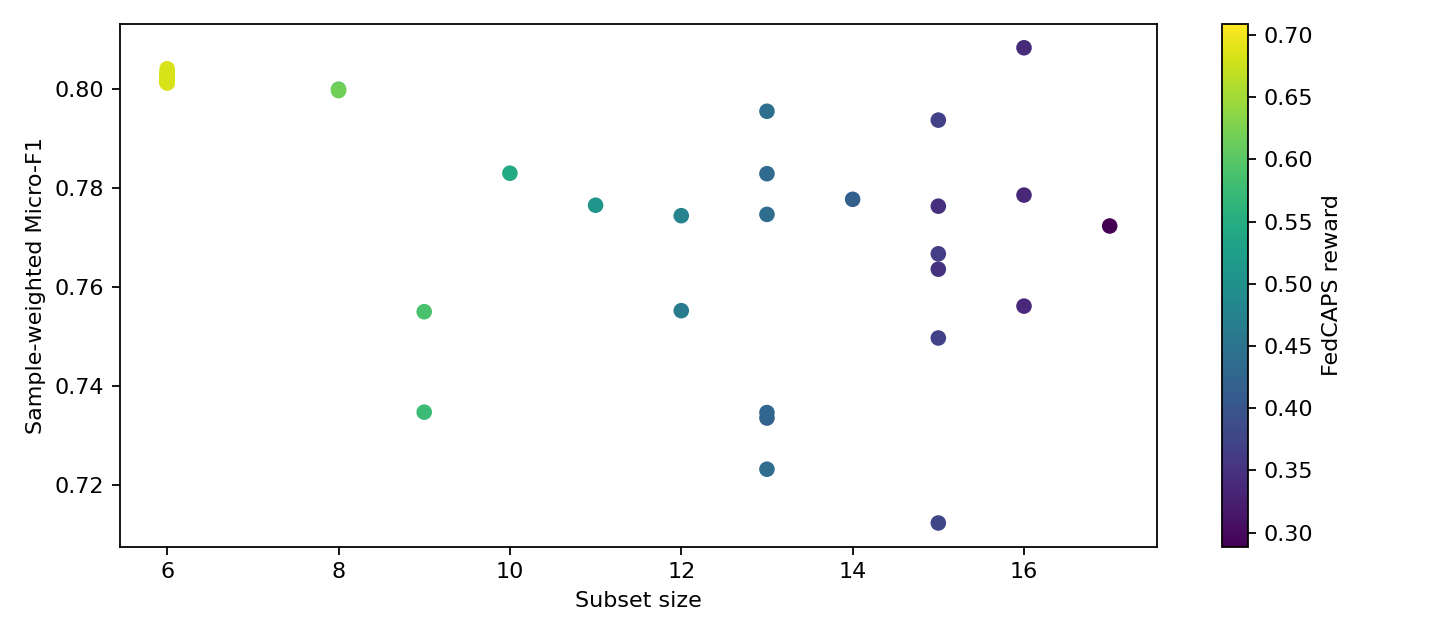

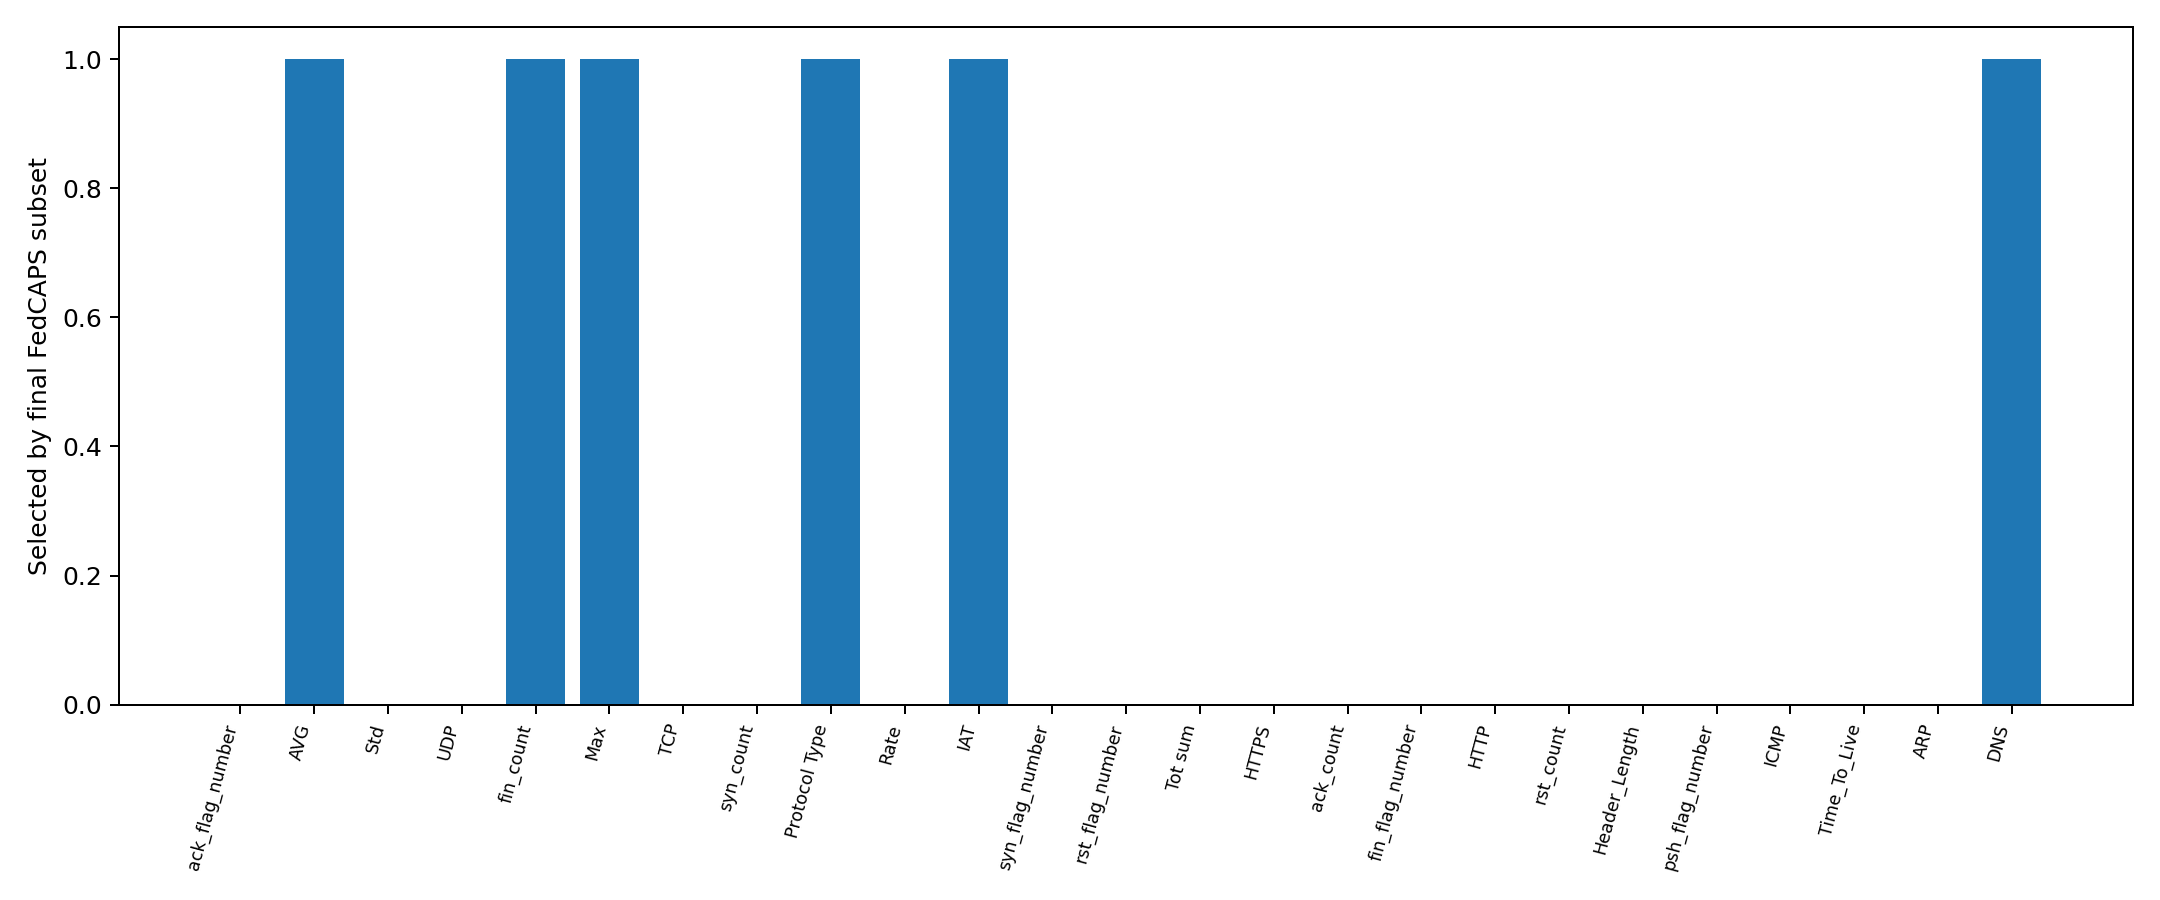

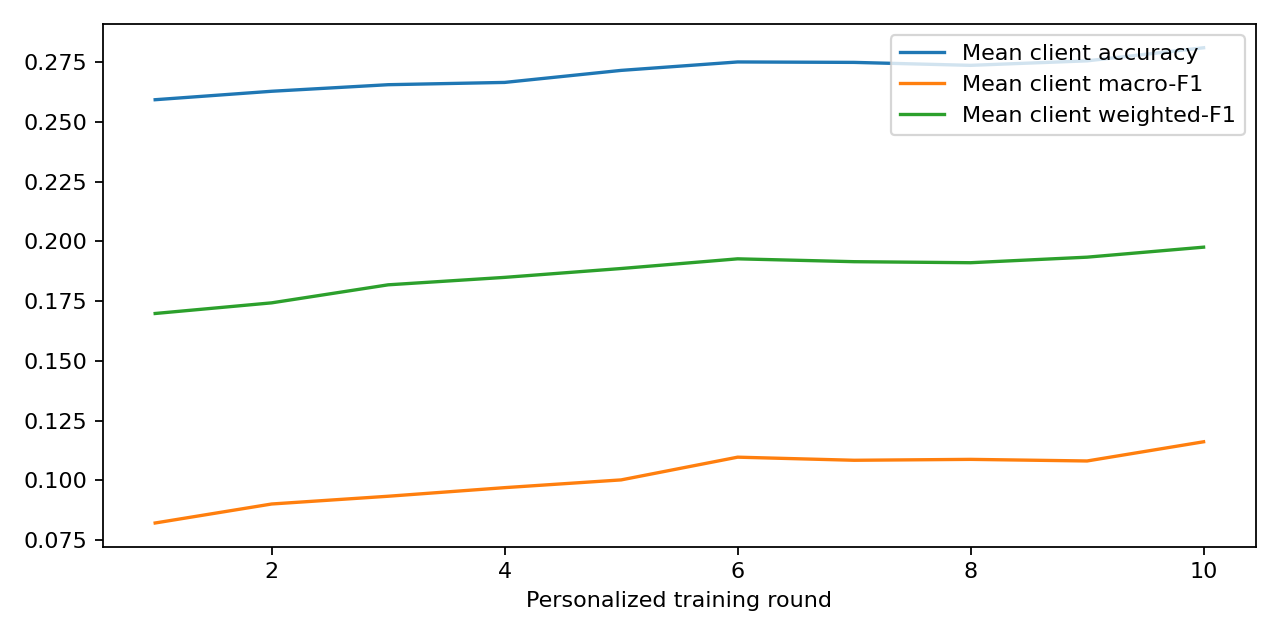

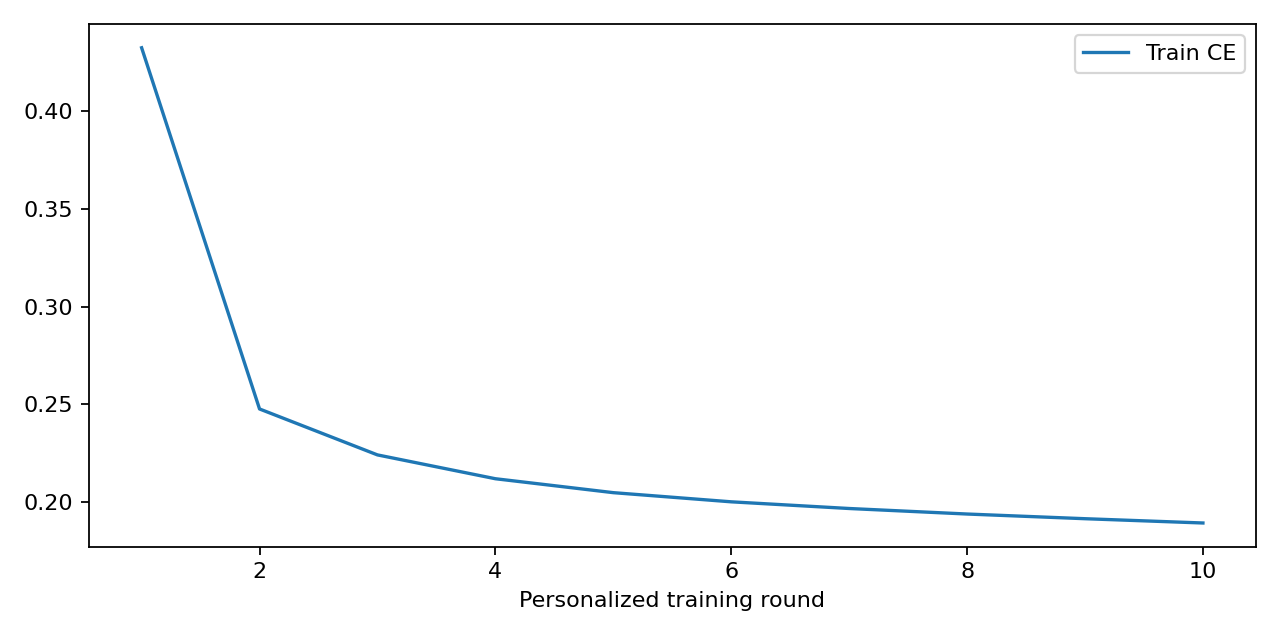

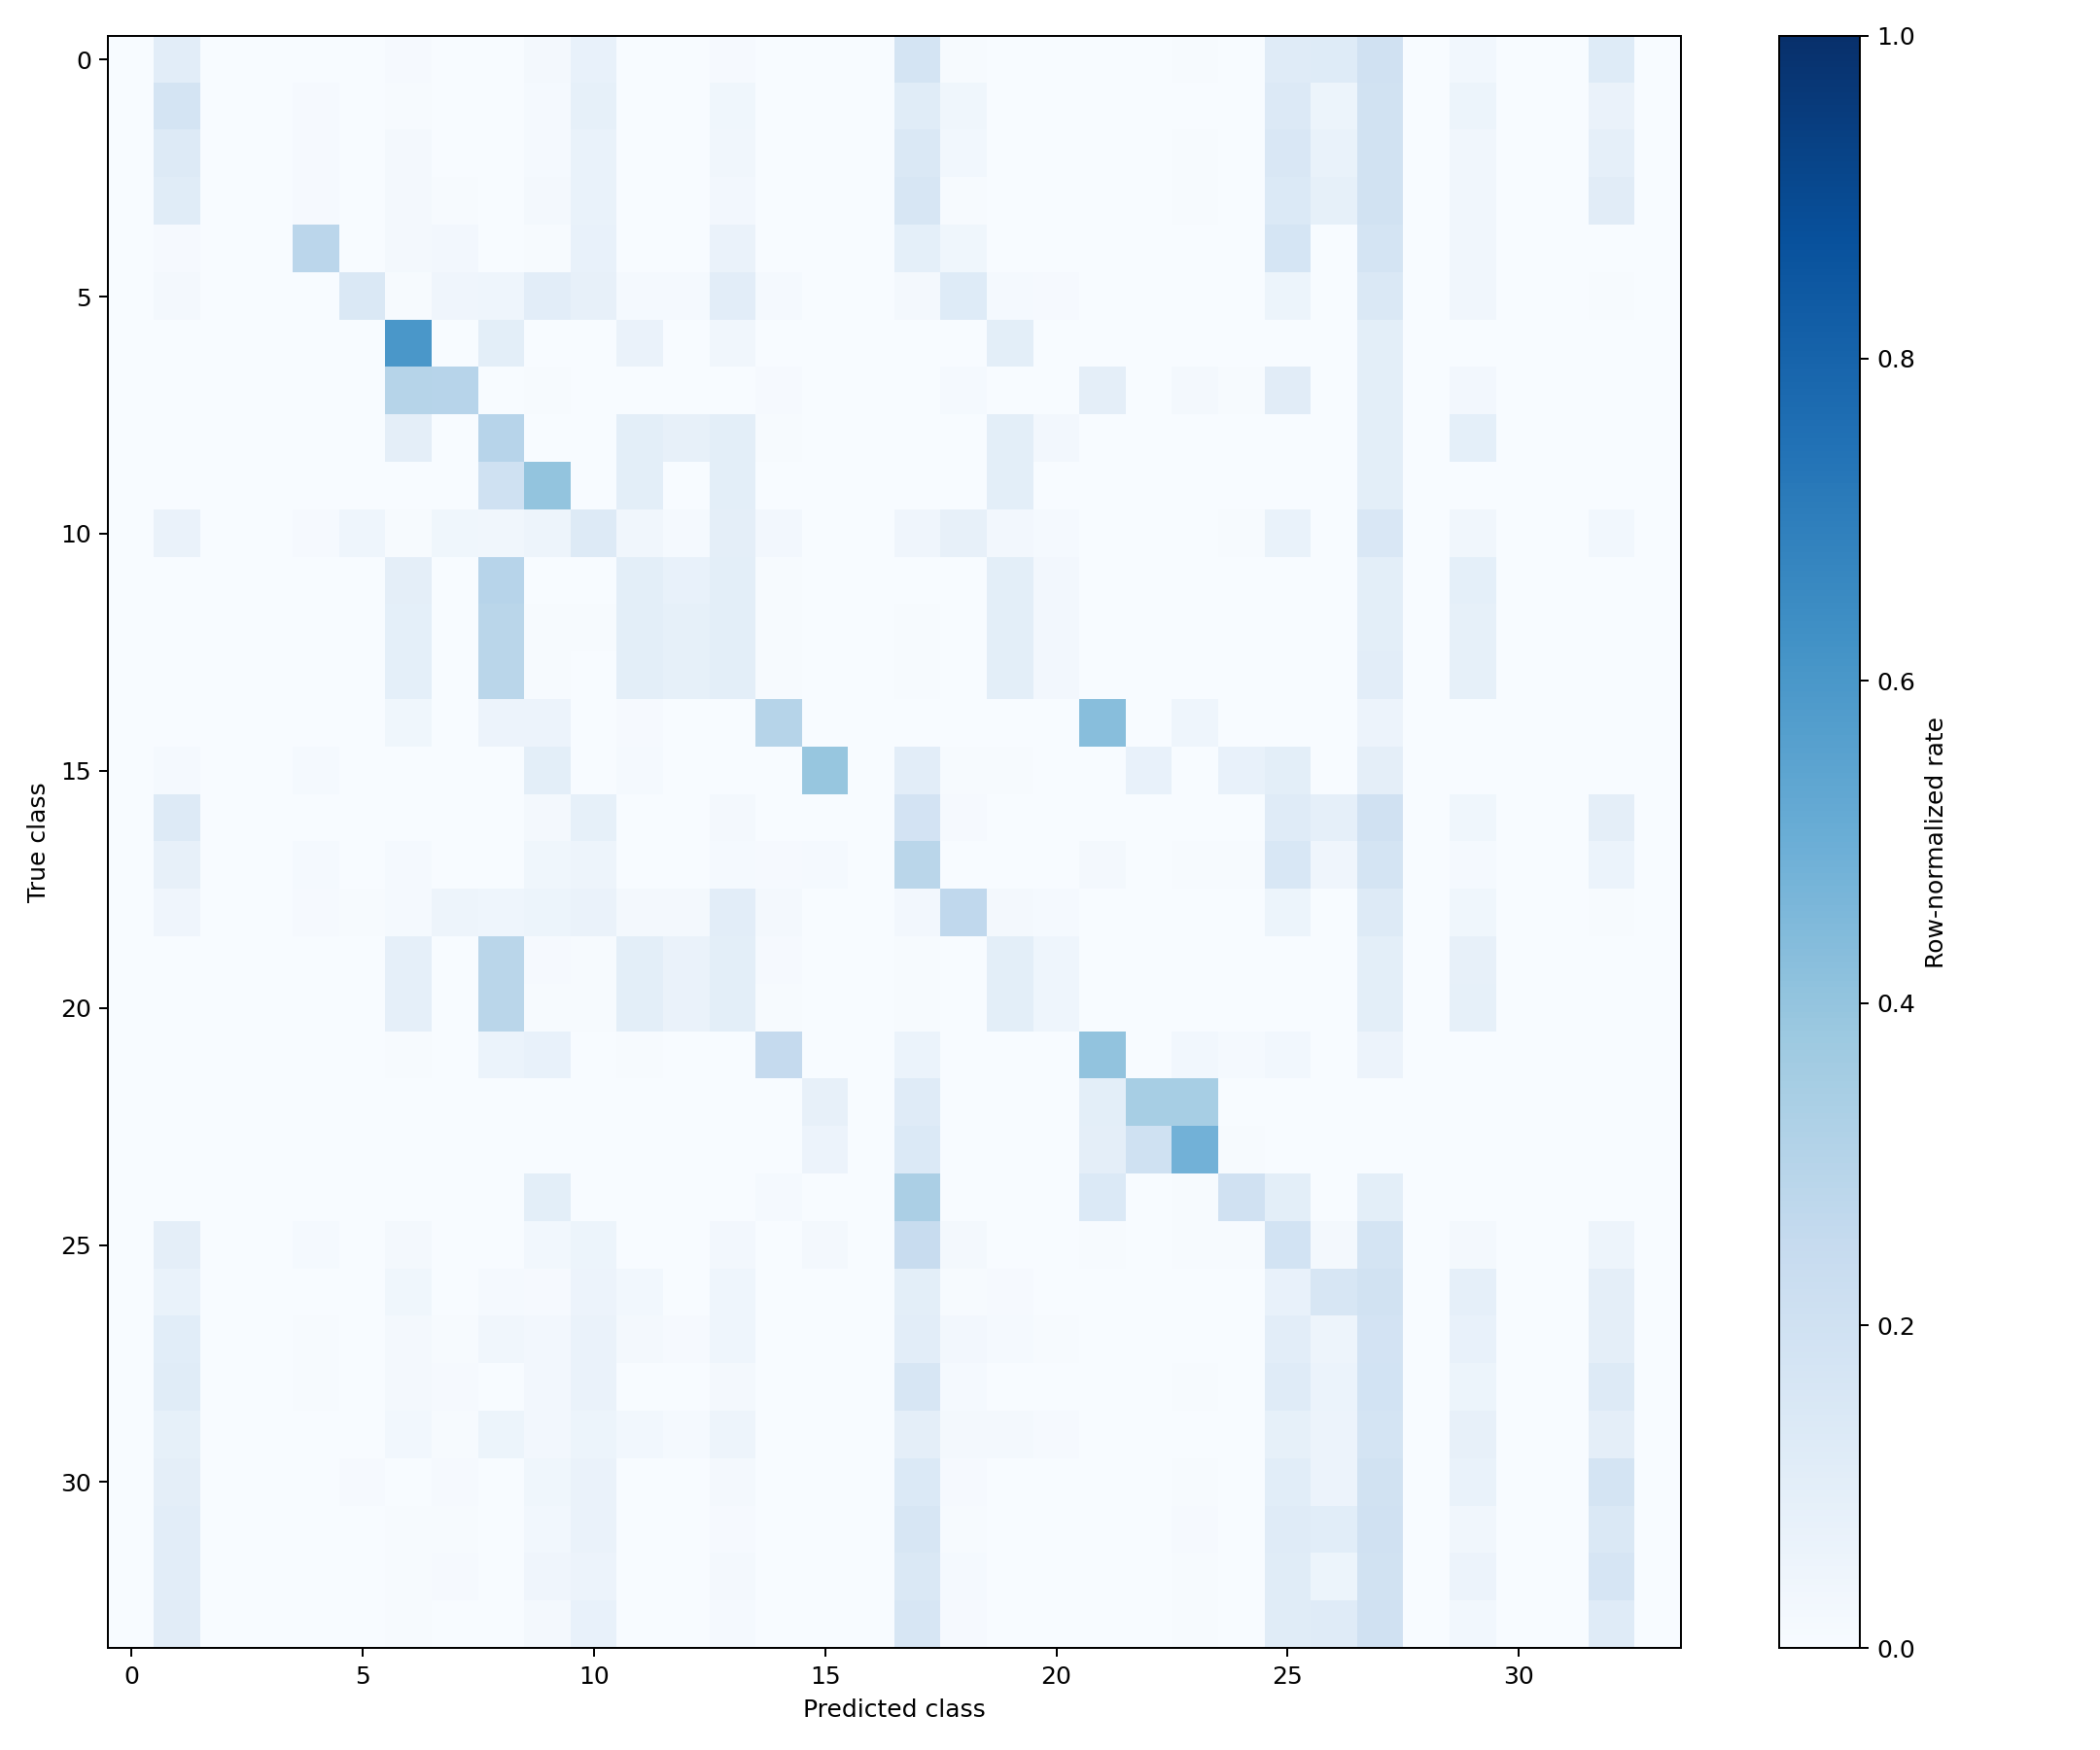

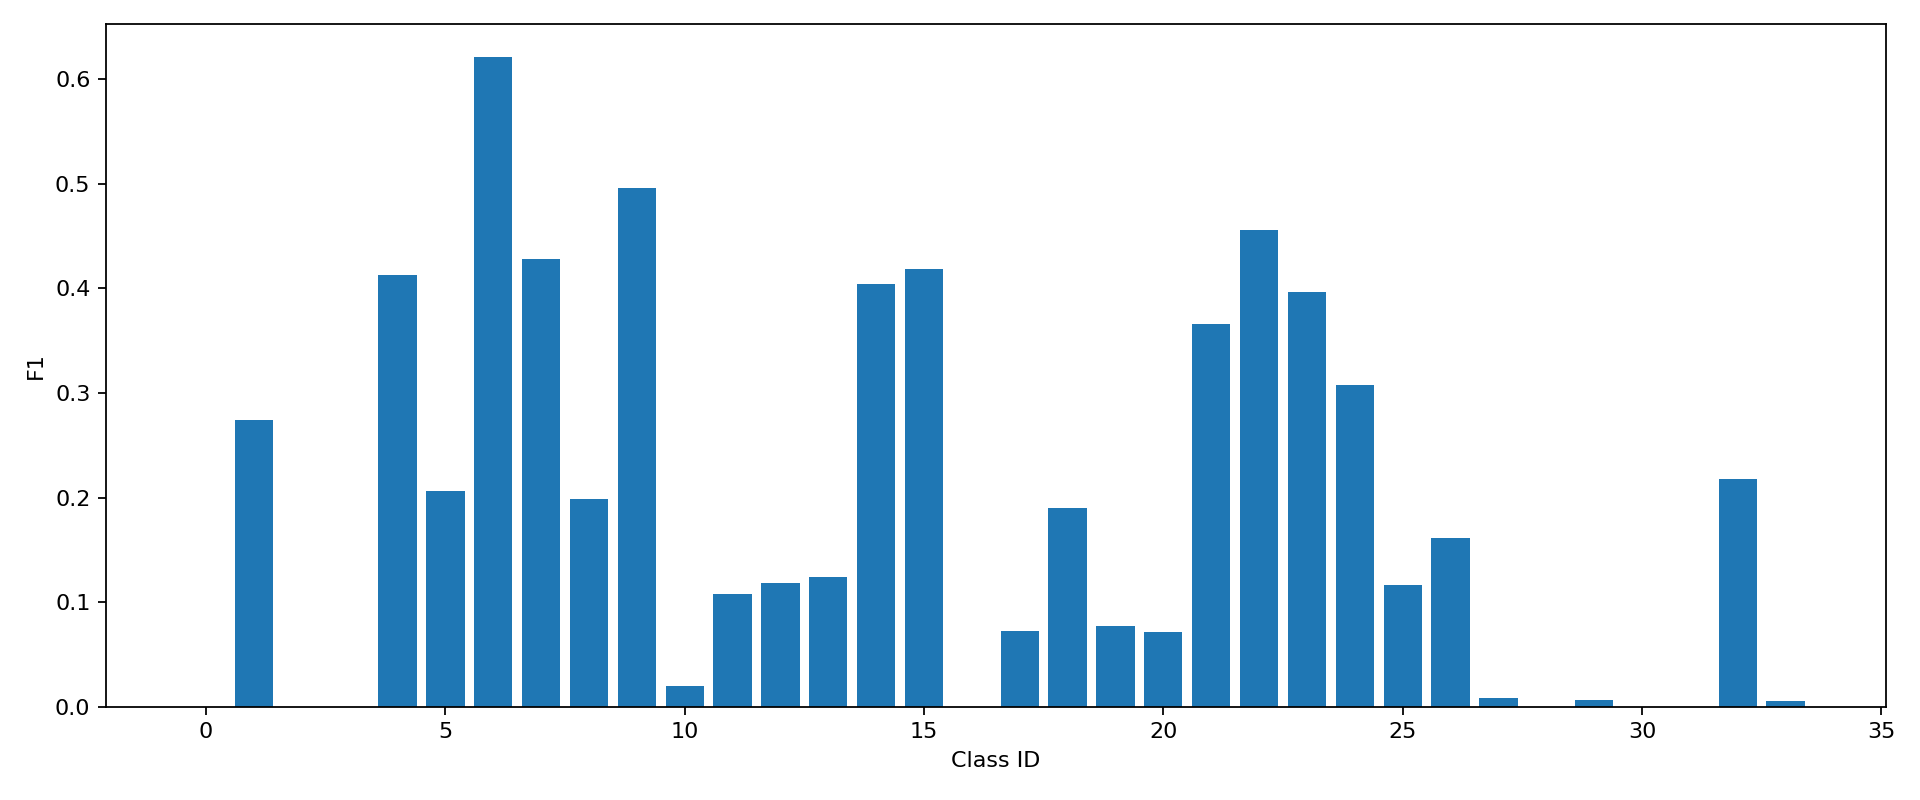

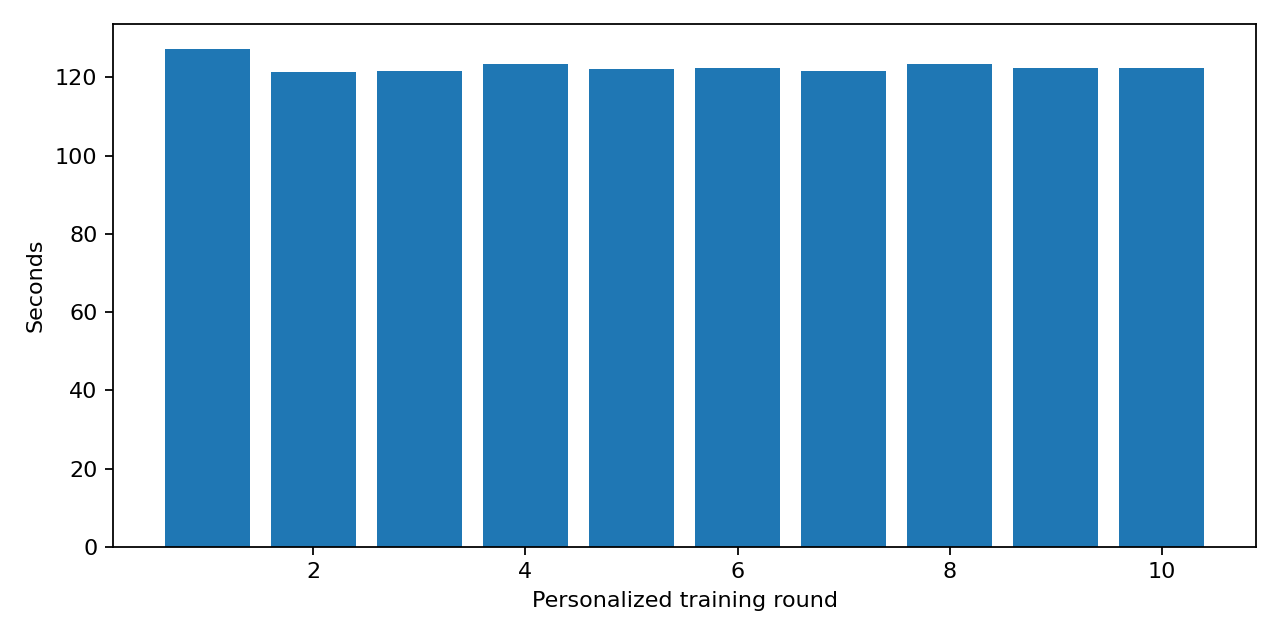

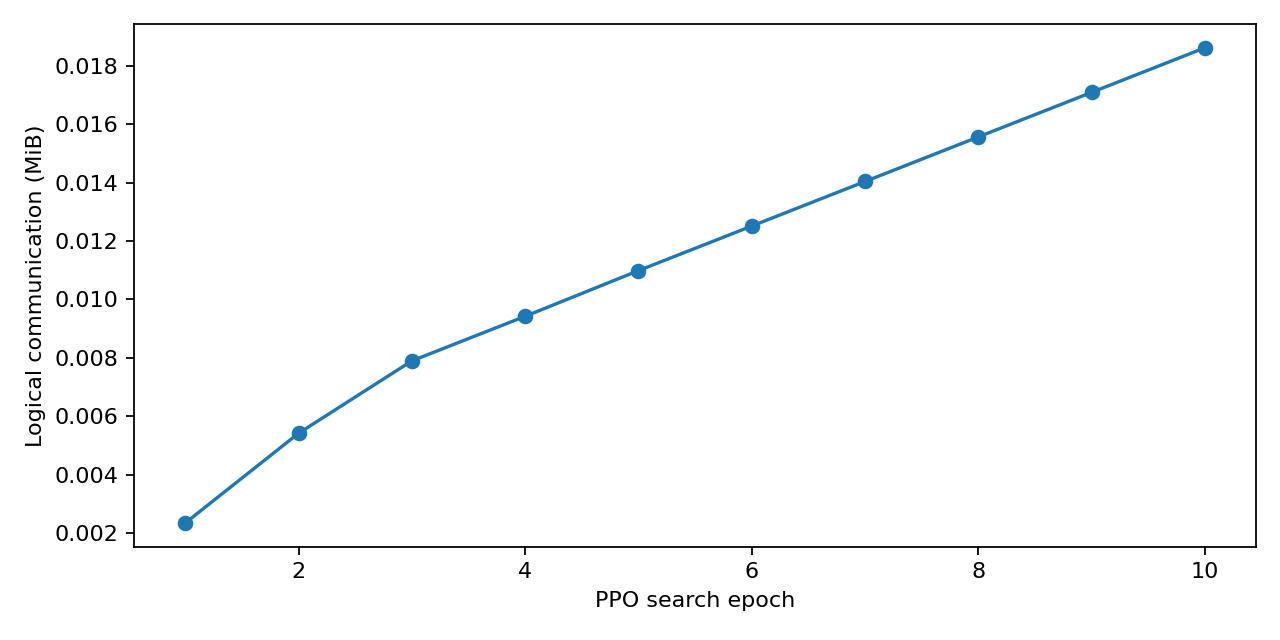

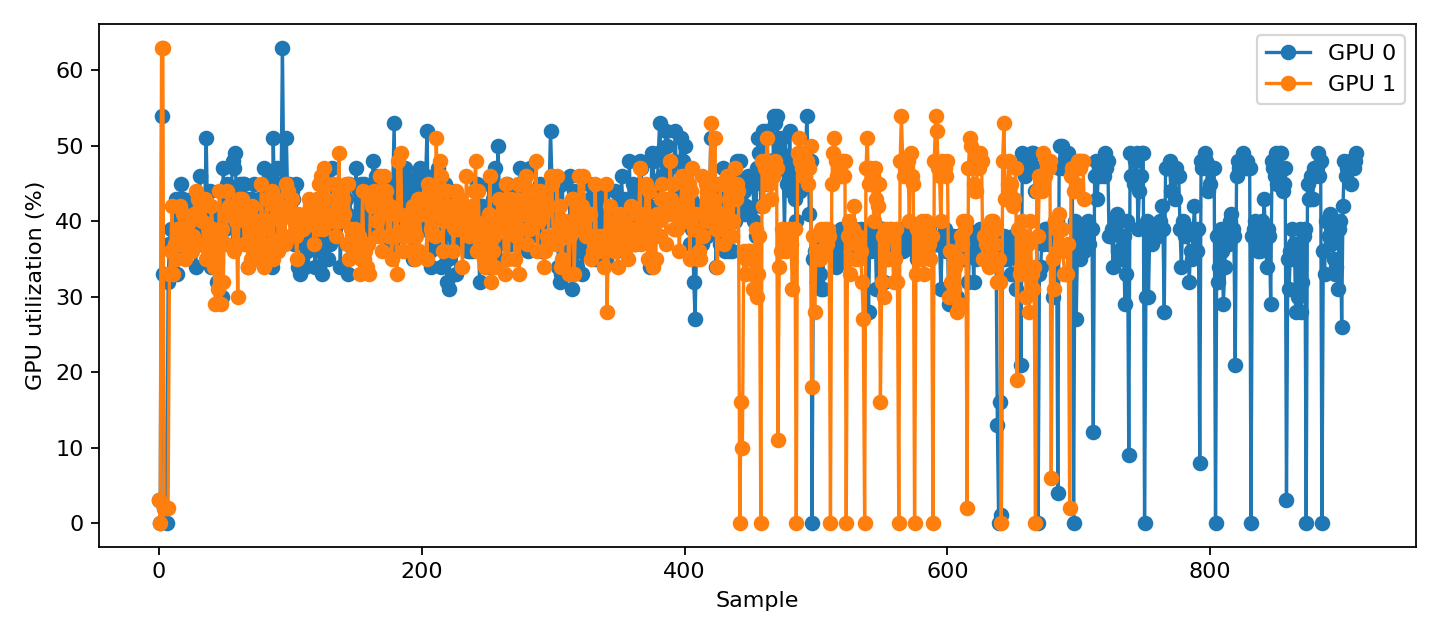

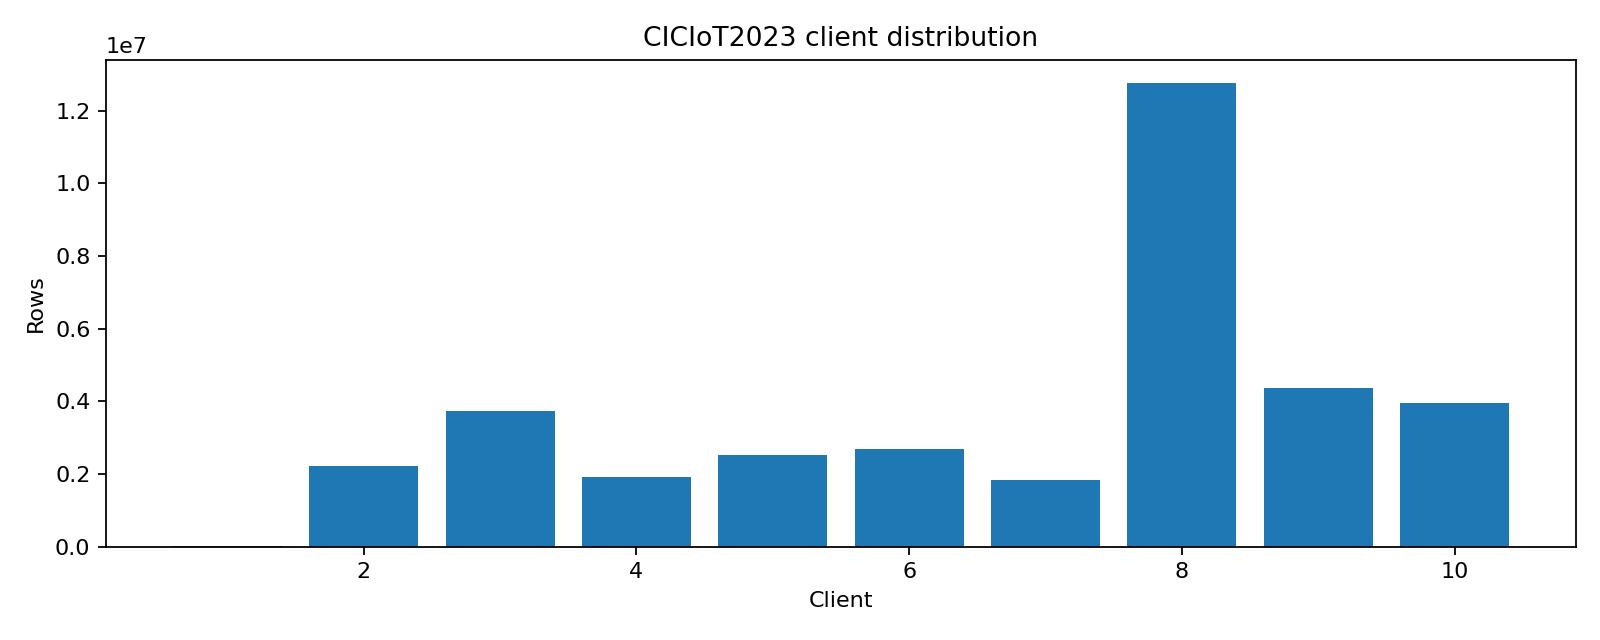

In [6]:
from IPython.display import Image, display
import importlib.util
import pandas as pd

runtime_spec = importlib.util.spec_from_file_location("fedcaps_runtime_verifier", CLIENT_PARALLEL_SCRIPT_PATH)
runtime_module = importlib.util.module_from_spec(runtime_spec)
runtime_spec.loader.exec_module(runtime_module)

RUN_DIR = Path(CONFIG["output_dir"])
CONFUSION_MATRIX_DIR = RUN_DIR / "metrics/confusion_matrices"
required = [
    "checkpoints/checkpoint_manifest.json", "logs/run.log", "logs/worker_0.log", "logs/worker_1.log",
    "metrics/config.json", "metrics/dataset_summary.json", "metrics/client_class_distribution.csv",
    "metrics/history_pretrain.csv", "metrics/history_pretrain.json",
    "metrics/feature_selection_records.csv", "metrics/encoder_history.csv", "metrics/ppo_history.csv",
    "metrics/candidate_evaluations.csv", "metrics/selected_features.json", "metrics/history_round.csv",
    "metrics/history_client.csv", "metrics/history_local_epoch.csv", "metrics/evaluation_metrics.csv",
    "metrics/evaluation_metrics.json", "metrics/final_round_metrics.csv", "metrics/final_round_metrics.json",
    "metrics/server_evaluation_status.json", "metrics/summary.json",
    "metrics/classification_report.json", "metrics/classification_report.csv",
    "metrics/confusion_matrix.csv", "metrics/confusion_matrix.npy",
    "metrics/personalized_test_metrics.json", "metrics/communication_costs.json",
    "metrics/runtime_breakdown.json", "artifacts/class_distribution.png",
    "artifacts/evaluation_metric_curves.png", "artifacts/loss_curves.png",
    "artifacts/confusion_matrix.png", "artifacts/per_class_f1.png",
    "artifacts/runtime_per_round.png", "artifacts/communication_cumulative.png",
    "artifacts/gpu_utilization.png",
    "artifacts/subset_size_search.png", "artifacts/selected_feature_importance.png",
]
missing = [relative for relative in required if not (RUN_DIR / relative).is_file() or (RUN_DIR / relative).stat().st_size == 0]
assert not missing, f"Missing/empty outputs: {missing}"
assert CONFUSION_MATRIX_DIR.is_dir()
assert len(pd.read_csv(RUN_DIR / "metrics/history_round.csv")) == 10
assert len(pd.read_csv(RUN_DIR / "metrics/history_client.csv")) == 100
assert len(pd.read_csv(RUN_DIR / "metrics/history_local_epoch.csv")) == 100
evaluation = pd.read_csv(RUN_DIR / "metrics/evaluation_metrics.csv")
assert len(evaluation) == 100
assert set(evaluation["round"]) == set(range(1, 11))
assert set(evaluation["model_scope"]) == {"client"}
assert all(name in evaluation.columns for name in CONFIG["common_metrics"])
runtime_module.verify_checkpoint_manifest(RUN_DIR, CONFIG, evaluation.to_dict("records"))
runtime_module.verify_evaluation_metrics(evaluation.to_dict("records"), CONFIG, int(evaluation["test_examples"].iloc[0]))
summary = json.loads((RUN_DIR / "metrics/summary.json").read_text(encoding="utf-8"))
assert summary["status"] == "complete"
print(json.dumps({
    "selected_features": summary["selected_features"],
    "weighted_test_metrics": summary["final_weighted_mean_personalized_test_metrics"],
    "runtime": summary["runtime"],
}, indent=2, ensure_ascii=False))
for artifact in [
    "subset_size_search.png", "selected_feature_importance.png", "evaluation_metric_curves.png",
    "loss_curves.png", "confusion_matrix.png", "per_class_f1.png",
    "runtime_per_round.png", "communication_cumulative.png", "gpu_utilization.png", "class_distribution.png",
]:
    display(Image(filename=str(RUN_DIR / "artifacts" / artifact)))
